In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import proplot as pplt
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyarrow.feather as feather
from scipy.stats import gaussian_kde


import pandas as pd
import geopandas as gpd
# attrs.set_index('gauge_id', inplace=True)

import io
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
# import proplot as pplt
import matplotlib as mpl
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import xarray as xr

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

from pandas import read_feather


In [13]:
# ============================================================
# Load libraries
# ============================================================
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import tempfile
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# 1. Load performance metrics
# ============================================================
perform = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL\metrics_BASE.csv"
)

perform["gauge_id"] = perform["gauge_id"].astype(int).astype(str).str.zfill(8)

# ============================================================
# 2. Load CAMELS basin geometries
# ============================================================
url = (
    "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/"
    "data/contents/camels_attributes_v2.0.feather"
)

tmp = tempfile.NamedTemporaryFile(suffix=".feather", delete=False)
tmp.write(requests.get(url).content)
tmp.close()

basins = gpd.read_feather(tmp.name)
# basins["gauge_id"] = basins["gauge_id"].astype(int).astype(str).str.zfill(8)
basins = basins.rename(columns={"gauge_id": "gauge_id"})


# ============================================================
# 3. Load CONUS states
# ============================================================
states = gpd.read_file(
    r"F:\Data\Mopex_Boundaries\States_shapefile/States_shapefile.shp"
)

states = states[~states["State_Name"].isin(["ALASKA", "HAWAII"])]

# ============================================================
# 4. Join KGE data (NO deltas)
# ============================================================
KGE_df = (
    perform[["gauge_id", "scenario", "KGE"]]
    .pivot(index="gauge_id", columns="scenario", values="KGE")
    .reset_index()
)

data_sf = basins.merge(KGE_df, on="gauge_id", how="inner")
data_sf = data_sf.set_crs(epsg=4326)

# ============================================================
# 5. Project to EPSG:5070
# ============================================================
basins_p = data_sf.to_crs(epsg=5070)
states_p = states.to_crs(epsg=5070)

# ============================================================
# 6. KGE color scale (exact equivalent)
# ============================================================
colors = [
    "#7f0000",
    "#b2182b",
    "#d73027",
    "#ef8a62",
    "#fdae61",
    "#fee090",
    "#f7f7f7",
    "#e0f3f8",
    "#abd9e9",
    "#74add1",
    "blue",
    "darkblue",
]

values = np.array([-2, -1, -0.3, 0, 0.3, 0.7, 1])
norm = Normalize(vmin=-2, vmax=1)

cmap = LinearSegmentedColormap.from_list(
    "KGE_scale",
    list(zip((values - values.min()) / (values.max() - values.min()), colors))
)

# ============================================================
# 7. Function to make ONE KGE map
# ============================================================
def make_kge_map(var, title_txt, outname):
    fig, ax = plt.subplots(figsize=(4, 4), dpi=200)

    states_p.boundary.plot(ax=ax, linewidth=0.1, color="black")

    basins_p.plot(
        column=var,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0,
        alpha=0.95
    )

    ax.set_title(title_txt, fontsize=13, fontweight="bold", loc="left")
    ax.set_axis_off()

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("KGE [-]")

    plt.savefig(outname, bbox_inches="tight")
    plt.show()

# ============================================================
# 8. Generate separate KGE maps
# ============================================================
# make_kge_map("Q_ke",    "(a) KGE : Q_ke",    "KGE_Q_ke.png")
# make_kge_map("Q_b",     "(b) KGE : Q_b",     "KGE_Q_b.png")
# make_kge_map("Q_B_ass", "(c) KGE : Q_B_ass", "KGE_Q_B_ass.png")
# make_kge_map("Q_nldas", "(d) KGE : Q_nldas", "KGE_Q_nldas.png")

# Optional (only if present)
if "Q_NWM" in basins_p.columns:
    make_kge_map("Q_NWM", "(e) KGE : Q_NWM", "KGE_Q_NWM.png")
plt.show()

# All fluxes: Longterm: Simulation_with_BASIN_CALIB_PARAMS

In [ ]:


# # ============================================================
# # PATHS
# # ============================================================

# RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BASE_MODEL"
# RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_MODEL"
# RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_DA"

# # ============================================================
# # HELPERS
# # ============================================================

# def get_gauge_id(fname: str) -> str:
#     return fname.replace(".feather", "").split("_")[-1]

# def read_results_folder_monthly(result_dir: str, keep_cols: list, label: str) -> pd.DataFrame:
#     files = [
#         f for f in os.listdir(result_dir)
#         if f.startswith("results_") and f.endswith(".feather")
#     ]

#     dfs = []

#     for fname in tqdm(files, desc=f"Reading monthly {label}"):
#         basin_id = get_gauge_id(fname)
#         fpath = os.path.join(result_dir, fname)

#         try:
#             df = feather.read_feather(fpath)
#             df["time"] = pd.to_datetime(df["time"])
#             df["gauge_id"] = basin_id

#             cols = ["time", "gauge_id"] + [c for c in keep_cols if c in df.columns]
#             dfs.append(df[cols])

#         except Exception as e:
#             print(f"⚠️ Skipping {basin_id}: {e}")

#     return pd.concat(dfs, ignore_index=True)

# # ============================================================
# # LOAD MONTHLY MODEL OUTPUTS
# # ============================================================

# base_cols   = ["P", "PET", "ET_ke", "dS_base"]
# budyko_cols = ["ET_B", "omega_true", "omega_MLR", "dS_budyko"]
# da_cols     = ["ET_ass", "dS_ass"]

# base_m   = read_results_folder_monthly(RESULT_DIR_BASE,   base_cols,   "BASE")
# budyko_m = read_results_folder_monthly(RESULT_DIR_BUDYKO, budyko_cols, "BUDYKO")
# da_m     = read_results_folder_monthly(RESULT_DIR_DA,     da_cols,     "DA")

# # ============================================================
# # MERGE MONTHLY DATA (STILL MONTHLY!)
# # ============================================================

# monthly_state_aware = (
#     base_m
#     .merge(budyko_m, on=["gauge_id", "time"], how="left")
#     .merge(da_m,     on=["gauge_id", "time"], how="left")
# )

# # ============================================================
# # STATE-AWARE INDICES (MONTHLY, PHYSICALLY CONSISTENT)
# # ============================================================

# eps = 1e-6

# monthly_state_aware["P_eff_base"] = monthly_state_aware["P"] - monthly_state_aware["dS_base"]
# monthly_state_aware["P_eff_B"]    = monthly_state_aware["P"] - monthly_state_aware["dS_budyko"]
# monthly_state_aware["P_eff_ass"]  = monthly_state_aware["P"] - monthly_state_aware["dS_ass"]

# # monthly_state_aware["EI_base"] = (
# #     monthly_state_aware["ET_ke"] / (monthly_state_aware["P_eff_base"] + eps)
# # )

# # monthly_state_aware["EI_B"] = (
# #     monthly_state_aware["ET_B"] / (monthly_state_aware["P_eff_B"] + eps)
# # )

# # monthly_state_aware["EI_ass"] = (
# #     monthly_state_aware["ET_ass"] / (monthly_state_aware["P_eff_ass"] + eps)
# # )

# # monthly_state_aware["AI"] = (
# #     monthly_state_aware["PET"] / (monthly_state_aware["P"] + eps)
# # )

# # ============================================================
# # LOAD CAMELS ATTRIBUTES (STATIC, MERGED MONTHLY)
# # ============================================================

# r = requests.get(
#     "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/"
#     "data/contents/camels_attributes_v2.0.feather"
# )
# attrs = gpd.read_feather(io.BytesIO(r.content)).reset_index(drop=False)

# attrs["gauge_id"] = attrs["gauge_id"].astype(str).str.zfill(8)
# monthly_state_aware["gauge_id"] = monthly_state_aware["gauge_id"].astype(str).str.zfill(8)

# monthly_state_aware = monthly_state_aware.merge(
#     attrs, on="gauge_id", how="left"
# )

# # ============================================================
# # LAND COVER MAPPING
# # ============================================================

# land_cover_mapping = {
#     "Croplands": "CL/NVM",
#     "cropland/natural vegetation mosaic": "CL/NVM",
#     "Deciduous Broadleaf Forest": "DBF",
#     "Evergreen Needleleaf Forest": "EF",
#     "Evergreen Broadleaf Forest": "EF",
#     "Mixed Forests": "MF",
#     "Grasslands": "GL",
#     "Savannas": "WS + SL",
#     "Woody Savannas": "WS + SL",
#     "Closed Shrublands": "WS + SL",
#     "Open Shrublands": "WS + SL"
# }

# monthly_state_aware["dom_land_cover_short"] = (
#     monthly_state_aware["dom_land_cover"].map(land_cover_mapping)
# )
# attrs_all_simu_mean_505_basins_monthly = monthly_state_aware
# attrs_all_simu_mean_505_basins_monthly



# cols = ['q_mean', 'runoff_ratio', 'slope_fdc',
#        'baseflow_index', 'stream_elas', 'q5', 'q95', 'high_q_freq',
#        'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean',
#        'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity',
#        'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac',
#        'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'p_mean',
#        'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq',
#        'high_prec_dur', 'high_prec_timing', 'low_prec_freq', 'low_prec_dur',
#        'low_prec_timing', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max',
#        'gvf_diff', 'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50',
#        'root_depth_99', 'gauge_lat', 'gauge_lon', 'elev_mean', 'slope_mean',
#        'area_gages2', 'area_geospa_fabric', 'geol_1st_class',
#        'glim_1st_class_frac', 'geol_2nd_class', 'glim_2nd_class_frac',
#        'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'gauge_name', 'huc_02']

# attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.drop(columns=cols, axis=1)


# SFET = pd.read_feather(
#     r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"
# )

# SFET["time"] = pd.to_datetime(SFET["time"])
# SFET = SFET.set_index("time").sort_index()
# SFET.columns = SFET.columns.astype(str).str.strip()
# SFET = SFET.loc[:, ~SFET.columns.duplicated()]
# SFET_monthly = SFET.resample("MS").sum()
# SFET_monthly.index.name = "time"


# SFET = (SFET_monthly.reset_index().melt(
#         id_vars="time",
#         var_name="gauge_id",
#         value_name="SFET"
#     )
# ).drop('time',axis=1)


# attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.merge(SFET, on='gauge_id')

# # calculate Budyko indices:
# attrs_all_simu_mean_505_basins_monthly["EI_base"] = attrs_all_simu_mean_505_basins_monthly["ET_ke"]  / (attrs_all_simu_mean_505_basins_monthly["P_eff_base"] + 1e-6)
# attrs_all_simu_mean_505_basins_monthly["EI_B"]    = attrs_all_simu_mean_505_basins_monthly["ET_B"]   / (attrs_all_simu_mean_505_basins_monthly["P_eff_B"]    + 1e-6)
# attrs_all_simu_mean_505_basins_monthly["EI_ass"]  = attrs_all_simu_mean_505_basins_monthly["ET_ass"] / (attrs_all_simu_mean_505_basins_monthly["P_eff_ass"]  + 1e-6)
# attrs_all_simu_mean_505_basins_monthly["AI_base"] = attrs_all_simu_mean_505_basins_monthly["PET"] / (attrs_all_simu_mean_505_basins_monthly["P_eff_base"] + 1e-6)
# attrs_all_simu_mean_505_basins_monthly["AI_B"]    = attrs_all_simu_mean_505_basins_monthly["PET"] / (attrs_all_simu_mean_505_basins_monthly["P_eff_B"]    + 1e-6)
# attrs_all_simu_mean_505_basins_monthly["AI_ass"]  = attrs_all_simu_mean_505_basins_monthly["PET"] / (attrs_all_simu_mean_505_basins_monthly["P_eff_ass"]  + 1e-6)

# attrs_all_simu_mean_505_basins_monthly

import os
import io
import numpy as np
import pandas as pd
import geopandas as gpd
import pyarrow.feather as feather
import requests
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA"

SFET_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"

eps = 1e-6

# ============================================================
# HELPERS
# ============================================================
def get_gauge_id(fname: str) -> str:
    return fname.replace(".feather", "").split("_")[-1].strip()

def read_results_folder_monthly(result_dir: str, keep_cols: list, label: str) -> pd.DataFrame:
    files = [f for f in os.listdir(result_dir) if f.startswith("results_") and f.endswith(".feather")]
    dfs = []

    for fname in tqdm(files, desc=f"Reading monthly {label}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        try:
            df = feather.read_feather(fpath)
            if "time" not in df.columns:
                continue

            df["time"] = pd.to_datetime(df["time"])
            df["gauge_id"] = str(basin_id).zfill(8)

            cols = ["time", "gauge_id"] + [c for c in keep_cols if c in df.columns]
            out = df[cols].copy()

            # force numeric for flux/state columns
            for c in cols:
                if c not in ["time", "gauge_id"]:
                    out[c] = pd.to_numeric(out[c], errors="coerce")

            dfs.append(out)

        except Exception as e:
            print(f"⚠️ Skipping {basin_id} in {label}: {e}")

    if len(dfs) == 0:
        return pd.DataFrame(columns=["time", "gauge_id"] + keep_cols)

    return pd.concat(dfs, ignore_index=True)

# ============================================================
# LOAD MONTHLY MODEL OUTPUTS (MONTHLY!)
# ============================================================
base_cols   = ["P", "PET", "ET_ke", "dS_base"]
budyko_cols = ["ET_B", "omega_true", "omega_MLR", "dS_budyko"]
da_cols     = ["ET_ass", "dS_ass"]

base_m   = read_results_folder_monthly(RESULT_DIR_BASE,   base_cols,   "BASE")
budyko_m = read_results_folder_monthly(RESULT_DIR_BUDYKO, budyko_cols, "BUDYKO")
da_m     = read_results_folder_monthly(RESULT_DIR_DA,     da_cols,     "DA")

# ============================================================
# MERGE MONTHLY DATA (STILL MONTHLY)
# ============================================================
attrs_all_simu_mean_505_basins_monthly = (
    base_m
    .merge(budyko_m, on=["gauge_id", "time"], how="left")
    .merge(da_m,     on=["gauge_id", "time"], how="left")
)

# ============================================================
# STATE-AWARE P_eff (MONTHLY, for later aggregation)
# ============================================================
attrs_all_simu_mean_505_basins_monthly["P_eff_base"] = attrs_all_simu_mean_505_basins_monthly["P"] - attrs_all_simu_mean_505_basins_monthly["dS_base"]
attrs_all_simu_mean_505_basins_monthly["P_eff_B"]    = attrs_all_simu_mean_505_basins_monthly["P"] - attrs_all_simu_mean_505_basins_monthly["dS_budyko"]
attrs_all_simu_mean_505_basins_monthly["P_eff_ass"]  = attrs_all_simu_mean_505_basins_monthly["P"] - attrs_all_simu_mean_505_basins_monthly["dS_ass"]

# ============================================================
# LOAD CAMELS ATTRIBUTES (STATIC) AND MERGE TO MONTHLY
# ============================================================
r = requests.get(
    "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/"
    "data/contents/camels_attributes_v2.0.feather"
)
attrs = gpd.read_feather(io.BytesIO(r.content)).reset_index(drop=False)
attrs["gauge_id"] = attrs["gauge_id"].astype(str).str.zfill(8)

attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.merge(attrs, on="gauge_id", how="left")

# ============================================================
# LAND COVER MAPPING
# ============================================================
land_cover_mapping = {
    "Croplands": "CL/NVM",
    "cropland/natural vegetation mosaic": "CL/NVM",
    "Deciduous Broadleaf Forest": "DBF",
    "Evergreen Needleleaf Forest": "EF",
    "Evergreen Broadleaf Forest": "EF",
    "Mixed Forests": "MF",
    "Grasslands": "GL",
    "Savannas": "WS + SL",
    "Woody Savannas": "WS + SL",
    "Closed Shrublands": "WS + SL",
    "Open Shrublands": "WS + SL",
}
attrs_all_simu_mean_505_basins_monthly["dom_land_cover_short"] = attrs_all_simu_mean_505_basins_monthly["dom_land_cover"].map(land_cover_mapping)

# ============================================================
# LOAD SFET (MONTHLY) AND MERGE ON (gauge_id, time)
# IMPORTANT: do NOT drop time; merge must be time-aware
# ============================================================
SFET = pd.read_feather(SFET_PATH)
SFET["time"] = pd.to_datetime(SFET["time"])
SFET = SFET.set_index("time").sort_index()
SFET.columns = SFET.columns.astype(str).str.strip()
SFET = SFET.loc[:, ~SFET.columns.duplicated()]

SFET_monthly = SFET.resample("MS").sum()
SFET_long = (
    SFET_monthly.reset_index()
    .melt(id_vars="time", var_name="gauge_id", value_name="SFET")
)
SFET_long["gauge_id"] = SFET_long["gauge_id"].astype(str).str.zfill(8)

attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.merge(SFET_long, on=["gauge_id", "time"], how="left").dropna(axis=0)

# ============================================================
# OPTIONAL: DROP HEAVY ATTR COLUMNS (SAFE)
# ============================================================
cols_to_drop = [
    'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95',
    'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean',
    'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity',
    'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac',
    'other_frac', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity',
    'high_prec_freq', 'high_prec_dur', 'high_prec_timing', 'low_prec_freq', 'low_prec_dur',
    'low_prec_timing', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff',
    'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50', 'root_depth_99', 'gauge_lat',
    'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric',
    'geol_1st_class', 'glim_1st_class_frac', 'geol_2nd_class', 'glim_2nd_class_frac',
    'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'gauge_name', 'huc_02'
]
attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.drop(columns=cols_to_drop, errors="ignore")


# long-term

df = attrs_all_simu_mean_505_basins_monthly
num_cols = df.select_dtypes(include=[np.number]).columns

attrs_all_simu_mean_505_basins_longterm = (
    df.groupby("gauge_id", as_index=False)[num_cols].mean()
    .merge(
        df[["gauge_id", "geometry", "dom_land_cover_short"]].drop_duplicates("gauge_id"),
        on="gauge_id",
        how="left",
    )
)
attrs_all_simu_mean_505_basins_longterm = attrs_all_simu_mean_505_basins_longterm.drop(
    columns=["SFET"], errors="ignore"
)

# keep only columns that are NOT already in the main dataframe
cols_to_keep = [
    c for c in attrs_all_simu_mean_505_basins_longterm.columns
    if c not in attrs_all_simu_mean_505_basins.columns or c == "gauge_id"
]

attrs_all_simu_mean_505_basins_longterm = attrs_all_simu_mean_505_basins.merge(
    attrs_all_simu_mean_505_basins_longterm[cols_to_keep],
    on="gauge_id",
    how="inner"
)
attrs_all_simu_mean_505_basins_longterm

Reading monthly DA: 100%|██████████| 505/505 [00:00<00:00, 577.50it/s]


,gauge_id,P,PET,ET_ke,S_base,G_base,Q_base,ET_B,omega_true,omega_MLR,...,EI_B,AI_ass,EI_ass,SFET,dS_base,dS_budyko,dS_ass,P_eff_base,P_eff_B,P_eff_ass
0,01022500,86.182610,135.771404,80.956347,0.524862,5.255338,80.842261,65.284661,3.398011,3.329672,...,0.757515,1.575392,0.066290,45.406795,-0.052621,-4.506953e-02,-5.262086e-02,86.656575,86.649023,86.656575
1,01052500,81.366356,118.805594,36.255079,0.618347,7.051756,77.300507,62.736701,2.104366,2.843545,...,0.771040,1.460132,0.050172,36.776046,0.016628,1.186748e-02,1.662794e-02,82.454975,82.459735,82.454975
2,01054200,101.319878,109.854169,51.146497,13.946310,0.005953,83.564618,68.421600,2.385080,3.304634,...,0.675303,1.084231,0.186402,38.479338,-0.365444,-3.640354e-01,-3.654435e-01,102.492015,102.490607,102.492015
3,01121000,93.917641,153.431644,71.360086,4.070527,0.823474,69.539172,73.864979,3.181944,3.364830,...,0.786487,1.633683,0.250704,49.876907,-0.066355,-6.123261e-02,-6.635467e-02,94.567515,94.562393,94.567515
4,01139000,79.995300,119.256682,80.435400,1.698569,0.760667,71.953612,63.582376,3.597068,3.281023,...,0.794826,1.490796,0.100762,38.865490,-0.049551,-4.605250e-02,-4.955141e-02,81.059091,81.055592,81.059091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,14020000,73.641197,173.663288,74.099485,1.692280,7.659346,60.677392,43.097032,2.774546,2.624080,...,0.585230,2.358236,0.177397,38.166469,0.000000,1.995907e-17,2.619140e-20,73.190058,73.190058,73.190058
137,14096850,52.207867,189.604164,145.331127,53.935598,10.491120,6.525373,43.286541,3.898259,3.051246,...,0.829119,3.631716,0.738199,37.245835,-0.888804,-7.042395e-01,-4.145243e-01,52.332118,52.147554,51.857839
138,14166500,99.470299,155.406736,23.998371,18.748125,2.703087,85.418098,42.583552,2.167122,2.449581,...,0.428103,1.562343,0.121077,41.489394,0.000000,-2.494883e-18,0.000000e+00,97.572299,97.572299,97.572299
139,14236200,132.488937,133.693415,3.458411,9.767492,52.662106,129.876306,57.596147,1.602445,2.893111,...,0.434724,1.009091,0.024300,42.205215,0.066906,7.548141e-02,6.690559e-02,132.479918,132.471342,132.479918


In [ ]:
attrs_all_simu_mean_505_basins_longterm.columns

Index(['gauge_id', 'P', 'PET', 'ET_ke', 'S_base', 'G_base', 'Q_base', 'ET_B',
       'omega_true', 'omega_MLR', 'S_budyko', 'G_budyko', 'Q_obs', 'Q_budyko',
       'ET_ass', 'Q_ass', 'Q_ens', 'ET_ens_mean', 'Q_ens_mean', 'S_ens_mean',
       'G_ens_mean', 'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index',
       'stream_elas', 'p_mean', 'pet_mean', 'p_seasonality', 'aridity',
       'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff',
       'dom_land_cover_frac', 'dom_land_cover', 'elev_mean', 'slope_mean',
       'geometry', 'KGE_Base', 'NSE_Base', 'KGE_Budyko', 'NSE_Budyko',
       'KGE_DA', 'NSE_DA', 'dom_land_cover_short', 'AI_base', 'EI_base',
       'AI_B', 'EI_B', 'AI_ass', 'EI_ass', 'SFET', 'dS_base', 'dS_budyko',
       'dS_ass', 'P_eff_base', 'P_eff_B', 'P_eff_ass'],
      dtype='object')

# All Fluxes: Monthly : Simulation_with_BASIN_CALIB_PARAMS

In [ ]:
import os
import io
import numpy as np
import pandas as pd
import geopandas as gpd
import pyarrow.feather as feather
import requests
from tqdm import tqdm

# ============================================================
# PATHS
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA"

SFET_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"

# ============================================================
# HELPERS
# ============================================================
def get_gauge_id(fname: str) -> str:
    return fname.replace(".feather", "").split("_")[-1].strip()

def read_results_folder_monthly(result_dir: str, keep_cols: list, label: str) -> pd.DataFrame:
    files = [f for f in os.listdir(result_dir) if f.endswith(".feather")]
    dfs = []

    for fname in tqdm(files, desc=f"Reading monthly {label}"):
        basin_id = get_gauge_id(fname)
        fpath = os.path.join(result_dir, fname)

        df = feather.read_feather(fpath)
        if "time" not in df.columns:
            continue

        df["time"] = pd.to_datetime(df["time"])
        df["gauge_id"] = str(basin_id).zfill(8)

        cols = ["time", "gauge_id"] + [c for c in keep_cols if c in df.columns]
        out = df[cols].copy()

        for c in cols:
            if c not in ["time", "gauge_id"]:
                out[c] = pd.to_numeric(out[c], errors="coerce")

        dfs.append(out)

    if not dfs:
        return pd.DataFrame(columns=["time", "gauge_id"] + keep_cols)

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# LOAD MONTHLY MODEL OUTPUTS
# ============================================================
base_cols   = ['ET_ke', 'Q_bs', 'Q_obs', 'Q_base', 'S_base', 'G_base']
budyko_cols = ['omega_true', 'omega_MLR', 'P', 'PET', 'ET_B',
               'Q_budyko', 'S_budyko', 'G_budyko']
da_cols     = ['ET_ens_mean', 'Q_ens_mean', 'S_ens_mean', 'G_ens_mean']  # NOTE: no S_ens_mean

base_m   = read_results_folder_monthly(RESULT_DIR_BASE,   base_cols,   "BASE")
budyko_m = read_results_folder_monthly(RESULT_DIR_BUDYKO, budyko_cols, "BUDYKO")
da_m     = read_results_folder_monthly(RESULT_DIR_DA,     da_cols,     "DA")

# ============================================================
# MERGE MONTHLY DATA
# ============================================================
attrs_all_simu_mean_505_basins_monthly = (
    base_m
    .merge(budyko_m, on=["gauge_id", "time"], how="left")
    .merge(da_m,     on=["gauge_id", "time"], how="left")
)

# ============================================================
# STATE-AWARE EFFECTIVE PRECIPITATION (MONTHLY)
# ============================================================
# attrs_all_simu_mean_505_basins_monthly["P_eff_base"] = (
#     attrs_all_simu_mean_505_basins_monthly["P"]
#     - attrs_all_simu_mean_505_basins_monthly["S_base"]
# )

# attrs_all_simu_mean_505_basins_monthly["P_eff_B"] = (
#     attrs_all_simu_mean_505_basins_monthly["P"]
#     - attrs_all_simu_mean_505_basins_monthly["S_budyko"]
# )

# # DA has no storage → set P_eff_ass as NaN (consistent and safe)
# attrs_all_simu_mean_505_basins_monthly["P_eff_ass"] = np.nan

# ============================================================
# LOAD CAMELS ATTRIBUTES AND MERGE
# ============================================================
r = requests.get(
    "https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/"
    "data/contents/camels_attributes_v2.0.feather"
)
attrs = gpd.read_feather(io.BytesIO(r.content)).reset_index(drop=False)
attrs["gauge_id"] = attrs["gauge_id"].astype(str).str.zfill(8)

attrs_all_simu_mean_505_basins_monthly = (
    attrs_all_simu_mean_505_basins_monthly
    .merge(attrs, on="gauge_id", how="left")
)

# ============================================================
# LAND COVER MAPPING
# ============================================================
land_cover_mapping = {
    "Croplands": "CL/NVM",
    "cropland/natural vegetation mosaic": "CL/NVM",
    "Deciduous Broadleaf Forest": "DBF",
    "Evergreen Needleleaf Forest": "EF",
    "Evergreen Broadleaf Forest": "EF",
    "Mixed Forests": "MF",
    "Grasslands": "GL",
    "Savannas": "WS + SL",
    "Woody Savannas": "WS + SL",
    "Closed Shrublands": "WS + SL",
    "Open Shrublands": "WS + SL",
}

attrs_all_simu_mean_505_basins_monthly["dom_land_cover_short"] = (
    attrs_all_simu_mean_505_basins_monthly["dom_land_cover"]
    .map(land_cover_mapping)
)
cols_to_drop = [
    'q_mean', 'runoff_ratio', 'slope_fdc', 'baseflow_index', 'stream_elas', 'q5', 'q95',
    'high_q_freq', 'high_q_dur', 'low_q_freq', 'low_q_dur', 'zero_q_freq', 'hfd_mean',
    'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity',
    'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac',
    'other_frac', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity',
    'high_prec_freq', 'high_prec_dur', 'high_prec_timing', 'low_prec_freq', 'low_prec_dur',
    'low_prec_timing', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff',
    'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50', 'root_depth_99', 'gauge_lat',
    'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric',
    'geol_1st_class', 'glim_1st_class_frac', 'geol_2nd_class', 'glim_2nd_class_frac',
    'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'gauge_name', 'huc_02'#, 'P_eff_base', 'P_eff_B',	'P_eff_ass'	
]
attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.drop(columns=cols_to_drop, errors="ignore")
attrs_all_simu_mean_505_basins_monthly = attrs_all_simu_mean_505_basins_monthly.dropna()
attrs_all_simu_mean_505_basins_monthly

Reading monthly DA: 100%|██████████| 1010/1010 [00:02<00:00, 475.69it/s]


,time,gauge_id,ET_ke,Q_bs,Q_obs,Q_base,S_base,G_base,omega_true,omega_MLR,...,ET_B,Q_budyko,S_budyko,G_budyko,ET_ens_mean,Q_ens_mean,S_ens_mean,G_ens_mean,geometry,dom_land_cover_short
0,2000-01-01,01013500,1.314914,15.669347,24.560242,3.537383e+01,17.717029,9.111286e+00,1.500000,2.497547,...,5.204230,34.429232,15.015613,8.867984,1.314914,61.678081,17.733092,15.688698,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
2,2000-02-01,01013500,1.462597,4.218935,14.980075,1.483414e+01,21.703440,3.820849e+00,1.500000,2.693038,...,6.165306,12.842429,16.560730,3.307842,1.462597,20.126795,21.843385,5.255775,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
4,2000-03-01,01013500,5.336480,2.256030,29.484455,1.360781e+01,30.227344,3.504981e+00,1.500000,2.663989,...,15.269848,9.538343,19.755898,2.456804,5.336480,17.057644,28.490642,3.404087,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
6,2000-04-01,01013500,29.456673,54.564400,212.868468,1.501987e+02,0.000000,7.178780e-01,1.500000,2.873214,...,108.277415,138.893727,0.000000,0.503194,0.000000,154.176634,0.021517,0.489334,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
8,2000-05-01,01013500,42.834847,135.174271,166.602158,1.105070e+02,0.000000,1.470333e-01,1.500000,3.079686,...,101.727408,110.336258,0.000000,0.103062,0.000000,113.558347,0.070435,0.290596,"MULTIPOLYGON (((-68.3565 46.90311, -68.35612 4...",MF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181790,2014-08-01,14400000,413.572407,2.139580,8.416055,6.139516e-45,0.000000,7.750683e-45,2.000000,2.887937,...,1.386631,0.191353,0.013935,0.241569,1.505067,0.215808,0.060323,0.290718,"POLYGON ((-124.02083 42.36178, -124.02073 42.3...",EF
181792,2014-09-01,14400000,344.180651,0.545060,11.309618,1.018344e+02,0.000000,4.324854e-45,5.000000,2.892278,...,98.677404,101.955152,0.000000,0.134795,10.772758,88.498917,0.020757,0.620810,"POLYGON ((-124.02083 42.36178, -124.02073 42.3...",EF
181794,2014-10-01,14400000,154.818604,98.285461,187.747327,3.848997e+02,0.000000,2.413254e-45,3.116659,2.919784,...,152.657526,384.959299,0.000000,0.075215,0.000000,411.015999,0.055559,0.817103,"POLYGON ((-124.02083 42.36178, -124.02073 42.3...",EF
181796,2014-11-01,14400000,73.979529,196.089005,286.403552,2.384151e+02,0.000000,1.346587e-45,2.745998,2.921140,...,74.875353,238.448361,0.000000,0.041970,0.000000,234.228401,0.027815,0.747937,"POLYGON ((-124.02083 42.36178, -124.02073 42.3...",EF


In [ ]:
attrs_all_simu_mean_505_basins_monthly['Q_P_ke'] = attrs_all_simu_mean_505_basins_monthly['Q_base'] / attrs_all_simu_mean_505_basins_monthly['P']
attrs_all_simu_mean_505_basins_monthly['Q_P_B'] = attrs_all_simu_mean_505_basins_monthly['Q_budyko'] / attrs_all_simu_mean_505_basins_monthly['P']
attrs_all_simu_mean_505_basins_monthly['Q_P_DA'] = attrs_all_simu_mean_505_basins_monthly['Q_ens_mean'] / attrs_all_simu_mean_505_basins_monthly['P']

attrs_all_simu_mean_505_basins_monthly['EI_ke'] = attrs_all_simu_mean_505_basins_monthly['ET_ke'] / attrs_all_simu_mean_505_basins_monthly['P']
attrs_all_simu_mean_505_basins_monthly['EI_B'] = attrs_all_simu_mean_505_basins_monthly['ET_B'] / attrs_all_simu_mean_505_basins_monthly['P']
attrs_all_simu_mean_505_basins_monthly['EI_DA'] = attrs_all_simu_mean_505_basins_monthly['ET_ens_mean'] / attrs_all_simu_mean_505_basins_monthly['P']


In [ ]:
attrs_all_simu_mean_505_basins_monthly.columns

Index(['time', 'gauge_id', 'ET_ke', 'Q_bs', 'Q_obs', 'Q_base', 'S_base',
       'G_base', 'omega_true', 'omega_MLR', 'P', 'PET', 'ET_B', 'Q_budyko',
       'S_budyko', 'G_budyko', 'ET_ens_mean', 'Q_ens_mean', 'S_ens_mean',
       'G_ens_mean', 'geometry', 'dom_land_cover_short', 'Q_P_ke', 'Q_P_B',
       'Q_P_DA', 'EI_ke', 'EI_B', 'EI_DA'],
      dtype='object')

In [ ]:
# Q_ens_mean Q_ens_mean Q_budyko

# Selected Basins: Stratified

In [ ]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ============================================================
# Load metrics
# ============================================================
metrics_BASE = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BASE_MODEL\TEST\metrics_BASE_test.csv"
)

metrics_BUDYKO = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL\metrics_BUDYKO.csv"
)

metrics_DA = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_DA\TEST\metrics_BUDYKO_DA_test.csv"
)

# ============================================================
# Prepare KGE columns
# ============================================================
def prep_kge(df, new_name):
    out = df[["gauge_id", "KGE"]].copy()
    out["gauge_id"] = (
        out["gauge_id"].astype(int).astype(str).str.zfill(8)
    )
    return out.rename(columns={"KGE": new_name})

kge_base   = prep_kge(metrics_BASE,   "KGE_base")
kge_budyko = prep_kge(metrics_BUDYKO, "KGE_budyko")
kge_da     = prep_kge(metrics_DA,     "KGE_DA")
# ============================================================
# Merge with basin attributes
# ============================================================
df = attrs_all_simu_mean_505_basins_longterm.copy()

df["gauge_id"] = (
    df["gauge_id"].astype(int).astype(str).str.zfill(8)
)

df = (
    df.merge(kge_base,   on="gauge_id", how="left")
      .merge(kge_budyko, on="gauge_id", how="left")
      .merge(kge_da,     on="gauge_id", how="left")
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# ============================================================
# Load CONUS states
# ============================================================
states = gpd.read_file(
    r"F:\Data\Mopex_Boundaries\States_shapefile\States_shapefile.shp"
)
states = states[~states["State_Name"].isin(["ALASKA", "HAWAII"])]
states = states.to_crs(epsg=4326)

# ============================================================
# Plot settings
# ============================================================
norm = Normalize(vmin=-2, vmax=1)
cmap = plt.cm.coolwarm_r
CONUS_EXTENT_4326 = (-125, -66.5, 24, 50)

STATE_LIST = [
    "WASHINGTON",
    "ARIZONA",
    "TEXAS",
    "ALABAMA",
    "NEW YORK",
    "MINNESOTA",
    "MONTANA",
    "KANSAS",
    "MISSOURI",
    "CALIFORNIA"
]

# ============================================================
# Select exactly one basin per state
# ============================================================
def get_state_basins(gdf, states, var, state_list):

    gdf = gdf.to_crs(states.crs)

    gdf_state = gpd.sjoin(
        gdf.dropna(subset=[var]),
        states[["State_Name", "geometry"]],
        how="inner",
        predicate="intersects"
    )

    selected = []

    for st in state_list:
        df_st = gdf_state[gdf_state["State_Name"] == st]

        if len(df_st) == 0:
            continue

        df_st = df_st.copy()
        df_st["lon"] = df_st.geometry.centroid.x
        df_st["lat"] = df_st.geometry.centroid.y

        df_st["d"] = (
            (df_st["lon"] - df_st["lon"].mean())**2 +
            (df_st["lat"] - df_st["lat"].mean())**2
        )

        selected.append(df_st.sort_values("d").iloc[0])

    return gpd.GeoDataFrame(selected, crs=gdf.crs).reset_index(drop=True)

# ============================================================
# Plot function
# ============================================================
def make_kge_map(gdf, states, var, title_txt, outname):

    fig, ax = plt.subplots(figsize=(8, 8))

    states.boundary.plot(
        ax=ax,
        linewidth=0.25,
        color="black"
    )

    gdf.plot(
        column=var,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0,
        alpha=0.8
    )

    top = get_state_basins(gdf, states, var, STATE_LIST)
    top["centroid"] = top.geometry.centroid

    ax.scatter(
        top["centroid"].x,
        top["centroid"].y,
        s=30,
        marker="*",
        c="magenta",
        zorder=6
    )

    for _, row in top.iterrows():
        ax.text(
            row["centroid"].x + 0.2,
            row["centroid"].y + 0.2,
            row["gauge_id"],
            fontsize=10,
            fontweight="bold",
            color="magenta",
            zorder=7
        )

    ax.set_xlim(CONUS_EXTENT_4326[0], CONUS_EXTENT_4326[1])
    ax.set_ylim(CONUS_EXTENT_4326[2], CONUS_EXTENT_4326[3])

    ax.set_title(title_txt, loc="left", fontsize=11, fontweight="bold")
    ax.set_axis_off()

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.035,
        pad=0.01,
        shrink=0.45
    )
    cbar.set_label("KGE [-]", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(outname, bbox_inches="tight")
    plt.show()

# ============================================================
# Generate maps
# ============================================================
make_kge_map(gdf, states, "KGE_base",   "(a) KGE – Base model", "KGE_BASE.png")
make_kge_map(gdf, states, "KGE_budyko", "(b) KGE – Budyko",     "KGE_BUDYKO.png")
make_kge_map(gdf, states, "KGE_DA",     "(c) KGE – Budyko + DA","KGE_BUDYKO_DA.png")


C:\Users\hdagne1\AppData\Local\Temp\ipykernel_5312\3608742825.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Parameter")["Value"]


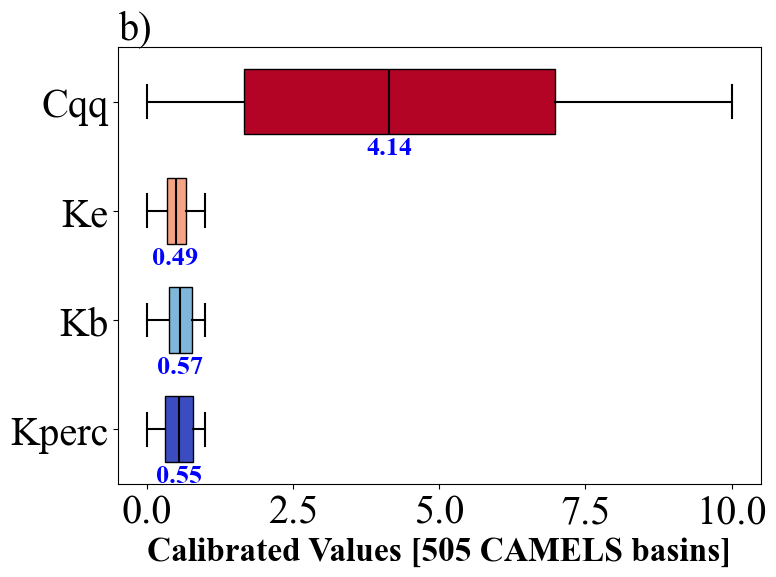

In [ ]:
# ============================================================
# Load required libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ============================================================
# Global Font Settings — Times New Roman everywhere
# ============================================================
LABEL_FONTSIZE = 14

font_path_regular = "C:/Windows/Fonts/times.ttf"
font_path_bold    = "C:/Windows/Fonts/timesbd.ttf"

font_manager.fontManager.addfont(font_path_regular)
font_manager.fontManager.addfont(font_path_bold)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": LABEL_FONTSIZE,
})

# ============================================================
# 0. Load Data
# ============================================================
param_file_path = (
    "F:/Github_repos/Bayesian_DA_Budyko_modeling/"
    "SCE_cal_params/final_calibrated_params_with_KGE.csv"
)

df = pd.read_csv(param_file_path, index_col="Basin")

# ============================================================
# Colors (coolwarm-like)
# ============================================================
coolwarm_colors = {
    "Kperc": "#3B4CC0",
    "Kb":    "#7FB6D9",
    "Ke":    "#F6A385",
    "Cqq":   "#B40426",
}

# ============================================================
# Prepare long data
# ============================================================
params_to_plot = ["Kperc", "Kb", "Ke", "Cqq"]

df_long = (
    df[params_to_plot]
    .reset_index(drop=True)
    .melt(var_name="Parameter", value_name="Value")
)

df_long["Parameter"] = pd.Categorical(
    df_long["Parameter"],
    categories=params_to_plot,
    ordered=True
)

# ============================================================
# Compute statistics for label placement
# ============================================================
df_stats = (
    df_long
    .groupby("Parameter")["Value"]
    .median()
    .reset_index()
)

# y positions (slightly above boxes)
y_positions = np.arange(len(params_to_plot)) + 0.47

# ============================================================
# Plot — Median values ABOVE boxplots
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

box_data = [
    df_long[df_long["Parameter"] == p]["Value"].dropna().values
    for p in params_to_plot
]

bp = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    widths=0.6,
    showfliers=False
)

# Apply colors
for patch, p in zip(bp["boxes"], params_to_plot):
    patch.set_facecolor(coolwarm_colors[p])
    patch.set_edgecolor("black")

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.5)

# Median labels above boxes
for i, (param, median) in enumerate(zip(df_stats["Parameter"], df_stats["Value"])):
    ax.text(
        median,
        y_positions[i],
        f"{median:.2f}",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONTSIZE + 5,
        fontweight="bold",
        color="blue"
    )

# Axis labels
ax.set_yticks(np.arange(1, len(params_to_plot) + 1))
ax.set_yticklabels(params_to_plot)

ax.set_xlabel("Calibrated Values [505 CAMELS basins]",
              fontsize=LABEL_FONTSIZE + 10,
              fontweight="bold")
# ax.set_ylabel("Parameters",
#               fontsize=LABEL_FONTSIZE + 10,
#               fontweight="bold")

# Tick styling
ax.tick_params(axis="both", labelsize=LABEL_FONTSIZE + 15)

# Remove legend
ax.legend([], [], frameon=False)
# ax.set_xlim(0, 5)


ax.set_title('b)', loc='left', fontsize=LABEL_FONTSIZE + 15)
# ============================================================
# Save
# ============================================================
# plt.savefig(
#     "boxplot_median_above_boxes2.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.tight_layout()
plt.show()

# Timeserie plots:

In [ ]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ============================================================
# States to use (fixed, deterministic)
# ============================================================
STATE_LIST = [
    "WASHINGTON",
    "ARIZONA",
    "TEXAS",
    "ALABAMA",
    "NEW YORK",
    "MINNESOTA",
    "MONTANA",
    "KANSAS",
    "MISSOURI",
]

# ============================================================
# Select exactly one basin per state
# ============================================================
def get_state_ids(gdf, states, var, state_list):

    gdf = gdf.to_crs(states.crs)

    gdf_state = gpd.sjoin(
        gdf.dropna(subset=[var]),
        states[["State_Name", "geometry"]],
        how="inner",
        predicate="intersects"
    )

    selected_ids = []

    for st in state_list:
        df_st = gdf_state[gdf_state["State_Name"] == st]

        if len(df_st) == 0:
            continue

        df_st = df_st.copy()
        df_st["lon"] = df_st.geometry.centroid.x
        df_st["lat"] = df_st.geometry.centroid.y

        df_st["d"] = (
            (df_st["lon"] - df_st["lon"].mean())**2 +
            (df_st["lat"] - df_st["lat"].mean())**2
        )

        selected_ids.append(
            df_st.sort_values("d").iloc[0]["gauge_id"]
        )

    return selected_ids

# ============================================================
# Get gauge_ids used in the maps
# ============================================================
top_ids = get_state_ids(
    gdf,
    states,
    var="KGE_DA",
    state_list=STATE_LIST
)

print("Selected basins:", top_ids)

# ============================================================
# Prepare monthly data
# ============================================================
df_m = attrs_all_simu_mean_505_basins_monthly.copy()

df_m["gauge_id"] = (
    df_m["gauge_id"]
    .astype(int)
    .astype(str)
    .str.zfill(8)
)

df_m["time"] = pd.to_datetime(df_m["time"])

df_sel = (
    df_m
    .query("gauge_id in @top_ids")
    .query("'2005-01-01' <= time <= '2010-12-31'")
)

# ============================================================
# Prepare KGE + land cover lookup (from gdf)
# ============================================================
meta = (
    gdf[["gauge_id", "KGE_DA", "dom_land_cover_short"]]
    .assign(
        gauge_id=lambda x: x["gauge_id"]
        .astype(int).astype(str).str.zfill(8)
    )
    .set_index("gauge_id")
)

# ============================================================
# Plot Q time series (3x3 layout)
# ============================================================
fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 6),
    sharex=False
)

axes = axes.flatten()

for ax, gid in zip(axes, top_ids):

    d = (
        df_sel[df_sel["gauge_id"] == gid]
        .sort_values("time")
    )

    ax.plot(
        d["time"], d["Q_obs"],
        color="blue", lw=1, label="Q_obs"
    )

    ax.plot(
        d["time"], d["Q_budyko"],
        color="magenta", lw=1, ls="-.", label="Budyko"
    )

    ax.plot(
        d["time"], d["Q_ens_mean"],
        color="darkgreen", lw=1, label="DA"
    )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------
    ax.set_title(
        f"USGS-ID: {gid}",
        loc="left",
        fontsize=12,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # KGE + land cover annotation
    # --------------------------------------------------------
    kge_val = meta.loc[gid, "KGE_DA"]
    lc_val  = meta.loc[gid, "dom_land_cover_short"]

    ax.text(
        0.01, 0.95,
        f"KGE$_{{DA}}$ = {kge_val:.2f}\nVegetation type = {lc_val}",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    ax.set_ylabel("Q [mm/month]", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

# Hide unused panels
for ax in axes[len(top_ids):]:
    ax.axis("off")

axes[0].legend(
    frameon=True,
    fontsize=8,
    ncol=3,
    loc="upper right"
)

axes[-1].set_xlabel("Time", fontsize=9)

plt.tight_layout()
# plt.savefig(
#     "Q_timeseries_Obs_Budyko_DA_2005_2010_selected_states_3x3_with_KGE_LC.png",
#     bbox_inches="tight"
# )
plt.show()


# Spatial and time series plots:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\654059396.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\654059396.py:235: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top_map["centroid"] = top_map.geometry.centroid
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\654059396.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\654059396.py:235: UserWarning: Geometry is in a geo

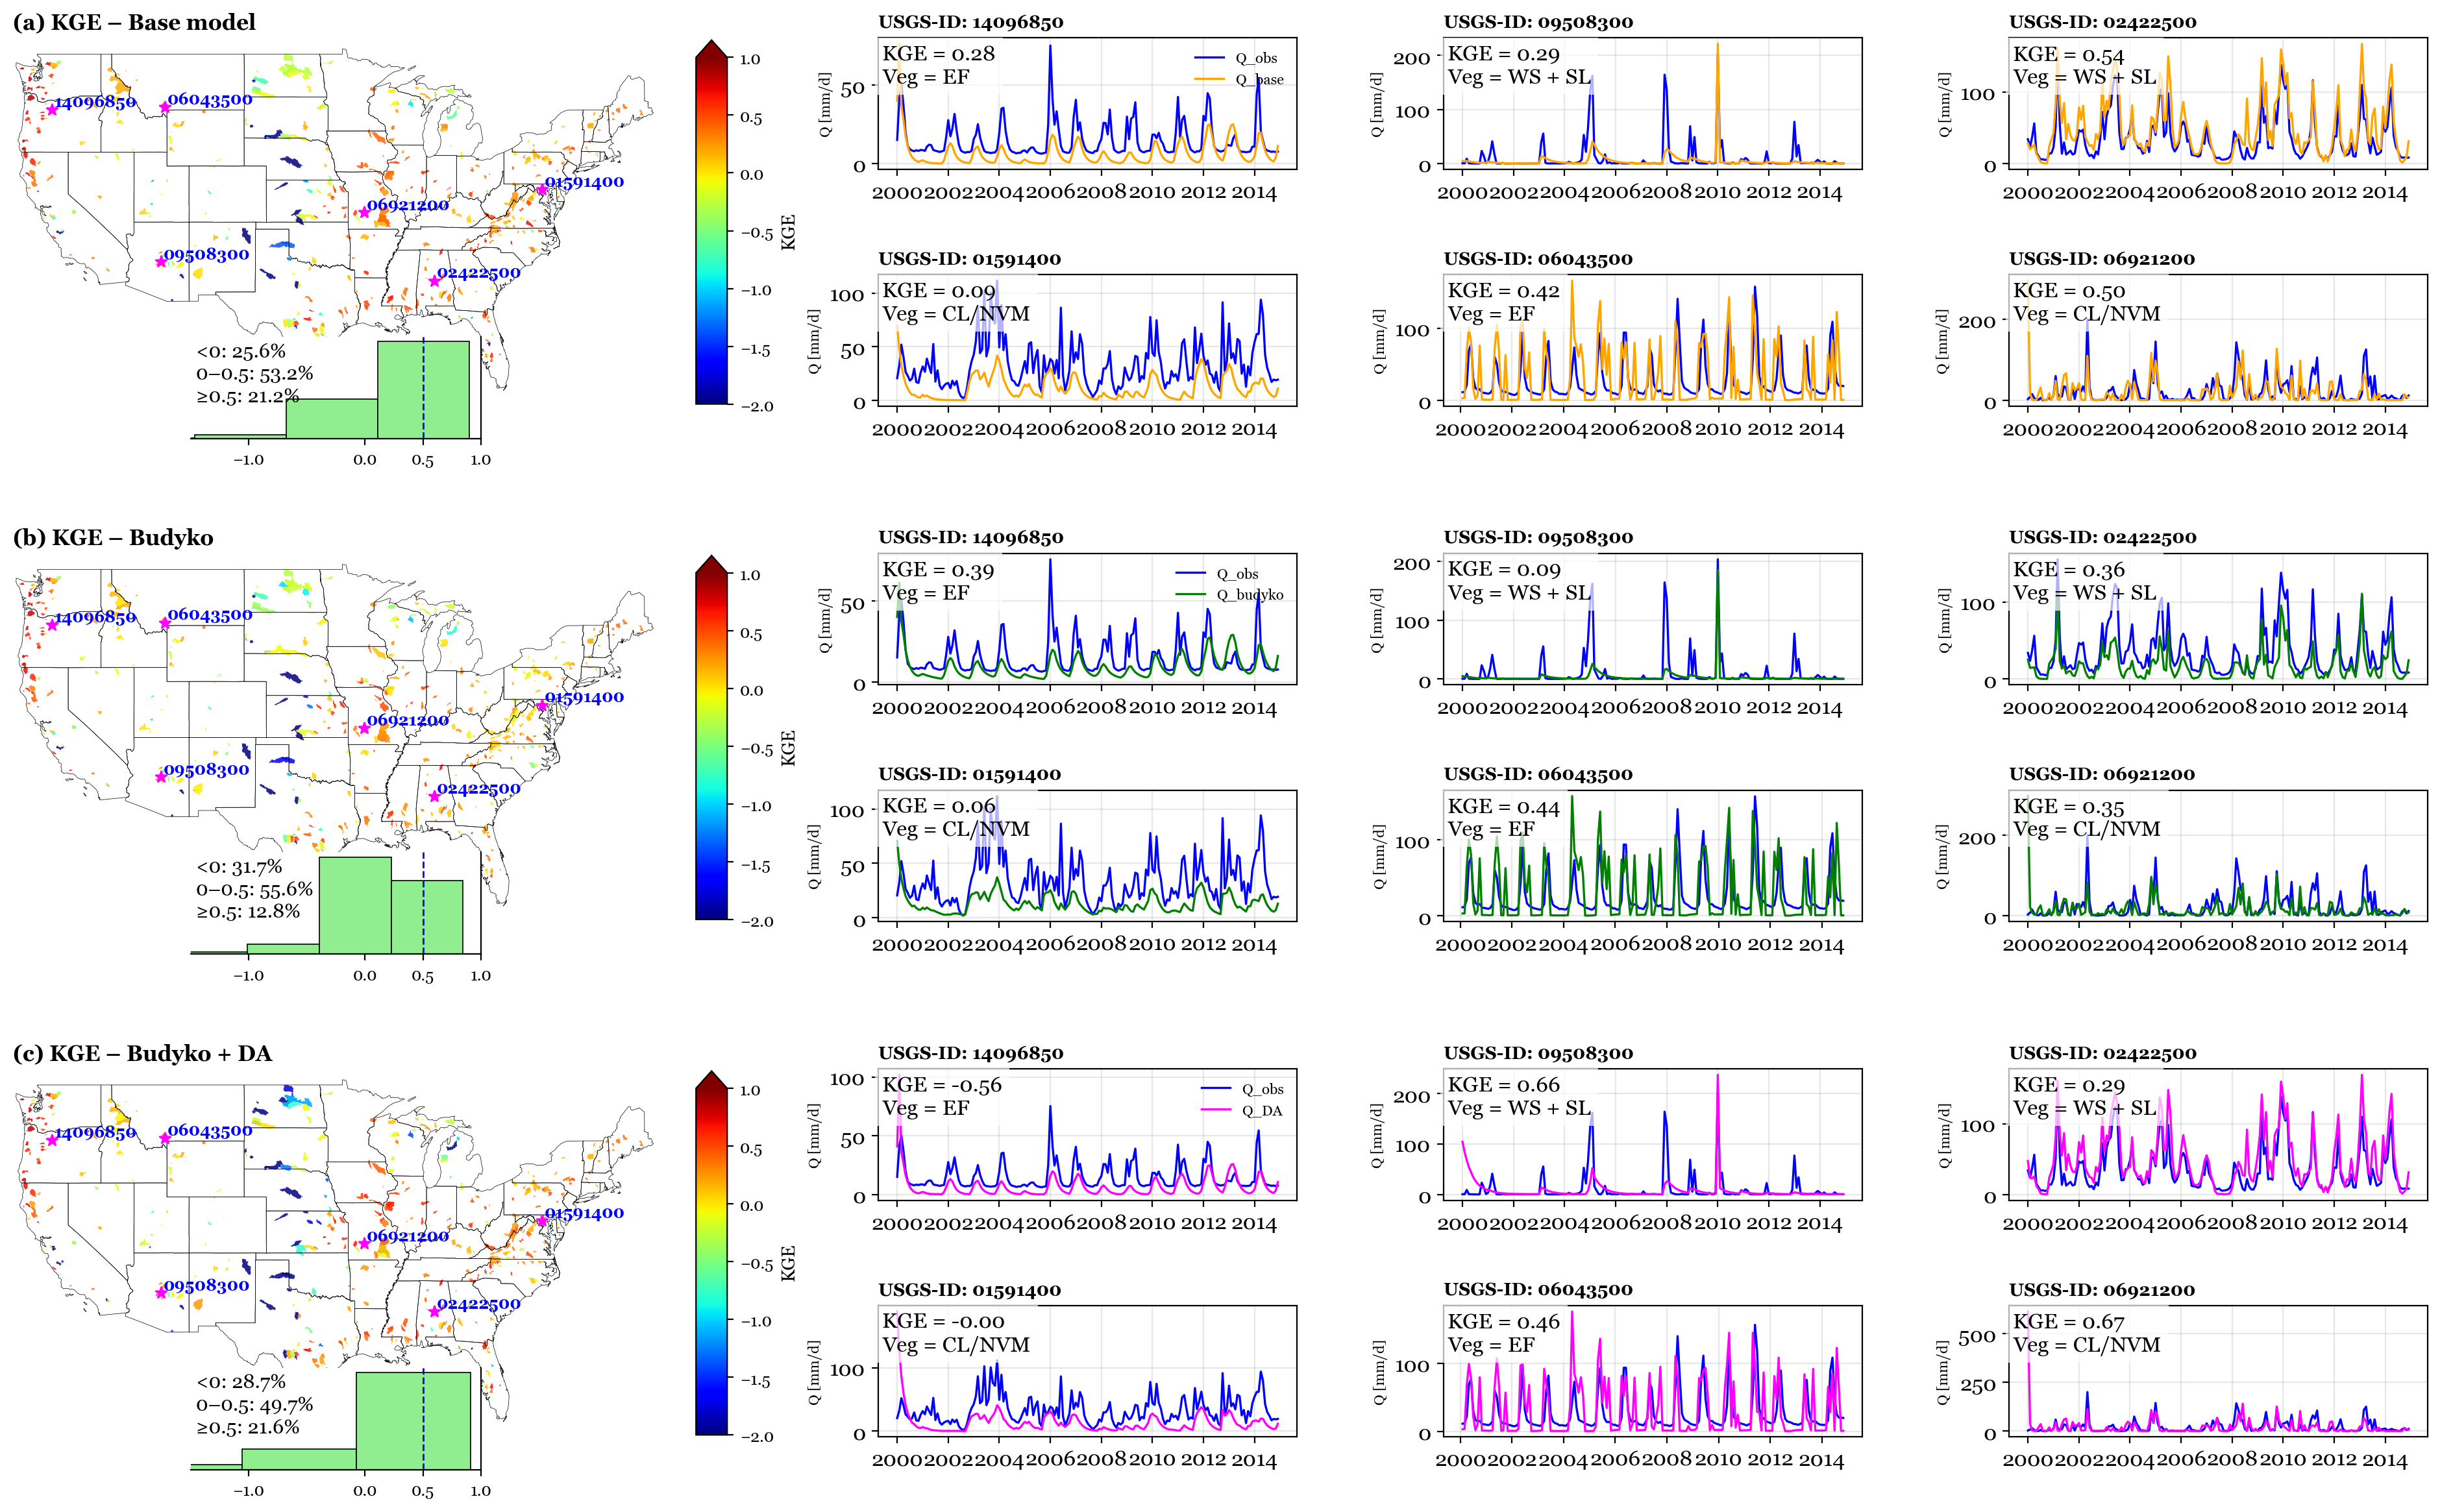

In [ ]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# Load metrics
# ============================================================
metrics_BASE = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BASE_MODEL\metrics_BASE.csv"
)
metrics_BUDYKO = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_MODEL\metrics_BUDYKO.csv"
)
metrics_DA = pd.read_csv(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_BASIN_CALIB_PARAMS\BUDYKO_DA\metrics_BUDYKO_DA.csv"
)

# ============================================================
# Prepare KGE columns
# ============================================================
def prep_kge(df, new_name):
    out = df[["gauge_id", "KGE"]].copy()
    out["gauge_id"] = out["gauge_id"].astype(int).astype(str).str.zfill(8)
    return out.rename(columns={"KGE": new_name})

kge_base   = prep_kge(metrics_BASE,   "KGE_base")
kge_budyko = prep_kge(metrics_BUDYKO, "KGE_budyko")
kge_da     = prep_kge(metrics_DA,     "KGE_DA")

# ============================================================
# Merge with basin attributes
# ============================================================
df = attrs_all_simu_mean_505_basins_longterm.copy()
df["gauge_id"] = df["gauge_id"].astype(int).astype(str).str.zfill(8)

df = (
    df.merge(kge_base,   on="gauge_id", how="left")
      .merge(kge_budyko, on="gauge_id", how="left")
      .merge(kge_da,     on="gauge_id", how="left")
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# ============================================================
# Load CONUS states
# ============================================================
states = gpd.read_file(
    r"F:\Data\Mopex_Boundaries\States_shapefile\States_shapefile.shp"
)
states = states[~states["State_Name"].isin(["ALASKA", "HAWAII"])].to_crs(epsg=4326)

# ============================================================
# Plot settings
# ============================================================
norm = Normalize(vmin=-2, vmax=1)

cmap = plt.cm.jet

CONUS_EXTENT_4326 = (-125, -66.5, 24, 50)

STATE_LIST = [
    "OREGON",
    "ARIZONA",
    "ALABAMA",
    "MARYLAND",
    "MONTANA",
    "MISSOURI",
]

# ============================================================
# Select exactly one basin per state
# ============================================================
def get_state_ids(gdf, states, var, state_list):

    gdf = gdf.to_crs(states.crs).copy()
    gdf["centroid"] = gdf.geometry.centroid

    selected_ids = []

    for st in state_list:
        state_poly = states.loc[
            states["State_Name"] == st, "geometry"
        ].iloc[0]

        df_st = gdf[
            (gdf[var].notna()) &
            (gdf["centroid"].within(state_poly))
        ]

        if df_st.empty:
            continue

        lon0 = state_poly.centroid.x
        lat0 = state_poly.centroid.y

        df_st = df_st.copy()
        df_st["d"] = (
            (df_st["centroid"].x - lon0) ** 2 +
            (df_st["centroid"].y - lat0) ** 2
        )

        selected_ids.append(df_st.sort_values("d").iloc[0]["gauge_id"])

    return selected_ids

# ============================================================
# Prepare monthly data
# ============================================================
df_m = attrs_all_simu_mean_505_basins_monthly.copy()
df_m["gauge_id"] = df_m["gauge_id"].astype(int).astype(str).str.zfill(8)
df_m["time"] = pd.to_datetime(df_m["time"])
df_m = df_m.query("'2000-01-01' <= time <= '2014-12-31'").copy()

# ============================================================
# Resolve discharge columns
# ============================================================
def require_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Missing discharge column: {candidates}")

Q_BASE_COL   = require_col(df_m, ["Q_base", "Q_Base", "Q_ke"])
Q_BUDYKO_COL = require_col(df_m, ["Q_budyko", "Q_Budyko"])
Q_DA_COL     = require_col(df_m, ["Q_ens_mean", "Q_ass"])

# ============================================================
# Scenario configuration
# ============================================================
SCENARIOS = [
    ("KGE_base",   "(a) KGE – Base model",      Q_BASE_COL,   "Q_base",   "orange"),
    ("KGE_budyko", "(b) KGE – Budyko",          Q_BUDYKO_COL, "Q_budyko", "green"),
    ("KGE_DA",     "(c) KGE – Budyko + DA",     Q_DA_COL,     "Q_DA",     "magenta"),
]

# ============================================================
# Combined figure
# ============================================================
fig = plt.figure(figsize=(24, 14), dpi=200)
gs = GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[1.0, 2.4],
    wspace=0.2,
    hspace=0.4
)

for i, (kge_col, map_title, q_sim_col, kge_label, ts_color) in enumerate(SCENARIOS):

    # ---------------- Map ----------------
    ax_map = fig.add_subplot(gs[i, 0])
    states.boundary.plot(ax=ax_map, linewidth=0.25, color="black")

    gdf.plot(
        column=kge_col,
        ax=ax_map,
        cmap=cmap,
        norm=norm,
        linewidth=0,
        alpha=0.85
    )

    ax_map.set_xlim(*CONUS_EXTENT_4326[:2])
    ax_map.set_ylim(*CONUS_EXTENT_4326[2:])
    ax_map.set_title(map_title, loc="left", fontsize=12, fontweight="bold")
    ax_map.set_axis_off()

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []

    bbox = ax_map.get_position()
    cax = fig.add_axes([
        bbox.x1 + 0.012,
        bbox.y0,
        0.01,
        bbox.height
    ])

    cbar = plt.colorbar(sm, cax=cax, extend="max")
    cbar.set_label("KGE", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # ---------------- KGE distribution inset (IMPROVED) ----------------
    kge_vals = gdf[kge_col].dropna().values

    p_neg  = 100 * (kge_vals < 0).mean()
    p_mid  = 100 * ((kge_vals >= 0) & (kge_vals < 0.5)).mean()
    p_high = 100 * (kge_vals >= 0.5).mean()

    ax_in = inset_axes(
        ax_map,
        width="45%",
        height="28%",
        loc="lower center",
        borderpad=-1.6
    )

    ax_in.hist(
        kge_vals,
        bins=50,
        color="lightgreen",
        edgecolor="black",
        linewidth=0.6
    )

    # ax_in.axvline(0,   color="red",  lw=1.0, ls="--")
    ax_in.axvline(0.5, color="blue", lw=1.0, ls="--")

    ax_in.set_xlim(-1.5, 1.0)
    ax_in.set_xticks([-1, 0, 0.5, 1])
    ax_in.tick_params(axis="x", labelsize=9)
    ax_in.set_yticks([])

    # remove top & left spines
    ax_in.spines["top"].set_visible(False)
    ax_in.spines["left"].set_visible(False)

    ax_in.text(
        0.02, 0.95,
        f"<0: {p_neg:.1f}%\n0–0.5: {p_mid:.1f}%\n≥0.5: {p_high:.1f}%",
        transform=ax_in.transAxes,
        va="top",
        fontsize=11
    )

    # ---------------- Basin selection ----------------
    top_ids = get_state_ids(gdf, states, kge_col, STATE_LIST)
    top_map = gdf[gdf["gauge_id"].isin(top_ids)].copy()
    top_map["centroid"] = top_map.geometry.centroid

    ax_map.scatter(
        top_map["centroid"].x,
        top_map["centroid"].y,
        s=40,
        marker="*",
        c="magenta",
        zorder=6
    )

    for _, row in top_map.iterrows():
        ax_map.text(
            row["centroid"].x + 0.2,
            row["centroid"].y + 0.2,
            row["gauge_id"],
            fontsize=9,
            fontweight="bold",
            color="blue"
        )

    # ---------------- Time series (2 × 3) ----------------
    subgs = gs[i, 1].subgridspec(2, 3, wspace=0.35, hspace=0.8)
    axes_ts = [fig.add_subplot(subgs[r, c]) for r in range(2) for c in range(3)]

    meta = gdf[["gauge_id", kge_col, "dom_land_cover_short"]].set_index("gauge_id")
    df_sel = df_m.query("gauge_id in @top_ids")

    for ax, gid in zip(axes_ts, top_ids):

        d = df_sel[df_sel["gauge_id"] == gid].sort_values("time")

        ax.plot(d["time"], d["Q_obs"], color="blue", lw=1.2, label="Q_obs")
        ax.plot(d["time"], d[q_sim_col], color=ts_color, lw=1.2, label=kge_label)

        ax.set_title(f"USGS-ID: {gid}", loc="left", fontsize=10, fontweight="bold")

        ax.text(
            0.01, 0.95,
            f"KGE = {meta.loc[gid, kge_col]:.2f}\nVeg = {meta.loc[gid, 'dom_land_cover_short']}",
            transform=ax.transAxes,
            fontsize=12,
            va="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.set_ylabel("Q [mm/d]", fontsize=8)
        ax.grid(alpha=0.3)

    for ax in axes_ts[len(top_ids):]:
        ax.axis("off")

    axes_ts[0].legend(fontsize=8, loc="upper right", frameon=False)

# ============================================================
# Save + show
# ============================================================
plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
# plt.savefig(
#     "KGE_maps_and_timeseries_3rows_2cols_with_2x3_timeseries.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.tight_layout()
plt.show()


#  Budyko final : Calibrated:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\1183643463.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 1])


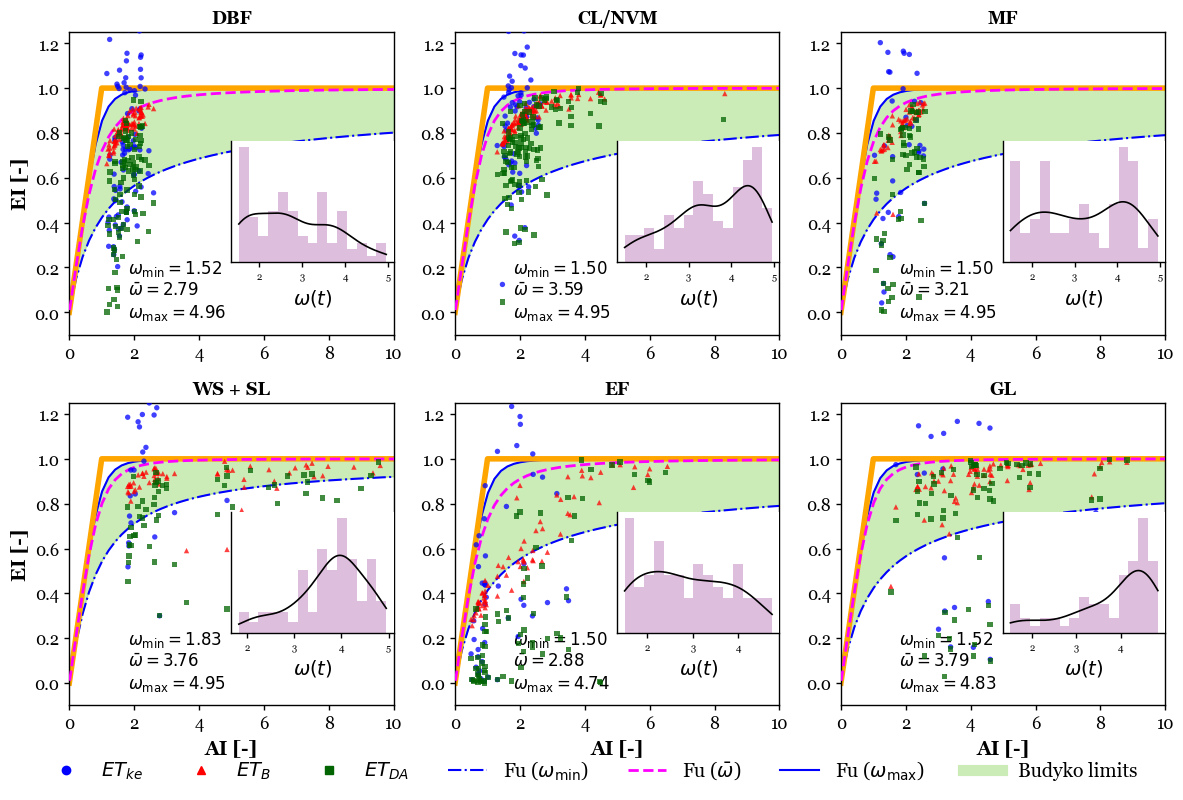

In [ ]:

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# GLOBAL STYLE
# ============================================================
plt.rcParams.update({
    "font.family": "Georgia",
    "axes.linewidth": 1.0,
    "axes.labelsize": 8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

# ============================================================
# DATA
# ============================================================
df = attrs_all_simu_mean_505_basins_longterm.copy()
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# RECOMPUTE AI & EI
# ============================================================
df["AI_base"] = df["PET"] / df["P_eff_base"]
df["AI_B"]    = df["PET"] / df["P_eff_B"]
df["AI_ass"]  = df["PET"] / df["P_eff_ass"]

df["EI_base"] = df["ET_ke"]  / df["P_eff_base"]
df["EI_B"]    = df["ET_B"]   / df["P_eff_B"]
df["EI_ass"]  = df["ET_ass"] / df["P_eff_ass"]

for c in ["AI_base","AI_B","AI_ass","EI_base","EI_B","EI_ass"]:
    df.loc[~np.isfinite(df[c]), c] = np.nan

# ============================================================
# FU BUDYKO FUNCTION
# ============================================================
def Fu(AI, omega):
    AI = np.maximum(AI, 1e-6)
    return 1.0 + AI - (1.0 + AI**omega) ** (1.0 / omega)

AI_range = np.linspace(0.01, 100.0, 500)

# ============================================================
# LAND COVER CLASSES
# ============================================================
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# ET SCENARIOS
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_ass"]
model_colors = {"ET_ke": "blue", "ET_B": "red", "ET_ass": "darkgreen"}
model_markers = {"ET_ke": "o", "ET_B": "^", "ET_ass": "s"}

model_map = {
    "ET_ke":  ("AI_base", "EI_base"),
    "ET_B":   ("AI_B",    "EI_B"),
    "ET_ass": ("AI_ass",  "EI_ass"),
}

# ============================================================
# BUILD FIGURE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc]

    # --------------------------------------------------------
    # PANEL-SPECIFIC BUDYKO ENVELOPE + FU CURVES
    # --------------------------------------------------------
    omega_vals = filtered["omega_true"].values
    omega_vals = omega_vals[np.isfinite(omega_vals) & (omega_vals > 0)]

    if omega_vals.size > 5:

        ωmin  = np.nanmin(omega_vals)
        ωmean = np.nanmean(omega_vals)
        ωmax  = np.nanmax(omega_vals)

        EI_min  = Fu(AI_range, ωmin)
        EI_mid  = Fu(AI_range, ωmean)
        EI_max  = Fu(AI_range, ωmax)

        ax.fill_between(AI_range, EI_min, EI_max,
                        color="#6ac932", alpha=0.35, zorder=1)

        ax.plot(AI_range, EI_min,  color="blue",    lw=1.5, ls="-.", zorder=2)
        ax.plot(AI_range, EI_mid,  color="magenta", lw=2.0, ls="--", zorder=3)
        ax.plot(AI_range, EI_max,  color="blue",   lw=1.5, zorder=2)

        # ---- panel-specific ω annotation
        ax.text(
            0.18, 0.25,
            rf"$\omega_{{\min}}={ωmin:.2f}$" "\n"
            rf"$\bar{{\omega}}={ωmean:.2f}$" "\n"
            rf"$\omega_{{\max}}={ωmax:.2f}$",
            transform=ax.transAxes,
            fontsize=12,
            va="top"
        )

    # --------------------------------------------------------
    # SCATTER POINTS
    # --------------------------------------------------------
    for nm in model_items:
        ai_col, ei_col = model_map[nm]
        plot_data = filtered[[ai_col, ei_col]].dropna()
        if plot_data.empty:
            continue

        ax.scatter(plot_data[ai_col], plot_data[ei_col],
                   s=15, alpha=0.75,
                   color=model_colors[nm],
                   marker=model_markers[nm],
                   edgecolor="none",
                   zorder=4)

    # --------------------------------------------------------
    # OMEGA DISTRIBUTION INSET
    # --------------------------------------------------------
    if omega_vals.size > 10:

        iax = inset_axes(
            ax, width="50%", height="40%",
            bbox_to_anchor=(0.5, 0.24, 1, 1),
            bbox_transform=ax.transAxes,
            loc="lower left", borderpad=0
        )

        iax.hist(omega_vals, bins=15, density=True,
                 color="#c994c7", alpha=0.6, edgecolor="none")

        kde = gaussian_kde(omega_vals)
        x_kde = np.linspace(omega_vals.min(), omega_vals.max(), 300)
        iax.plot(x_kde, kde(x_kde), color="black", lw=1.2)

        iax.set_yticks([])
        iax.set_xlabel(r"$\omega(t)$", fontsize=14)
        iax.tick_params(axis="x", labelsize=7)

        for spine in ["top", "right"]:
            iax.spines[spine].set_visible(False)

    # --------------------------------------------------------
    # FORMATTING
    # --------------------------------------------------------
    ax.set_title(lc, fontsize=13, fontweight="bold")
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.1, 1.25)
    # ax.plot([0, 1, 50], [0, 1, 1], color="darkgray", lw=1.5)
    ax.plot([0, 1, 15], [0, 1, 1], color='orange', lw=4)

    ax.set_xlabel("AI [-]", fontsize=14)
    ax.set_ylabel("EI [-]", fontsize=14)

# ============================================================
# GLOBAL LEGEND (NO ω VALUES)
# ============================================================
legend_handles = [
    Line2D([0],[0], marker="o", color="blue", linestyle="None", label=r"$ET_{ke}$"),
    Line2D([0],[0], marker="^", color="red", linestyle="None", label=r"$ET_{B}$"),
    Line2D([0],[0], marker="s", color="darkgreen", linestyle="None", label=r"$ET_{DA}$"),

    Line2D([0],[0], color="blue", lw=1.5, ls="-.",
           label=r"Fu ($\omega_{\min}$)"),
    Line2D([0],[0], color="magenta", lw=2.0, ls="--",
           label=r"Fu ($\bar{\omega}$)"),
    Line2D([0],[0], color="blue", lw=1.5,
           label=r"Fu ($\omega_{\max}$)"),

    Line2D([0],[0], color="#6ac932", lw=8, alpha=0.35,
           label="Budyko limits"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=7,
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, -0.01)
)

# remove top-row xlabels
for ax in axes[:3]:
    ax.set_xlabel("")

# keep ylabels only first column
for i, ax in enumerate(axes):
    if i not in [0, 3]:
        ax.set_ylabel("")

# tick size
for ax in axes:
    ax.tick_params(axis="both", which="major", labelsize=12)

plt.tight_layout(rect=[0, 0.02, 1, 1])
# plt.savefig("Budyko_Calibrated.png", dpi=600, facecolor="white")
plt.show()



# Omega_true vs Omega MLR:

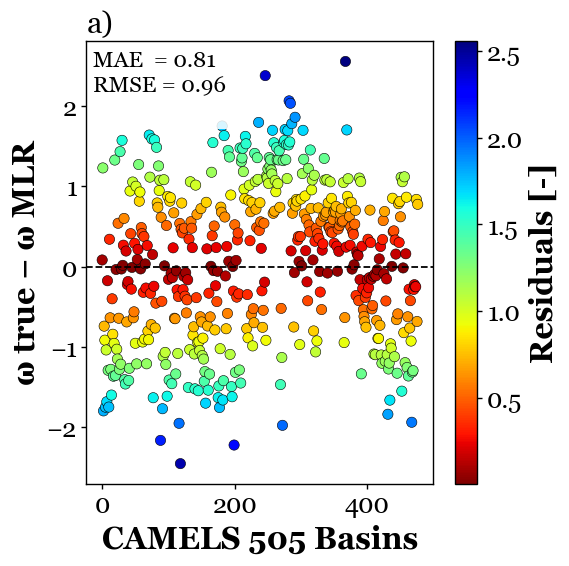

In [ ]:
plt.figure(figsize=(6, 6))

LABEL_FONTSIZE = 22
TICK_FONTSIZE  = 18
CBAR_FONTSIZE  = 18

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# -------------------------------------------------
# Residuals
# -------------------------------------------------
x = np.arange(len(attrs_all_simu_mean_505_basins_longterm))
y_true = attrs_all_simu_mean_505_basins_longterm["omega_true"].values
y_mlr  = attrs_all_simu_mean_505_basins_longterm["omega_MLR"].values

residual  = y_true - y_mlr
deviation = np.abs(residual)

# -------------------------------------------------
# Scatter plot
# -------------------------------------------------
sc = plt.scatter(
    x,
    residual,
    c=deviation,
    cmap="jet_r",
    s=55,
    edgecolor="k",
    linewidth=0.4
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.3)

plt.xlabel("CAMELS 505 Basins")
plt.ylabel("ω true − ω MLR")

plt.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)
plt.title('a)', fontsize=LABEL_FONTSIZE, loc='left')

cbar = plt.colorbar(sc)
cbar.set_label("Residuals [-]", fontsize=LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_FONTSIZE)


# -------------------------------------------------
# Statistical summary
# -------------------------------------------------
ME   = np.mean(residual)
MAE  = np.mean(np.abs(residual))
RMSE = np.sqrt(np.mean(residual**2))
STD  = np.std(residual, ddof=1)

stats_text = (
    # f"ME   = {ME:.2f}\n"
    f"MAE  = {MAE:.2f}\n"
    f"RMSE = {RMSE:.2f}\n"
    # f"STD  = {STD:.2f}"
)

plt.gca().text(
    0.02, 0.98,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment="top",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85)
)

plt.tight_layout()
# plt.savefig("omega_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Dynamic Budyko: calibrated

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\3842856234.py:454: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


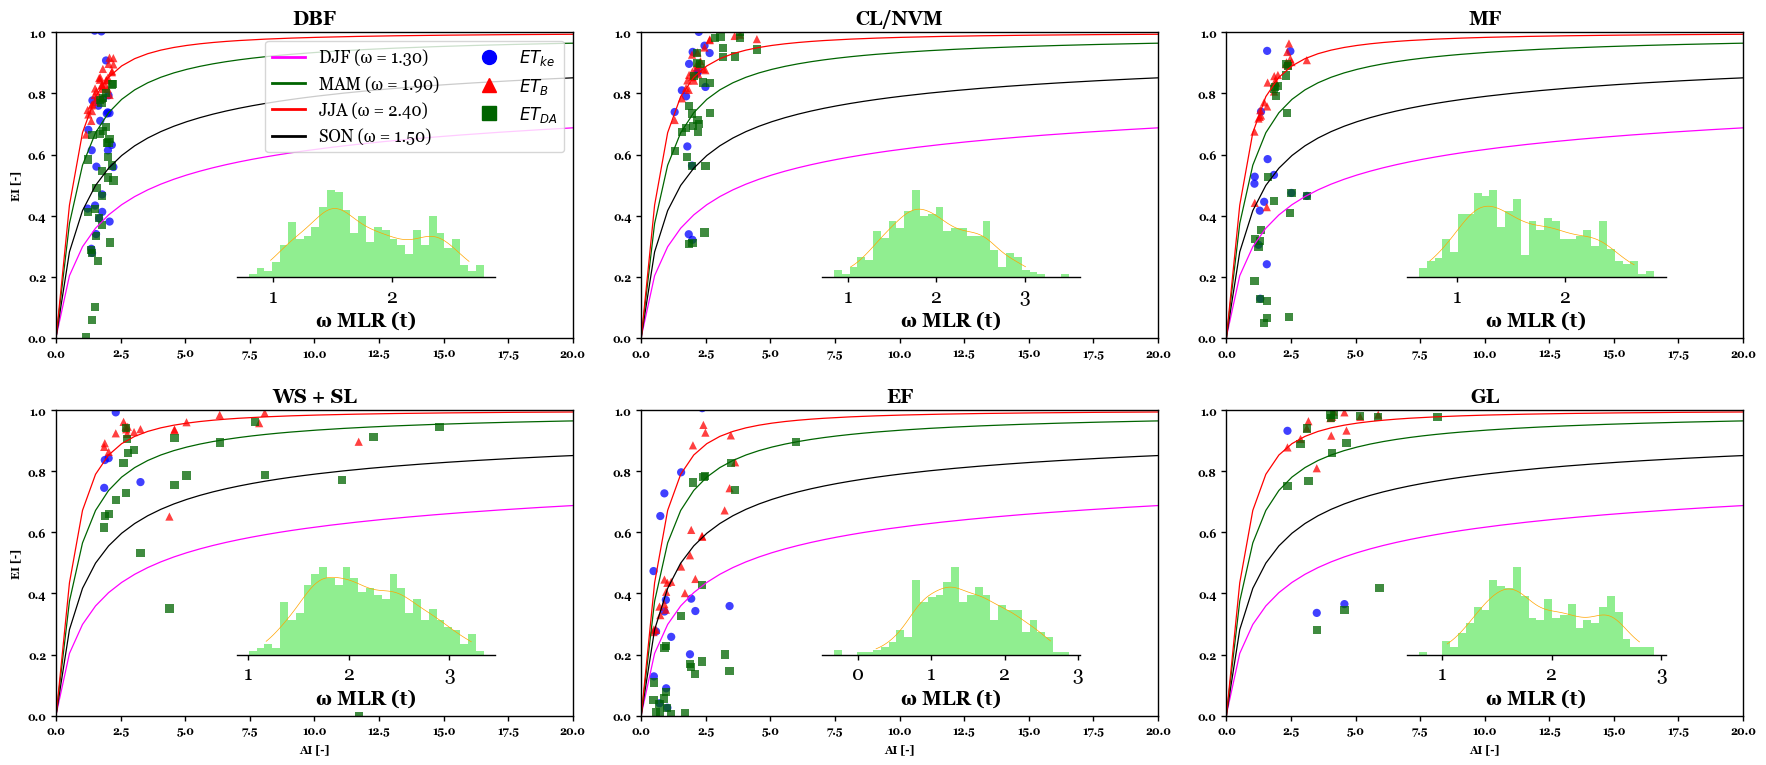

In [ ]:



# ============================================================
# GLOBAL STYLE (theme_bw(base_family="Georgia"))
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

# ============================================================
# LOAD DATA
# ============================================================

df = attrs_all_simu_mean_505_basins.copy()
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    AIc = np.maximum(AI, 1e-6)
    return 1 + AIc - (1 + AIc**omega) ** (1.0 / omega)

AI_range = np.concatenate(([0], np.linspace(0.01, 100, 199)))
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# SEASONS & OMEGA VALUES
# ============================================================
seasons = ["DJF", "MAM", "JJA", "SON"]

omega_seasonal_mean = pd.DataFrame({
    "season": seasons,
    "omega": [1.3, 1.9, 2.4, 1.5]   # same as your R code
}).sort_values("omega")

season_order = omega_seasonal_mean["season"].tolist()

season_colors = {
    "DJF": "magenta",
    "MAM": "darkgreen",
    "JJA": "red",
    "SON": "black"
}

season_labels = {
    row["season"]: f"{row['season']} (ω = {row['omega']:.2f})"
    for _, row in omega_seasonal_mean.iterrows()
}

# ============================================================
# SCENARIOS (models)
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_DA"]
model_colors = {
    "ET_ke": "blue",
    "ET_B": "red",
    "ET_DA": "darkgreen"
}
model_markers = {
    "ET_ke": "o",   # 19 filled circle
    "ET_B": "^",    # 17 triangle
    "ET_DA": "s"    # 15 square
}

# mapping AI/EI columns
model_map = {
    "ET_ke": ("AI_base",  "EI_base"),
    "ET_B":  ("AI_B",   "EI_B"),
    "ET_DA": ("AI_ass", "EI_ass")
}

# ============================================================
# BUILD PANELS
# ============================================================



fig, axes = plt.subplots(2, 3, figsize=(18, 8))#, dpi=300)
axes = axes.flatten()

np.random.seed(123)

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # ----------------------------------------------------------
    # SEASONAL BUDYKO CURVES
    # ----------------------------------------------------------
    for ss in season_order:
        om = float(omega_seasonal_mean.loc[omega_seasonal_mean["season"] == ss, "omega"].values[0])
        EI_curve = Fu(AI_range, om)
        ax.plot(AI_range, EI_curve, color=season_colors[ss], linewidth=0.9)

    # ----------------------------------------------------------
    # SCATTER DATA
    # ----------------------------------------------------------
    for nm in model_items:
        ai_col, ei_col = model_map[nm]
        if ai_col in filtered.columns and ei_col in filtered.columns:
            plot_data = filtered[[ai_col, ei_col]].rename(columns={ai_col: "AI", ei_col: "EI"})
            plot_data = plot_data[np.isfinite(plot_data["AI"]) & np.isfinite(plot_data["EI"])]

            ax.scatter(
                plot_data["AI"], plot_data["EI"],
                s=35,
                alpha=0.75,
                lw=0.0,
                color=model_colors[nm],
                marker=model_markers[nm],
                edgecolor="none"
            )

    # ----------------------------------------------------------
    # VEGETATION-SPECIFIC OMEGA DISTRIBUTION INSET
    # ----------------------------------------------------------
    veg_mean_shift = [0.00, 0.20, -0.15, 0.35, -0.30, 0.10][i]
    veg_sd         = [0.18, 0.25, 0.22, 0.30, 0.35, 0.20][i]

    omega_samples = []
    for mu in omega_seasonal_mean["omega"].values:
        omega_samples.append(np.random.normal(loc=mu + veg_mean_shift, scale=veg_sd, size=100))
    omega_dist = np.concatenate(omega_samples)

    q01, q99 = np.quantile(omega_dist, [0.01, 0.99])

    # inset axes
    iax = inset_axes(
        ax,
        width="50%", height="30%",
        loc="lower left",
        bbox_to_anchor=(0.35, 0.2, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    # histogram density
    bins = 30
    iax.hist(
        omega_dist,
        bins=bins,
        density=True,
        color="lightgreen",
        edgecolor="black",
        linewidth=0
    )

    # density line
    kde = gaussian_kde(omega_dist)
    x_kde = np.linspace(q01, q99, 100)
    y_kde = kde(x_kde)
    iax.plot(x_kde, y_kde, color="orange", linewidth=0.5)

    # iax.set_xlim(q01, q99)
    iax.set_yticks([])

    iax.set_xlabel("ω MLR (t)", fontsize=14)
    iax.tick_params(axis="x", labelsize=14)
    for spine in ["top", "right", "left"]:
        iax.spines[spine].set_visible(False)


    # Title bold (like element_markdown **lc**)
    ax.set_title(lc, fontsize=14, fontweight="bold")

    # axis labels only for selected panels (same logic as R)
    ax.set_xlabel("AI [-]" if (i+1) in [4, 5, 6] else "")
    ax.set_ylabel("EI [-]" if (i+1) in [1, 4] else "")

    # ticks bold
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

# ============================================================
# BUILD ONE SHARED LEGEND (bottom)
# ============================================================
legend_handles = []

# seasons (lines)
for ss in seasons:
    legend_handles.append(
        Line2D([0], [0], color=season_colors[ss], lw=2,
               label=season_labels[ss])
    )

# models (points)
legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_ke"], linestyle="None",
           markerfacecolor=model_colors["ET_ke"],
           markeredgecolor=model_colors["ET_ke"],  
           markersize=10, label=r"$ET_{ke}$")
)

legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_B"], linestyle="None",
           markerfacecolor=model_colors["ET_B"],
           markeredgecolor=model_colors["ET_B"],    
           markersize=10, label=r"$ET_{B}$")
)

legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_DA"], linestyle="None",
           markerfacecolor=model_colors["ET_DA"],
           markeredgecolor=model_colors["ET_DA"],  
           markersize=10, label=r"$ET_{DA}$")
)


# ✅ Put legend on first subplot
axes[0].legend(
    handles=legend_handles,
    loc="upper right",
    ncol=2,
    frameon=True,
    fontsize=12
)
for ax in axes:
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 1)


plt.tight_layout()
# plt.subplots_adjust(bottom=0.18, wspace=0.25, hspace=0.35)
plt.show()


# Budyko : Omega true

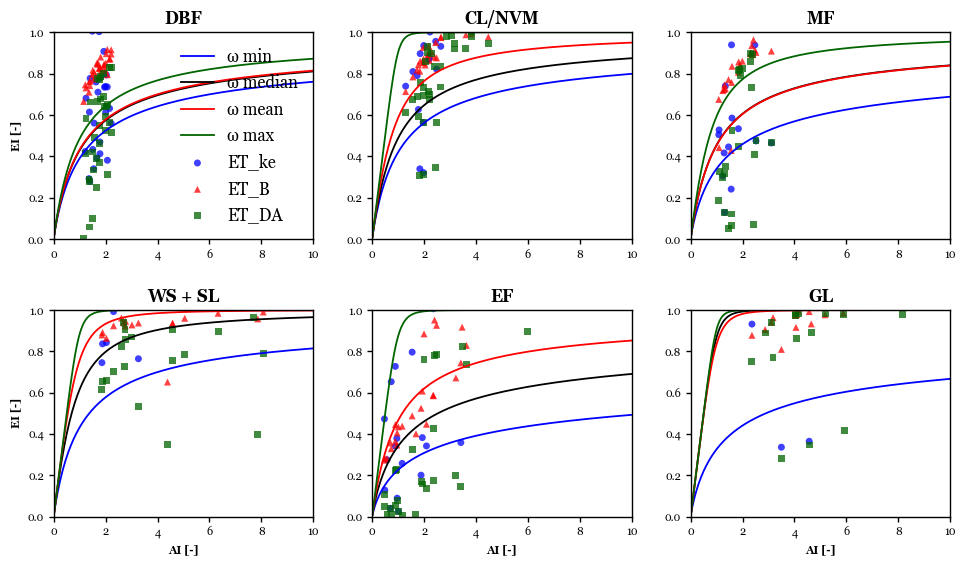

In [ ]:
# ============================================================
# GLOBAL STYLE
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

# ============================================================
# LOAD DATA
# ============================================================
df = attrs_all_simu_mean_505_basins.copy()
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    AIc = np.maximum(AI, 1e-6)
    return 1 + AIc - (1 + AIc**omega) ** (1.0 / omega)

AI_range = np.linspace(0.01, 10, 200)
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# SCENARIOS (models)
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_DA"]
model_colors = {"ET_ke":"blue","ET_B":"red","ET_DA":"darkgreen"}
model_markers = {"ET_ke":"o","ET_B":"^","ET_DA":"s"}

model_map = {
    "ET_ke": ("AI_base","EI_base"),
    "ET_B":  ("AI_B","EI_B"),
    "ET_DA": ("AI_ass","EI_ass")
}

# ============================================================
# BUILD PANELS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

from scipy.optimize import minimize

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # ----------------------------------------------------------
    # 1) COMPUTE AI & EI FROM SFET
    # ----------------------------------------------------------
    filtered["AI_fit"] = filtered["PET"] / filtered["P"]
    filtered["EI_fit"] = filtered["SFET"] / filtered["P"]

    filtered = filtered[
        np.isfinite(filtered["AI_fit"]) &
        np.isfinite(filtered["EI_fit"]) &
        (filtered["P"] > 0)
    ]

    # ----------------------------------------------------------
    # 2) FIT ω FOR EACH BASIN (SFET-based)
    # ----------------------------------------------------------
    omega_vals = []

    for _, row in filtered.iterrows():

        AI_val = row["AI_fit"]
        EI_val = row["EI_fit"]

        def obj(w):
            return (EI_val - Fu(AI_val, w[0]))**2

        res = minimize(obj, x0=[2.0], bounds=[(0.5, 10)])
        omega_vals.append(res.x[0])

    omega_vals = np.array(omega_vals)

    if len(omega_vals) > 0:

        omega_stats = {
            "min":    np.nanmin(omega_vals),
            "median": np.nanmedian(omega_vals),
            "mean":   np.nanmean(omega_vals),
            "max":    np.nanmax(omega_vals),
        }

        colors = {
            "min":"blue",
            "median":"black",
            "mean":"red",
            "max":"darkgreen"
        }

        # ----------------------------------------------------------
        # 3) PLOT FOUR FITTED BUDYKO CURVES
        # ----------------------------------------------------------
        for k in ["min","median","mean","max"]:
            om = omega_stats[k]
            ax.plot(
                AI_range,
                Fu(AI_range, om),
                color=colors[k],
                linewidth=1.3,
                label=f"ω {k}" if i == 0 else None
            )

    # ----------------------------------------------------------
    # 4) ADD SCATTER FROM THREE ET SCENARIOS
    # ----------------------------------------------------------
    for nm in model_items:

        ai_col, ei_col = model_map[nm]

        if ai_col in filtered.columns and ei_col in filtered.columns:

            plot_data = filtered[[ai_col, ei_col]].dropna()

            ax.scatter(
                plot_data[ai_col],
                plot_data[ei_col],
                s=25,
                alpha=0.75,
                color=model_colors[nm],
                marker=model_markers[nm],
                edgecolor="none",
                label=nm if i == 0 else None
            )

    ax.set_title(lc, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)

    if i in [3,4,5]:
        ax.set_xlabel("AI [-]")
    if i in [0,3]:
        ax.set_ylabel("EI [-]")

# ----------------------------------------------------------
# LEGEND (ONLY ON FIRST PANEL)
# ----------------------------------------------------------
axes[0].legend(loc="lower right", fontsize=12, frameon=False)

plt.tight_layout()
plt.show()


# Budyko: Omega_MLR

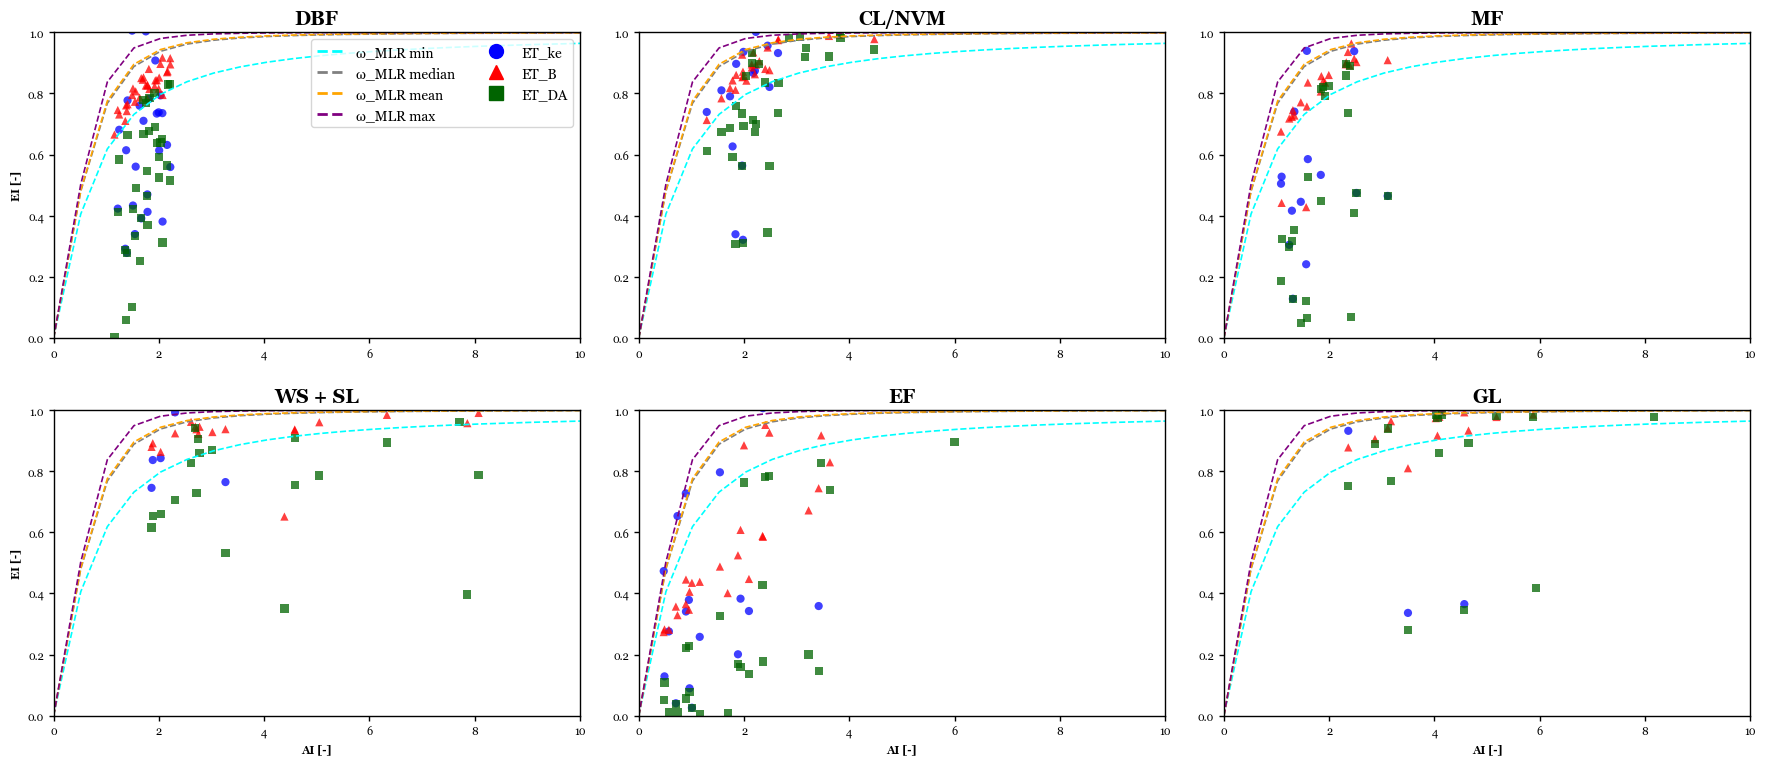

In [ ]:
# ============================================================
# GLOBAL STYLE
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

# ============================================================
# LOAD DATA
# ============================================================
df = attrs_all_simu_mean_505_basins.copy()
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    AIc = np.maximum(AI, 1e-6)
    return 1 + AIc - (1 + AIc**omega) ** (1.0 / omega)

AI_range = np.concatenate(([0], np.linspace(0.01, 100, 199)))
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# REAL OMEGA STATISTICS
# ============================================================



omega_true_vals = df["omega_true"].dropna().values
omega_mlr_vals  = df["omega_MLR"].dropna().values

stat_order = ["min", "median", "mean", "max"]

omega_true_stats = {
    "min":    np.nanmin(omega_true_vals),
    "median": np.nanmedian(omega_true_vals),
    "mean":   np.nanmean(omega_true_vals),
    "max":    np.nanmax(omega_true_vals),
}

omega_mlr_stats = {
    "min":    np.nanmin(omega_mlr_vals),
    "median": np.nanmedian(omega_mlr_vals),
    "mean":   np.nanmean(omega_mlr_vals),
    "max":    np.nanmax(omega_mlr_vals),
}

colors_true = {"min":"blue","median":"black","mean":"red","max":"darkgreen"}
colors_mlr  = {"min":"cyan","median":"gray","mean":"orange","max":"purple"}

# ============================================================
# SCENARIOS (models)
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_DA"]
model_colors = {"ET_ke":"blue","ET_B":"red","ET_DA":"darkgreen"}
model_markers = {"ET_ke":"o","ET_B":"^","ET_DA":"s"}

model_map = {
    "ET_ke": ("AI_base","EI_base"),
    "ET_B":  ("AI_B","EI_B"),
    "ET_DA": ("AI_ass","EI_ass")
}
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # ----------------------------------------------------------
    # BUDYKO CURVES FROM omega_MLR (dashed)
    # ----------------------------------------------------------
    for k in stat_order:
        om = omega_mlr_stats[k]
        ax.plot(AI_range, Fu(AI_range, om),
                color=colors_mlr[k],
                linestyle="--",
                linewidth=1.2)

    # ----------------------------------------------------------
    # SCATTER DATA
    # ----------------------------------------------------------
    for nm in model_items:
        ai_col, ei_col = model_map[nm]
        if ai_col in filtered.columns and ei_col in filtered.columns:
            plot_data = filtered[[ai_col, ei_col]].dropna()
            ax.scatter(
                plot_data[ai_col],
                plot_data[ei_col],
                s=35,
                alpha=0.75,
                lw=0.0,
                color=model_colors[nm],
                marker=model_markers[nm],
                edgecolor="none"
            )

    ax.set_title(lc, fontsize=14, fontweight="bold")
    ax.set_xlabel("AI [-]" if (i+1) in [4,5,6] else "")
    ax.set_ylabel("EI [-]" if (i+1) in [1,4] else "")

# Legend
legend_handles = []

for k in stat_order:
    legend_handles.append(
        Line2D([0],[0],
               color=colors_mlr[k],
               lw=2,
               linestyle="--",
               label=f"ω_MLR {k}")
    )

for nm in model_items:
    legend_handles.append(
        Line2D([0],[0],
               marker=model_markers[nm],
               linestyle="None",
               markerfacecolor=model_colors[nm],
               markeredgecolor=model_colors[nm],
               markersize=10,
               label=nm)
    )

axes[0].legend(handles=legend_handles,
               loc="upper right",
               ncol=2,
               frameon=True,
               fontsize=10)

for ax in axes:
    ax.set_xlim(0,10)
    ax.set_ylim(0,1)

plt.tight_layout()
plt.show()


# ET Compariosn: Uncalibrated:

Found feather files for 151 basins in BUDYKO_DA
Found feather files for 151 basins in Budyko MODEL
Found feather files for 151 basins in BASE MODEL
Common basins: 150


c:\Users\hdagne1\AppData\Local\anaconda3\envs\BUDYKO-dev\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hdagne1\AppData\Local\anaconda3\envs\BUDYKO-dev\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_56496\1868920908.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


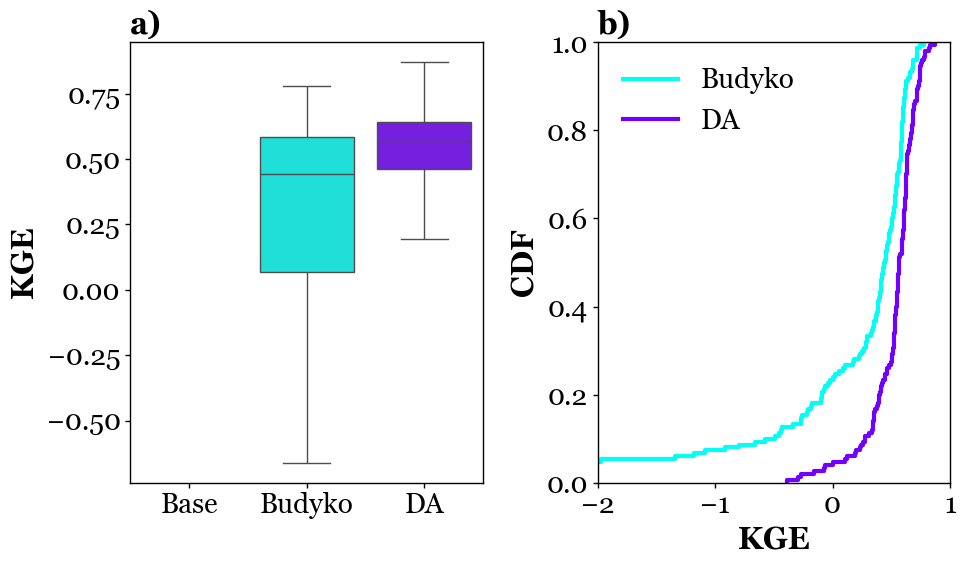

In [ ]:
# ============================================================
# ET Performance vs SFET
# KGE boxplots + ECDF (UNCALIB)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(evaluation, simulation):
    e = np.asarray(evaluation, dtype=float)
    s = np.asarray(simulation, dtype=float)

    m = np.isfinite(e) & np.isfinite(s)
    e, s = e[m], s[m]

    if len(e) < 5:
        return np.nan

    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan
    beta  = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)


# ============================================================
# 1) Load SFET (monthly)
# ============================================================
SFET = pd.read_feather(
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather"
)

SFET["time"] = pd.to_datetime(SFET["time"])
SFET = SFET.set_index("time").sort_index()

SFET.columns = SFET.columns.astype(str).str.strip()
SFET = SFET.loc[:, ~SFET.columns.duplicated()]

SFET_monthly = SFET.resample("MS").sum()
SFET_monthly.index.name = "time"


# ============================================================
# 2) ET_ass (BUDYKO_DA, UNCALIB)
# ============================================================
BASE_DIR = (
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_DA\TEST"
)

files = glob.glob(os.path.join(BASE_DIR, "enkf_ensemble_BUDYKO_DA_*.feather"))
print(f"Found feather files for {len(files)} basins in BUDYKO_DA")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("enkf_ensemble_BUDYKO_DA_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time")

    et_dict[gauge_id] = df.set_index("time")["ET_ens_mean"].astype(float)

ET_ass_all = pd.DataFrame(et_dict).sort_index()
ET_ass_all.index.name = "time"


# ============================================================
# 3) ET_B (BUDYKO_MODEL, UNCALIB)
# ============================================================
BASE_DIR = (
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_MODEL\TEST"
)

files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
print(f"Found feather files for {len(files)} basins in Budyko MODEL")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    et_dict[gauge_id] = df.set_index("time")["ET_B"].astype(float)

ET_B_all = pd.DataFrame(et_dict).sort_index()
ET_B_all.index.name = "time"


# ============================================================
# 4) ET_ke (BASE_MODEL, UNCALIB)
# ============================================================
BASE_DIR = (
    r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BASE_MODEL\TEST"
)

files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
print(f"Found feather files for {len(files)} basins in BASE MODEL")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    et_dict[gauge_id] = df.set_index("time")["ET_ke"].astype(float)

ET_ke_all = pd.DataFrame(et_dict).sort_index()
ET_ke_all.index.name = "time"


# ============================================================
# 5) Align time + basins
# ============================================================
ET_ke_m  = ET_ke_all.resample("MS").sum()
ET_B_m   = ET_B_all.resample("MS").sum()
ET_ass_m = ET_ass_all.resample("MS").sum()

for df_ in [ET_ke_m, ET_B_m, ET_ass_m]:
    df_.columns = df_.columns.astype(str).str.strip()
    df_[:] = df_.astype(float)

indx = (
    SFET_monthly.index
    .intersection(ET_ke_m.index)
    .intersection(ET_B_m.index)
    .intersection(ET_ass_m.index)
)

SFET_monthly = SFET_monthly.loc[indx]
ET_ke_m      = ET_ke_m.loc[indx]
ET_B_m       = ET_B_m.loc[indx]
ET_ass_m     = ET_ass_m.loc[indx]

common_cols = (
    SFET_monthly.columns
    .intersection(ET_ke_m.columns)
    .intersection(ET_B_m.columns)
    .intersection(ET_ass_m.columns)
)

SFET_monthly = SFET_monthly[common_cols]
ET_ke_m      = ET_ke_m[common_cols]
ET_B_m       = ET_B_m[common_cols]
ET_ass_m     = ET_ass_m[common_cols]

print("Common basins:", len(common_cols))


# ============================================================
# 6) Compute KGE
# ============================================================
rows = []
for g in common_cols:
    obs = SFET_monthly[g].values
    rows += [
        {"gauge_id": g, "scenario": "ET_ke",  "KGE": kge_2012(obs, ET_ke_m[g].values)},
        {"gauge_id": g, "scenario": "ET_B",   "KGE": kge_2012(obs, ET_B_m[g].values)},
        {"gauge_id": g, "scenario": "ET_ass", "KGE": kge_2012(obs, ET_ass_m[g].values)},
    ]

# perform = pd.DataFrame(rows).set_index("gauge_id")
perform = pd.DataFrame(rows)   # keep gauge_id as a column, NOT index

# print(perform.head())

# ============================================================
# 7) Boxplot + ECDF
# ============================================================
label_map = {"ET_ke": "Base", "ET_B": "Budyko", "ET_ass": "DA"}

# Create a new column with clean labels
perform["Scenario_label"] = perform["scenario"].map(label_map)

order_labels = ["Base", "Budyko", "DA"]

fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# --- Boxplot ---
sns.boxplot(
    x="Scenario_label", y="KGE",
    data=perform,
    order=order_labels,
    palette="hsv",
    showfliers=False,
    ax=axs[0]
)

axs[0].set_xlabel("")
axs[0].set_ylabel("KGE", fontsize=22)
axs[0].set_title("a)", loc="left", fontsize=22, fontweight="bold")

# --- ECDF ---
palette = sns.color_palette("hsv", len(order_labels))

for lab, c in zip(order_labels, palette):
    sns.ecdfplot(
        perform[perform["Scenario_label"] == lab],
        x="KGE",
        ax=axs[1],
        color=c,
        lw=3,
        label=lab
    )

axs[1].set_xlabel("KGE", fontsize=22)
axs[1].set_ylabel("CDF", fontsize=22)
axs[1].set_xlim(-2, 1)
axs[1].set_title("b)", loc="left", fontsize=22, fontweight="bold")
axs[1].legend(frameon=False, fontsize=20)

for ax in axs:
    ax.tick_params(labelsize=20)

plt.tight_layout()
# plt.savefig("KGE_boxplot_ecdf_UNCAL.png", dpi=300, bbox_inches="tight")
plt.show()


# ET Compariosn: calibrated:

In [ ]:
# ============================================================
# ET Performance vs SFET
# 1) KGE boxplots + ECDF
# ============================================================


# ============================================================
# KGE (2012) function
# ============================================================
def kge_2012(evaluation, simulation):
    """
    Kling-Gupta Efficiency (KGE 2012)
    evaluation: observed (SFET)
    simulation: model (ET_ke, ET_B, ET_ass)
    """
    e = np.asarray(evaluation, dtype=np.float64)
    s = np.asarray(simulation, dtype=np.float64)

    m = np.isfinite(e) & np.isfinite(s)
    e = e[m]
    s = s[m]

    if len(e) < 5:
        return np.nan

    # correlation
    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    # variability ratio
    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan

    # bias ratio
    beta = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    kge = 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge


# ============================================================
# 1) Load SFET monthly
# ============================================================
SFET = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\SFET.feather")
SFET.set_index("time", inplace=True)
SFET.index = pd.to_datetime(SFET.index)

# monthly sum
SFET_monthly = SFET.resample("MS").sum()
SFET_monthly.index.name = "time"

# clean cols + remove duplicates
SFET_monthly.columns = SFET_monthly.columns.astype(str).str.strip()
SFET_monthly = SFET_monthly.loc[:, ~SFET_monthly.columns.duplicated()].copy()


# ============================================================
# 2) Load ET_ass from Feather files (BUDYKO_DA scenario)
#    ✅ FIXED: your saved DA file has ET_ens_mean not ET_ass
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_DA\TEST"

# ✅ correct pattern for your DA output files
files = glob.glob(os.path.join(BASE_DIR, "enkf_ensemble_BUDYKO_DA_*.feather"))
print(f"Found feather files for {len(files)} basins in BUDYKO_DA")

et_dict = {}

for f in files:
    fname = os.path.basename(f)

    # ✅ Extract gauge_id from enkf_ensemble file name
    gauge_id = (
        fname.replace("enkf_ensemble_BUDYKO_DA_", "")
             .replace(".feather", "")
             .strip()
    )

    df = pd.read_feather(f)

    # Ensure time exists
    if "time" not in df.columns:
        raise KeyError(f"'time' column not found in: {f}")

    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time")

    # ✅ ET assimilation output stored as ensemble mean
    if "ET_ens_mean" not in df.columns:
        raise KeyError(
            f"'ET_ens_mean' not found in: {f}\n"
            f"Available columns: {list(df.columns)}"
        )

    # IMPORTANT:
    # Keep variable name ET_ass_all_basins to avoid breaking the rest of your code
    df_et = df[["time", "ET_ens_mean"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_ens_mean"]

ET_ass_all_basins = pd.DataFrame(et_dict).sort_index()
ET_ass_all_basins.index.name = "time"


# ============================================================
# 3) Load ET_B from Budyko MODEL feather files
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BUDYKO_MODEL\TEST"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
print(f"Found feather files for {len(files)} basins in Budyko MODEL")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    df_et = df[["time", "ET_B"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_B"]

ET_B_all_basins = pd.DataFrame(et_dict).sort_index()
ET_B_all_basins.index.name = "time"


# ============================================================
# 4) Load ET_ke from BASE MODEL feather files
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_GLOBAL_CAL_PARAMS\BASE_MODEL\TEST"
files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
print(f"Found feather files for {len(files)} basins in BASE MODEL")

et_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df["time"] = pd.to_datetime(df["time"])

    df_et = df[["time", "ET_ke"]].copy().set_index("time").sort_index()
    et_dict[gauge_id] = df_et["ET_ke"]

ET_ke_all_basins = pd.DataFrame(et_dict).sort_index()
ET_ke_all_basins.index.name = "time"


# ============================================================
# 5) Align time + basins
# ============================================================
# monthly resample model outputs too
ET_ke_monthly = ET_ke_all_basins.resample("MS").sum()
ET_B_monthly  = ET_B_all_basins.resample("MS").sum()
ET_ass_monthly = ET_ass_all_basins.resample("MS").sum()

# clean columns
for df_ in [ET_ke_monthly, ET_B_monthly, ET_ass_monthly]:
    df_.columns = df_.columns.astype(str).str.strip()
    df_[:] = df_.astype(float)

# align time
indx = SFET_monthly.index
indx = indx.intersection(ET_ke_monthly.index).intersection(ET_B_monthly.index).intersection(ET_ass_monthly.index)

SFET_monthly   = SFET_monthly.loc[indx].copy()
ET_ke_monthly  = ET_ke_monthly.loc[indx].copy()
ET_B_monthly   = ET_B_monthly.loc[indx].copy()
ET_ass_monthly = ET_ass_monthly.loc[indx].copy()

# common basins
common_cols = (
    SFET_monthly.columns
    .intersection(ET_ke_monthly.columns)
    .intersection(ET_B_monthly.columns)
    .intersection(ET_ass_monthly.columns)
)

SFET_monthly   = SFET_monthly.loc[:, common_cols].copy()
ET_ke_monthly  = ET_ke_monthly.loc[:, common_cols].copy()
ET_B_monthly   = ET_B_monthly.loc[:, common_cols].copy()
ET_ass_monthly = ET_ass_monthly.loc[:, common_cols].copy()

# ============================================================
# 6) Compute KGE basin-by-basin
# ============================================================
rows = []
for g in common_cols:
    obs = SFET_monthly[g].values

    rows.append({"gauge_id": g, "scenario": "ET_ke",  "KGE": kge_2012(obs, ET_ke_monthly[g].values)})
    rows.append({"gauge_id": g, "scenario": "ET_B",   "KGE": kge_2012(obs, ET_B_monthly[g].values)})
    rows.append({"gauge_id": g, "scenario": "ET_ass", "KGE": kge_2012(obs, ET_ass_monthly[g].values)})

perform = pd.DataFrame(rows).set_index("gauge_id")
print(perform.head())


# ============================================================
# 7) Boxplot + ECDF (your style)
# ============================================================
label_map = {
    "ET_ke": "Base",
    "ET_B": "Budyko",
    "ET_ass": "DA"
}
unique_scenarios = perform["scenario"].unique()
metrics = ["KGE"]

palette_list = sns.color_palette("hsv", len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]


fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# --- Boxplot ---
sns.boxplot(
    x="scenario",
    y="KGE",
    data=perform,
    order=unique_scenarios,
    palette=palette_list,
    ax=axs[0],
    showfliers=False,
    width=0.6
)
axs[0].set(xlabel="", ylabel="KGE")
axs[0].set_xticks(range(len(unique_scenarios)))
axs[0].set_xticklabels(labels, rotation=0, ha="center", fontsize=20)

# --- ECDF ---
for s, color, lab in zip(unique_scenarios, palette_list, labels):
    subset = perform[perform["scenario"] == s]
    sns.ecdfplot(
        subset,
        x="KGE",
        color=color,
        label=lab,
        lw=3,
        ax=axs[1]
    )
# axs[0].set(xlabel="", ylabel="KGE", fontsize=22)
# axs[1].set(xlabel="KGE", ylabel="CDF", fontsize=22)

# Axis labels
axs[0].set_ylabel("KGE", fontsize=22)
axs[1].set_xlabel("KGE", fontsize=22)
axs[1].set_ylabel("CDF", fontsize=22)
axs[0].set_title("a)", loc="left", fontsize=22, fontweight="bold")
axs[1].set_title("b)", loc="left", fontsize=22, fontweight="bold")

# Tick labels (x + y, both subplots)
for ax in axs:
    ax.tick_params(axis="both", labelsize=20)

axs[1].set(xlabel="KGE", ylabel="CDF", xlim=(-2, 1))

handles = [plt.Line2D([0], [0], color=c, lw=3) for c in palette_list]
axs[1].legend(handles, labels, frameon=False, fontsize=20, ncol=1)

plt.tight_layout()
plt.savefig("KGE_boxplot_ecdf_CAL.png", dpi=300, bbox_inches="tight")

plt.show()


# CALIBRATED vs UNCALIBRATED Params: ET:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_36140\1089116557.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([label_map[s] for s in scenario_order], fontsize=20, rotation=90)


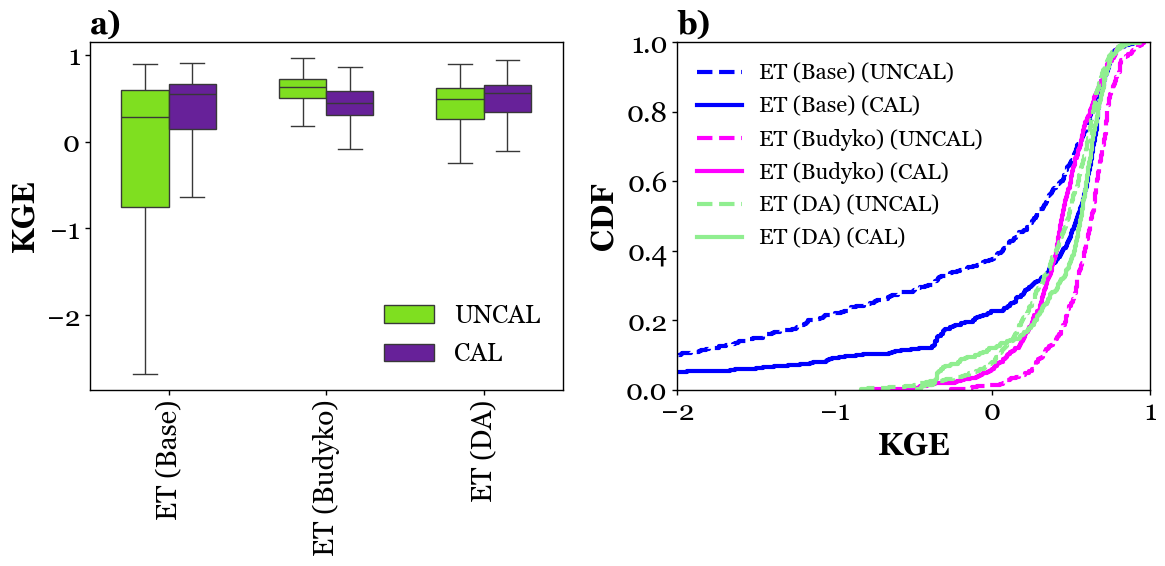

In [ ]:
# ============================================================
# ET Performance vs SFET
# CALIBRATED + UNCALIBRATED
# KGE boxplots + ECDF (single figure)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)

    m = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[m], sim[m]

    if len(obs) < 5:
        return np.nan

    r = np.corrcoef(obs, sim)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(sim) / np.std(obs) if np.std(obs) != 0 else np.nan
    beta  = np.mean(sim) / np.mean(obs) if np.mean(obs) != 0 else np.nan

    if not np.isfinite(alpha) or not np.isfinite(beta):
        return np.nan

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)


# ============================================================
# PATHS
# ============================================================
ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
DATA_DIR = os.path.join(ROOT, "data", "processed")

UNCAL_DIR = os.path.join(ROOT, "Simulation_results", "Simulation_with_UNCALIB_PARAMS")
CAL_DIR   = os.path.join(ROOT, "Simulation_results", "Simulation_with_CALIB_PARAMS")


# ============================================================
# 1) Load SFET (monthly)
# ============================================================
SFET = pd.read_feather(os.path.join(DATA_DIR, "SFET.feather"))
SFET["time"] = pd.to_datetime(SFET["time"])
SFET = SFET.set_index("time").sort_index()

SFET.columns = SFET.columns.astype(str).str.strip()
SFET = SFET.loc[:, ~SFET.columns.duplicated()]

SFET_m = SFET.resample("MS").sum()


# ============================================================
# Helper: load ET from scenario folder
# ============================================================
def load_ET(folder, scenario, et_col, is_da=False):
    if is_da:
        files = glob.glob(os.path.join(folder, "enkf_ensemble_BUDYKO_DA_*.feather"))
    else:
        files = glob.glob(os.path.join(folder, f"results_{scenario}_*.feather"))

    et = {}
    for f in files:
        bid = os.path.basename(f).split("_")[-1].replace(".feather", "")
        df = pd.read_feather(f)
        df["time"] = pd.to_datetime(df["time"])
        et[bid] = df.set_index("time")[et_col].astype(float)

    return pd.DataFrame(et).sort_index()


# ============================================================
# 2) Load ALL ET (CAL + UNCAL)
# ============================================================
def load_all(calib_label, BASE):
    ET_ke  = load_ET(os.path.join(BASE, "BASE_MODEL"), "BASE", "ET_ke")
    ET_B   = load_ET(os.path.join(BASE, "BUDYKO_MODEL"), "BUDYKO", "ET_B")
    ET_ass = load_ET(os.path.join(BASE, "BUDYKO_DA"), "BUDYKO_DA", "ET_ens_mean", is_da=True)

    return {
        "ET_ke":  ET_ke.resample("MS").sum(),
        "ET_B":   ET_B.resample("MS").sum(),
        "ET_ass": ET_ass.resample("MS").sum(),
        "calib":  calib_label
    }


UNCAL = load_all("UNCAL", UNCAL_DIR)
CAL   = load_all("CAL",   CAL_DIR)


# ============================================================
# 3) Compute KGE
# ============================================================
def compute_kge(SFET, data):
    rows = []
    for scen in ["ET_ke", "ET_B", "ET_ass"]:
        common_t = SFET.index.intersection(data[scen].index)
        common_b = SFET.columns.intersection(data[scen].columns)

        for b in common_b:
            rows.append({
                "gauge_id": b,
                "scenario": scen,
                "calibration": data["calib"],
                "KGE": kge_2012(
                    SFET.loc[common_t, b].values,
                    data[scen].loc[common_t, b].values
                )
            })
    return pd.DataFrame(rows)


df_uncal = compute_kge(SFET_m, UNCAL)
df_cal   = compute_kge(SFET_m, CAL)

perform = pd.concat([df_uncal, df_cal], ignore_index=True)


# ============================================================
# 4) Plot (single figure)
# ============================================================
label_map = {"ET_ke": "ET (Base)", "ET_B": "ET (Budyko)", "ET_ass": "ET (DA)"}
scenario_order = ["ET_ke", "ET_B", "ET_ass"]
palette = {"UNCAL": "#7FFF00", "CAL": "#6A0DAD"}

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# ---- BOXPLOT ----
sns.boxplot(
    data=perform,
    x="scenario",
    y="KGE",
    hue="calibration",
    order=scenario_order,
    palette=palette,
    showfliers=False,
    width=0.6,
    ax=axs[0]
)

axs[0].set_xticklabels([label_map[s] for s in scenario_order], fontsize=20, rotation=90)
axs[0].set_ylabel("KGE", fontsize=22)
axs[0].set_xlabel("")
axs[0].set_title("a)", loc="left", fontsize=22, fontweight="bold")
axs[0].legend(frameon=False, fontsize=18)
# axs[0].set_xticklabels(labels, rotation=45, ha="center", fontsize=20)


# ---- ECDF ----
color_map = {
    "ET_ke":  "blue",
    "ET_B":   "magenta",
    "ET_ass": "lightgreen",
}

linestyle_map = {
    "UNCAL": "--",
    "CAL":   "-",
}

for scen in scenario_order:
    for cal in ["UNCAL", "CAL"]:
        sub = perform[
            (perform.scenario == scen) &
            (perform.calibration == cal)
        ]

        sns.ecdfplot(
            sub["KGE"],
            ax=axs[1],
            lw=3,
            color=color_map[scen],
            linestyle=linestyle_map[cal],
            label=f"{label_map[scen]} ({cal})"
        )


axs[1].set_xlim(-2, 1)
axs[1].set_xlabel("KGE", fontsize=22)
axs[1].set_ylabel("CDF", fontsize=22)
axs[1].set_title("b)", loc="left", fontsize=22, fontweight="bold")
axs[1].legend(frameon=False, fontsize=16, ncol=1, loc='upper left')

for ax in axs:
    ax.tick_params(labelsize=20)

plt.tight_layout()
plt.savefig("KGE_ET_CAL_vs_UNCAL_vs_CALIB.png", dpi=300, bbox_inches="tight")
plt.show()


# Q comparison: UnCalibrated:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_36140\4175109408.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


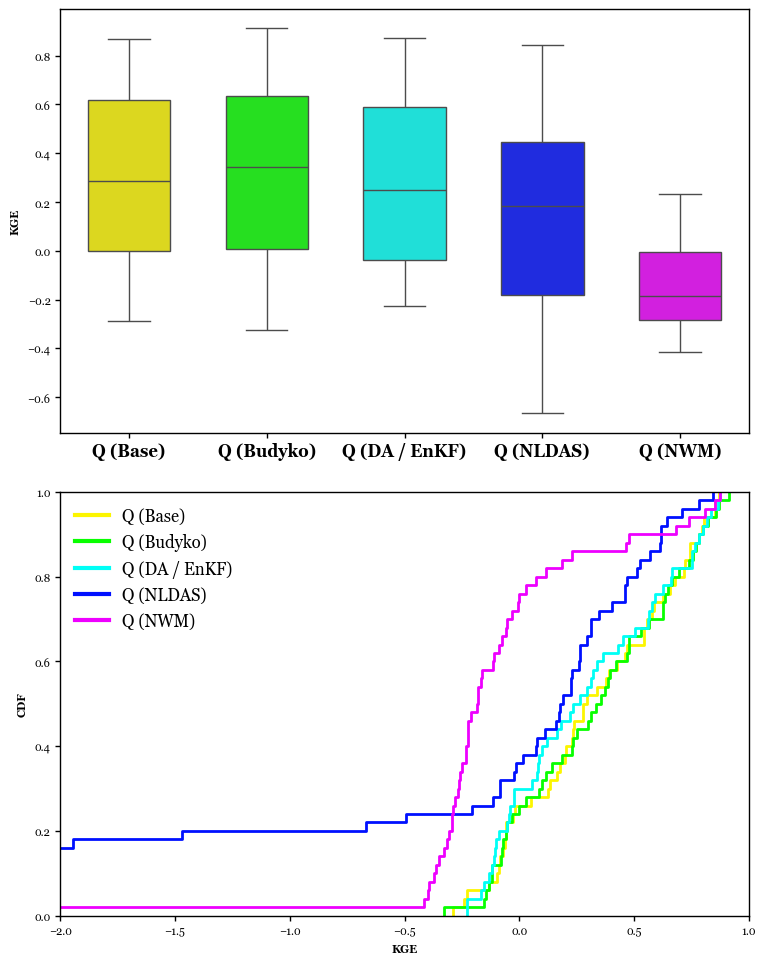

In [ ]:
# ============================================================
# Q Performance vs USGS (ROBUST: time can be column or index)
# 1) Compute KGE basin-by-basin
# 2) Boxplot + ECDF (same format as before)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(evaluation, simulation):
    e = np.asarray(evaluation, dtype=np.float64)
    s = np.asarray(simulation, dtype=np.float64)

    m = np.isfinite(e) & np.isfinite(s)
    e = e[m]
    s = s[m]

    if len(e) < 5:
        return np.nan

    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan
    beta  = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


# ============================================================
# ROBUST time handler
# ============================================================
def ensure_time_index(df, time_col="time"):
    """
    Ensure df has DatetimeIndex.
    Works for:
      - df has a 'time' column
      - df already has time as index
    """
    df = df.copy()

    # Case 1: time is a column
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.set_index(time_col)

    # Case 2: time is already index
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            try:
                df.index = pd.to_datetime(df.index)
            except Exception as e:
                raise ValueError(
                    "Could not convert index to datetime. "
                    "Your dataframe has no 'time' column and index is not datetime."
                ) from e

    return df.sort_index()


def monthly_sum(df):
    df = ensure_time_index(df)
    out = df.resample("MS").sum()
    out.index.name = "time"
    out.columns = out.columns.astype(str).str.strip()
    out = out.loc[:, ~out.columns.duplicated()].copy()
    return out


# ============================================================
# 1) Load Q_USGS (Observed)
# ============================================================
Q_USGS = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather")
Q_USGS_monthly = monthly_sum(Q_USGS)


# ============================================================
# 2) Load Q_nldas
# ============================================================
Q_nldas = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_nldas_mm_monthly.feather")
Q_nldas_monthly = monthly_sum(Q_nldas)


# ============================================================
# 3) Load Q_nwm
# ============================================================
NWM = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\NWM.feather")
Q_nwm_monthly = monthly_sum(NWM)


# ============================================================
# 4) Load Q_ke from BASE_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_UNCALIB_PARAMS\BASE_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
# print(f"Found {len(files)} BASE MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_base" not in df.columns:
        raise KeyError(f"Q_base not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_base"]

Q_base_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 5) Load Q_b from BUDYKO_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_UNCALIB_PARAMS\BUDYKO_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
# print(f"Found {len(files)} BUDYKO MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_budyko" not in df.columns:
        raise KeyError(f"Q_budyko not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_budyko"]

Q_b_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 6) Load Q_ass from BUDYKO_DA feather results  ✅ UPDATED
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_UNCALIB_PARAMS\BUDYKO_DA"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_DA_*.feather"))
# print(f"Found {len(files)} BUDYKO_DA feather files")

q_dict = {}

for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_DA_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_ens" not in df.columns:
        raise KeyError(f"Q_ens not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_ens"]

Q_ass_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 7) Align TIME + BASINS (all scenarios)
# ============================================================
dfs = {
    "Q_USGS": Q_USGS_monthly,
    "Q_base": Q_base_monthly,
    "Q_budyko": Q_b_monthly,
    "Q_ass": Q_ass_monthly,
    "Q_nldas": Q_nldas_monthly,
    "Q_nwm": Q_nwm_monthly,
}

# common time index
common_index = None
for name, df_ in dfs.items():
    common_index = df_.index if common_index is None else common_index.intersection(df_.index)

for name in dfs:
    dfs[name] = dfs[name].loc[common_index].copy()

# common columns
common_cols = None
for name, df_ in dfs.items():
    common_cols = df_.columns if common_cols is None else common_cols.intersection(df_.columns)

for name in dfs:
    dfs[name] = dfs[name].loc[:, common_cols].copy()

# print("\nFinal aligned shapes:")
# for name, df_ in dfs.items():
#     print(f"{name}: {df_.shape}")


# ============================================================
# 8) Compute KGE against USGS
# ============================================================
rows = []
obs_df = dfs["Q_USGS"]

for g in common_cols:
    obs = obs_df[g].values

    for scenario in ["Q_base","Q_budyko", "Q_ass", "Q_nldas", "Q_nwm"]:
        sim = dfs[scenario][g].values
        rows.append({
            "gauge_id": g,
            "scenario": scenario,
            "KGE": kge_2012(obs, sim)
        })

perform = pd.DataFrame(rows).set_index("gauge_id")
# print("\nPerformance head:")
# print(perform.head())


# ============================================================
# 9) Boxplot + ECDF (same format)
# ============================================================
label_map = {
    "Q_base": "Q (Base)",
    "Q_budyko": "Q (Budyko)",
    "Q_ass": "Q (DA / EnKF)",
    "Q_nldas": "Q (NLDAS)",
    "Q_nwm": "Q (NWM)"
}

unique_scenarios = perform["scenario"].unique()
palette_list = sns.color_palette("hsv", len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# --- Boxplot ---
sns.boxplot(
    x="scenario",
    y="KGE",
    data=perform,
    order=unique_scenarios,
    palette=palette_list,
    ax=axs[0],
    showfliers=False,
    width=0.6
)
axs[0].set(xlabel="", ylabel="KGE")
axs[0].set_xticks(range(len(unique_scenarios)))
axs[0].set_xticklabels(labels, rotation=0, ha="center", fontweight='bold', fontsize=12)


# --- ECDF ---
for s, color, lab in zip(unique_scenarios, palette_list, labels):
    subset = perform[perform["scenario"] == s]
    sns.ecdfplot(
        subset,
        x="KGE",
        color=color,
        label=lab,
        lw=2,
        ax=axs[1]
    )

axs[1].set(xlabel="KGE", ylabel="CDF", xlim=(-2, 1))
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in palette_list]
axs[1].legend(handles, labels, frameon=False, fontsize=12, ncol=1)

plt.tight_layout()
plt.show()


# Q comparison: Calibrated:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_36140\1280760087.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


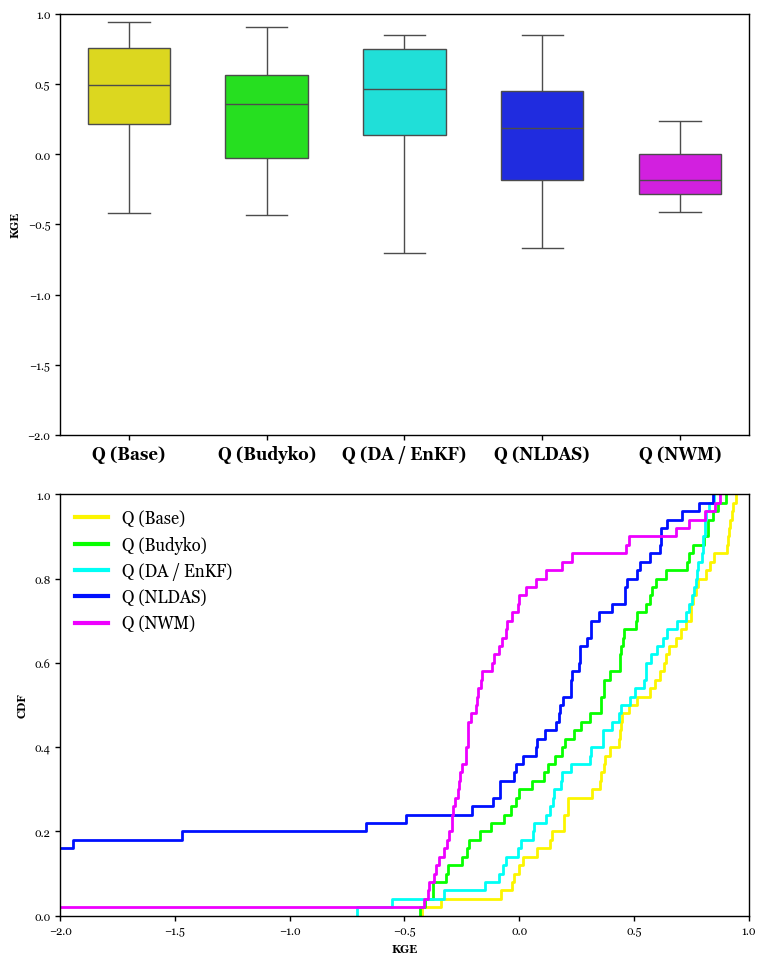

In [ ]:
# ============================================================
# Q Performance vs USGS (ROBUST: time can be column or index)
# 1) Compute KGE basin-by-basin
# 2) Boxplot + ECDF (same format as before)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(evaluation, simulation):
    e = np.asarray(evaluation, dtype=np.float64)
    s = np.asarray(simulation, dtype=np.float64)

    m = np.isfinite(e) & np.isfinite(s)
    e = e[m]
    s = s[m]

    if len(e) < 5:
        return np.nan

    r = np.corrcoef(e, s)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(s) / np.std(e) if np.std(e) != 0 else np.nan
    beta  = np.mean(s) / np.mean(e) if np.mean(e) != 0 else np.nan

    if not (np.isfinite(alpha) and np.isfinite(beta)):
        return np.nan

    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


# ============================================================
# ROBUST time handler
# ============================================================
def ensure_time_index(df, time_col="time"):
    """
    Ensure df has DatetimeIndex.
    Works for:
      - df has a 'time' column
      - df already has time as index
    """
    df = df.copy()

    # Case 1: time is a column
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.set_index(time_col)

    # Case 2: time is already index
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            try:
                df.index = pd.to_datetime(df.index)
            except Exception as e:
                raise ValueError(
                    "Could not convert index to datetime. "
                    "Your dataframe has no 'time' column and index is not datetime."
                ) from e

    return df.sort_index()


def monthly_sum(df):
    df = ensure_time_index(df)
    out = df.resample("MS").sum()
    out.index.name = "time"
    out.columns = out.columns.astype(str).str.strip()
    out = out.loc[:, ~out.columns.duplicated()].copy()
    return out


# ============================================================
# 1) Load Q_USGS (Observed)
# ============================================================
Q_USGS = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather")
Q_USGS_monthly = monthly_sum(Q_USGS)


# ============================================================
# 2) Load Q_nldas
# ============================================================
Q_nldas = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_nldas_mm_monthly.feather")
Q_nldas_monthly = monthly_sum(Q_nldas)


# ============================================================
# 3) Load Q_nwm
# ============================================================
NWM = pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\NWM.feather")
Q_nwm_monthly = monthly_sum(NWM)


# ============================================================
# 4) Load Q_ke from BASE_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BASE_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BASE_*.feather"))
# print(f"Found {len(files)} BASE MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BASE_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_base" not in df.columns:
        raise KeyError(f"Q_base not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_base"]

Q_base_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 5) Load Q_b from BUDYKO_MODEL results
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_MODEL"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_*.feather"))
# print(f"Found {len(files)} BUDYKO MODEL feather files")

q_dict = {}
for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_budyko" not in df.columns:
        raise KeyError(f"Q_budyko not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_budyko"]

Q_b_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 6) Load Q_ass from BUDYKO_DA feather results  ✅ UPDATED
# ============================================================
BASE_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_DA"
files = glob.glob(os.path.join(BASE_DIR, "results_BUDYKO_DA_*.feather"))
# print(f"Found {len(files)} BUDYKO_DA feather files")

q_dict = {}

for f in files:
    fname = os.path.basename(f)
    gauge_id = fname.replace("results_BUDYKO_DA_", "").replace(".feather", "").strip()

    df = pd.read_feather(f)
    df = ensure_time_index(df)

    if "Q_ens" not in df.columns:
        raise KeyError(f"Q_ens not found in {fname}. Available columns: {df.columns.tolist()}")

    q_dict[gauge_id] = df["Q_ens"]

Q_ass_monthly = monthly_sum(pd.DataFrame(q_dict))


# ============================================================
# 7) Align TIME + BASINS (all scenarios)
# ============================================================
dfs = {
    "Q_USGS": Q_USGS_monthly,
    "Q_base": Q_base_monthly,
    "Q_budyko": Q_b_monthly,
    "Q_ass": Q_ass_monthly,
    "Q_nldas": Q_nldas_monthly,
    "Q_nwm": Q_nwm_monthly,
}

# common time index
common_index = None
for name, df_ in dfs.items():
    common_index = df_.index if common_index is None else common_index.intersection(df_.index)

for name in dfs:
    dfs[name] = dfs[name].loc[common_index].copy()

# common columns
common_cols = None
for name, df_ in dfs.items():
    common_cols = df_.columns if common_cols is None else common_cols.intersection(df_.columns)

for name in dfs:
    dfs[name] = dfs[name].loc[:, common_cols].copy()

# print("\nFinal aligned shapes:")
# for name, df_ in dfs.items():
#     print(f"{name}: {df_.shape}")


# ============================================================
# 8) Compute KGE against USGS
# ============================================================
rows = []
obs_df = dfs["Q_USGS"]

for g in common_cols:
    obs = obs_df[g].values

    for scenario in ["Q_base","Q_budyko", "Q_ass", "Q_nldas", "Q_nwm"]:
        sim = dfs[scenario][g].values
        rows.append({
            "gauge_id": g,
            "scenario": scenario,
            "KGE": kge_2012(obs, sim)
        })

perform = pd.DataFrame(rows).set_index("gauge_id")
# print("\nPerformance head:")
# print(perform.head())


# ============================================================
# 9) Boxplot + ECDF (same format)
# ============================================================
label_map = {
    "Q_base": "Q (Base)",
    "Q_budyko": "Q (Budyko)",
    "Q_ass": "Q (DA / EnKF)",
    "Q_nldas": "Q (NLDAS)",
    "Q_nwm": "Q (NWM)"
}

unique_scenarios = perform["scenario"].unique()
palette_list = sns.color_palette("hsv", len(unique_scenarios))
labels = [label_map.get(s, s) for s in unique_scenarios]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# --- Boxplot ---
sns.boxplot(
    x="scenario",
    y="KGE",
    data=perform,
    order=unique_scenarios,
    palette=palette_list,
    ax=axs[0],
    showfliers=False,
    width=0.6
)
axs[0].set(xlabel="", ylabel="KGE", ylim=(-2, 1))
axs[0].set_xticks(range(len(unique_scenarios)))
axs[0].set_xticklabels(labels, rotation=0, ha="center", fontweight='bold', fontsize=12)


# --- ECDF ---
for s, color, lab in zip(unique_scenarios, palette_list, labels):
    subset = perform[perform["scenario"] == s]
    sns.ecdfplot(
        subset,
        x="KGE",
        color=color,
        label=lab,
        lw=2,
        ax=axs[1]
    )

axs[1].set(xlabel="KGE", ylabel="CDF", xlim=(-2, 1))
handles = [plt.Line2D([0], [0], color=c, lw=3) for c in palette_list]
axs[1].legend(handles, labels, frameon=False, fontsize=12, ncol=1)

plt.tight_layout()
plt.show()


# CALIB vs UNCALIb: All Q

c:\Users\hdagne1\AppData\Local\anaconda3\envs\BUDYKO-dev\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hdagne1\AppData\Local\anaconda3\envs\BUDYKO-dev\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_36140\4135893805.py:466: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([label_map[s] for s in scenario_order],


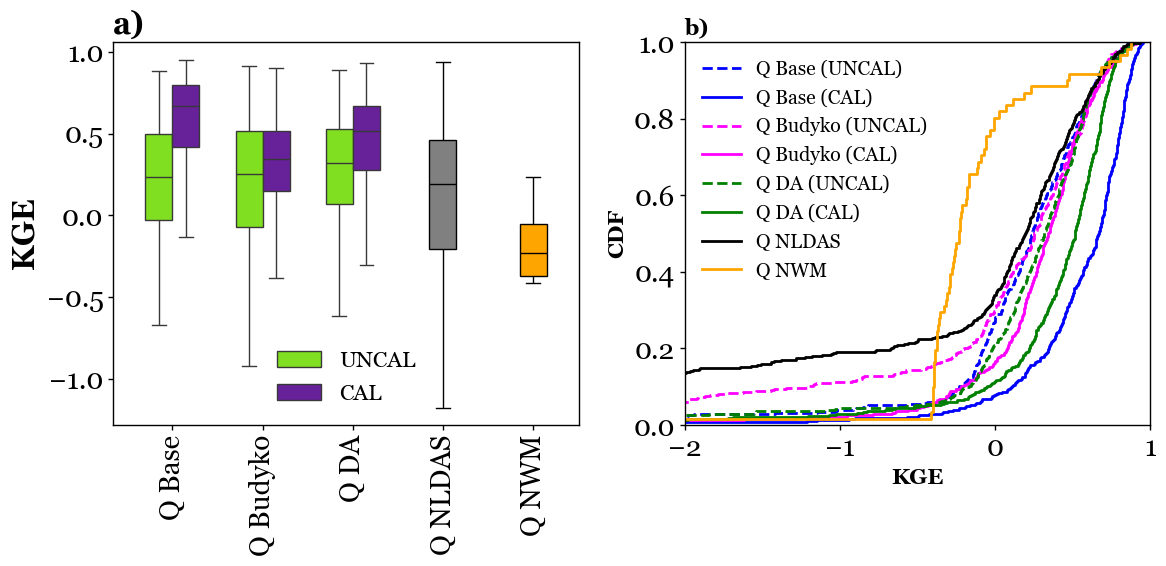

In [ ]:
# # ============================================================
# # Q Performance vs USGS
# # CALIBRATED + UNCALIBRATED
# # KGE boxplots + ECDF (single figure)
# # ============================================================

# import os
# import glob
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns


# # ============================================================
# # KGE (2012)
# # ============================================================
# def kge_2012(obs, sim):
#     obs = np.asarray(obs, dtype=float)
#     sim = np.asarray(sim, dtype=float)

#     m = np.isfinite(obs) & np.isfinite(sim)
#     obs, sim = obs[m], sim[m]

#     if len(obs) < 5:
#         return np.nan

#     r = np.corrcoef(obs, sim)[0, 1]
#     if not np.isfinite(r):
#         return np.nan

#     alpha = np.std(sim) / np.std(obs) if np.std(obs) != 0 else np.nan
#     beta  = np.mean(sim) / np.mean(obs) if np.mean(obs) != 0 else np.nan

#     if not np.isfinite(alpha) or not np.isfinite(beta):
#         return np.nan

#     return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)


# # ============================================================
# # PATHS
# # ============================================================
# ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
# DATA_DIR = os.path.join(ROOT, "data", "processed")

# UNCAL_DIR = os.path.join(ROOT, "Simulation_results", "Simulation_with_UNCALIB_PARAMS")
# CAL_DIR   = os.path.join(ROOT, "Simulation_results", "Simulation_with_CALIB_PARAMS")


# # ============================================================
# # Robust time utilities
# # ============================================================
# def ensure_time_index(df, time_col="time"):
#     df = df.copy()
#     if time_col in df.columns:
#         df[time_col] = pd.to_datetime(df[time_col])
#         df = df.set_index(time_col)
#     else:
#         df.index = pd.to_datetime(df.index)
#     return df.sort_index()


# def monthly_sum(df):
#     df = ensure_time_index(df)
#     out = df.resample("MS").sum()
#     out.index.name = "time"
#     out.columns = out.columns.astype(str).str.strip()
#     out = out.loc[:, ~out.columns.duplicated()]
#     return out


# # ============================================================
# # 1) Load observed USGS
# # ============================================================
# Q_USGS = pd.read_feather(os.path.join(DATA_DIR, "Q_USGS.feather"))
# Q_USGS_m = monthly_sum(Q_USGS)


# # ============================================================
# # Helper: load model Q from scenario
# # ============================================================
# def load_Q(folder, pattern, col):
#     files = glob.glob(os.path.join(folder, pattern))
#     q = {}
#     for f in files:
#         bid = os.path.basename(f).split("_")[-1].replace(".feather", "")
#         df = ensure_time_index(pd.read_feather(f))
#         q[bid] = df[col]
#     return monthly_sum(pd.DataFrame(q))


# def load_all(calib_label, BASE):
#     return {
#         "Q_base":   load_Q(os.path.join(BASE, "BASE_MODEL"),   "results_BASE_*.feather",   "Q_base"),
#         "Q_budyko":load_Q(os.path.join(BASE, "BUDYKO_MODEL"), "results_BUDYKO_*.feather", "Q_budyko"),
#         "Q_ass":   load_Q(os.path.join(BASE, "BUDYKO_DA"),    "results_BUDYKO_DA_*.feather", "Q_ens"),
#         "calib":   calib_label
#     }


# UNCAL = load_all("UNCAL", UNCAL_DIR)
# CAL   = load_all("CAL",   CAL_DIR)


# # ============================================================
# # 2) Compute KGE
# # ============================================================
# def compute_kge(Qobs, data):
#     rows = []
#     for scen in ["Q_base", "Q_budyko", "Q_ass"]:
#         common_t = Qobs.index.intersection(data[scen].index)
#         common_b = Qobs.columns.intersection(data[scen].columns)

#         for b in common_b:
#             rows.append({
#                 "gauge_id": b,
#                 "scenario": scen,
#                 "calibration": data["calib"],
#                 "KGE": kge_2012(
#                     Qobs.loc[common_t, b].values,
#                     data[scen].loc[common_t, b].values
#                 )
#             })
#     return pd.DataFrame(rows)


# df_uncal = compute_kge(Q_USGS_m, UNCAL)
# df_cal   = compute_kge(Q_USGS_m, CAL)

# perform = pd.concat([df_uncal, df_cal], ignore_index=True)


# # ============================================================
# # 3) Plot (SAME STYLE AS ET FIGURE)
# # ============================================================
# label_map = {
#     "Q_base":   "Q Base",
#     "Q_budyko":"Q Budyko",
#     "Q_ass":   "Q DA"
# }

# scenario_order = ["Q_base", "Q_budyko", "Q_ass"]

# # EXACT same logic as ET
# palette = {
#     "UNCAL": "#7FFF00",
#     "CAL":   "#6A0DAD"
# }

# fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# # ---- BOXPLOT (MATCHES ET CODE) ----
# sns.boxplot(
#     data=perform,
#     x="scenario",
#     y="KGE",
#     hue="calibration",
#     order=scenario_order,
#     palette=palette,
#     showfliers=False,
#     width=0.6,
#     ax=axs[0]
# )

# axs[0].set_xticklabels([label_map[s] for s in scenario_order], fontsize=20, rotation=0)
# axs[0].set_ylabel("KGE", fontsize=22)
# axs[0].set_xlabel("")
# axs[0].set_title("a)", loc="left", fontsize=22, fontweight="bold")
# axs[0].legend(frameon=0, fontsize=18, loc="lower right")
# # axs[0].set_xticklabels(labels, rotation=45, ha="center", fontsize=20)

# # ---- ECDF (same rules as ET) ----
# color_map = {
#     "Q_base":   "blue",
#     "Q_budyko":"magenta",
#     "Q_ass":   "green",
# }

# linestyle_map = {
#     "UNCAL": "--",
#     "CAL":   "-",
# }

# for scen in scenario_order:
#     for cal in ["UNCAL", "CAL"]:
#         sub = perform[
#             (perform.scenario == scen) &
#             (perform.calibration == cal)
#         ]

#         sns.ecdfplot(
#             sub["KGE"],
#             ax=axs[1],
#             lw=2,
#             color=color_map[scen],
#             linestyle=linestyle_map[cal],
#             label=f"{label_map[scen]} ({cal})"
#         )


# axs[1].set_xlim(-2, 1)
# axs[1].set_xlabel("KGE", fontsize=16)
# axs[1].set_ylabel("CDF", fontsize=16)
# axs[1].set_title("b)", loc="left", fontsize=16, fontweight="bold")
# axs[1].legend(frameon=False, fontsize=16, loc="upper left")

# for ax in axs:
#     ax.tick_params(labelsize=20)

# plt.tight_layout()
# plt.savefig("KGE_Q_CAL_vs_UNCAL.png", dpi=300, bbox_inches="tight")
# plt.show()
# # plt.savefig('All_Q_Cal_UNCAL.png', dpi=600, facecolor='white')

# ============================================================
# Q Performance vs USGS
# CALIBRATED + UNCALIBRATED (models)
# NLDAS & NWM (single, different colors, NO legend)
# KGE boxplots + ECDF
# ============================================================



# ============================================================
# Q Performance vs USGS
# CALIBRATED + UNCALIBRATED (models)
# NLDAS & NWM (single reference)
# KGE boxplots + ECDF
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# KGE (2012)
# ============================================================
def kge_2012(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)

    m = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[m], sim[m]

    if len(obs) < 5:
        return np.nan

    r = np.corrcoef(obs, sim)[0, 1]
    if not np.isfinite(r):
        return np.nan

    alpha = np.std(sim) / np.std(obs) if np.std(obs) != 0 else np.nan
    beta  = np.mean(sim) / np.mean(obs) if np.mean(obs) != 0 else np.nan

    if not np.isfinite(alpha) or not np.isfinite(beta):
        return np.nan

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)


# ============================================================
# PATHS
# ============================================================
ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"
DATA_DIR = os.path.join(ROOT, "data", "processed")

UNCAL_DIR = os.path.join(ROOT, "Simulation_results", "Simulation_with_UNCALIB_PARAMS")
CAL_DIR   = os.path.join(ROOT, "Simulation_results", "Simulation_with_CALIB_PARAMS")


# ============================================================
# Time utilities
# ============================================================
def ensure_time_index(df, time_col="time"):
    df = df.copy()
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.set_index(time_col)
    else:
        df.index = pd.to_datetime(df.index)
    return df.sort_index()


def monthly_sum(df):
    df = ensure_time_index(df)
    out = df.resample("MS").sum()
    out.index.name = "time"
    out.columns = out.columns.astype(str).str.strip()
    out = out.loc[:, ~out.columns.duplicated()]
    return out


# ============================================================
# 1) Observed USGS
# ============================================================
Q_USGS = monthly_sum(
    pd.read_feather(os.path.join(DATA_DIR, "Q_USGS.feather"))
)


# ============================================================
# 2) Reference products (single)
# ============================================================
Q_NLDAS = monthly_sum(
    pd.read_feather(os.path.join(DATA_DIR, "Q_nldas_mm_monthly.feather"))
)

Q_NWM = monthly_sum(
    pd.read_feather(os.path.join(DATA_DIR, "NWM.feather"))
)


# ============================================================
# Helper: load model Q
# ============================================================
def load_Q(folder, pattern, col):
    files = glob.glob(os.path.join(folder, pattern))
    q = {}
    for f in files:
        bid = os.path.basename(f).split("_")[-1].replace(".feather", "")
        df = ensure_time_index(pd.read_feather(f))
        q[bid] = df[col]
    return monthly_sum(pd.DataFrame(q))


def load_all(label, BASE):
    return {
        "Q_base":   load_Q(os.path.join(BASE, "BASE_MODEL"),
                           "results_BASE_*.feather", "Q_base"),
        "Q_budyko":load_Q(os.path.join(BASE, "BUDYKO_MODEL"),
                           "results_BUDYKO_*.feather", "Q_budyko"),
        "Q_ass":   load_Q(os.path.join(BASE, "BUDYKO_DA"),
                           "results_BUDYKO_DA_*.feather", "Q_ens"),
        "calib": label
    }


UNCAL = load_all("UNCAL", UNCAL_DIR)
CAL   = load_all("CAL",   CAL_DIR)


# ============================================================
# 3) Compute KGE
# ============================================================
def compute_kge_models(Qobs, data):
    rows = []
    for scen in ["Q_base", "Q_budyko", "Q_ass"]:
        ct = Qobs.index.intersection(data[scen].index)
        cb = Qobs.columns.intersection(data[scen].columns)

        for b in cb:
            rows.append({
                "gauge_id": b,
                "scenario": scen,
                "calibration": data["calib"],
                "KGE": kge_2012(
                    Qobs.loc[ct, b].values,
                    data[scen].loc[ct, b].values
                )
            })
    return pd.DataFrame(rows)


def compute_kge_single(Qobs, Qsim, label):
    rows = []
    ct = Qobs.index.intersection(Qsim.index)
    cb = Qobs.columns.intersection(Qsim.columns)

    for b in cb:
        rows.append({
            "gauge_id": b,
            "scenario": label,
            "calibration": "REF",
            "KGE": kge_2012(
                Qobs.loc[ct, b].values,
                Qsim.loc[ct, b].values
            )
        })
    return pd.DataFrame(rows)


perform = pd.concat([
    compute_kge_models(Q_USGS, UNCAL),
    compute_kge_models(Q_USGS, CAL),
    compute_kge_single(Q_USGS, Q_NLDAS, "NLDAS"),
    compute_kge_single(Q_USGS, Q_NWM,   "NWM")
], ignore_index=True)


# ============================================================
# 4) Plot
# ============================================================
label_map = {
    "Q_base":   "Q Base",
    "Q_budyko":"Q Budyko",
    "Q_ass":   "Q DA",
    "NLDAS":   "Q NLDAS",
    "NWM":     "Q NWM"
}

scenario_order = ["Q_base", "Q_budyko", "Q_ass", "NLDAS", "NWM"]

palette = {
    "UNCAL": "#7FFF00",
    "CAL":   "#6A0DAD"
}

color_map = {
    "Q_base":   "blue",
    "Q_budyko":"magenta",
    "Q_ass":   "green",
    "NLDAS":   "black",
    "NWM":     "orange"
}

linestyle_map = {
    "UNCAL": "--",
    "CAL":   "-"
}

fig, axs = plt.subplots(1, 2, figsize=(12, 6))


# ---- BOXPLOT ----
model_data = perform[perform.calibration.isin(["UNCAL", "CAL"])]

sns.boxplot(
    data=model_data,
    x="scenario",
    y="KGE",
    hue="calibration",
    hue_order=["UNCAL", "CAL"],
    order=scenario_order,
    palette=palette,
    showfliers=False,
    width=0.6,
    dodge=True,
    ax=axs[0]
)

ref_data = perform[perform.scenario.isin(["NLDAS", "NWM"])]

for scen, col in [("NLDAS", "gray"), ("NWM", "orange")]:
    sns.boxplot(
        data=ref_data[ref_data.scenario == scen],
        x="scenario",
        y="KGE",
        order=scenario_order,
        showfliers=False,
        width=0.3,
        dodge=False,
        ax=axs[0],
        boxprops=dict(facecolor=col, edgecolor="black"),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black")
    )
axs[0].set_xlabel("")   # remove "scenario" under boxplots
axs[1].set_xlabel("KGE")  # keep KGE label for CDF (already correct)

axs[0].set_xticklabels([label_map[s] for s in scenario_order],
                        fontsize=20, rotation=90)
axs[0].set_ylabel("KGE", fontsize=22)
axs[0].set_title("a)", loc="left", fontsize=22, fontweight="bold")
axs[0].margins(x=0.08)

handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles[:2], labels[:2], frameon=False, fontsize=16,
              loc="lower center")


# ---- ECDF ----

# Models: CAL vs UNCAL
for scen in ["Q_base", "Q_budyko", "Q_ass"]:
    for cal in ["UNCAL", "CAL"]:
        sub = perform[
            (perform.scenario == scen) &
            (perform.calibration == cal)
        ]
        if sub.empty:
            continue

        sns.ecdfplot(
            sub["KGE"],
            ax=axs[1],
            lw=2,
            color=color_map[scen],
            linestyle=linestyle_map[cal],
            label=f"{label_map[scen]} ({cal})"
        )

# Reference products: single
for scen in ["NLDAS", "NWM"]:
    sub = perform[perform.scenario == scen]
    sns.ecdfplot(
        sub["KGE"],
        ax=axs[1],
        lw=2,
        color=color_map[scen],
        linestyle="-",
        label=label_map[scen]
    )

axs[1].set_xlim(-2, 1)
axs[1].set_xlabel("KGE", fontsize=16)
axs[1].set_ylabel("CDF", fontsize=16)
axs[1].set_title("b)", loc="left", fontsize=16, fontweight="bold")
axs[1].legend(frameon=False, fontsize=14, loc="upper left")

for ax in axs:
    ax.tick_params(labelsize=20)

plt.tight_layout()

plt.savefig('KGE_Q_CAL_vs_UNCAL.png', dpi=600, facecolor='white')
plt.show()



# Calibrated Parameters:

In [ ]:
# ============================================================
# Load required libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ============================================================
# Global Font Settings — Times New Roman everywhere
# ============================================================
LABEL_FONTSIZE = 14

font_path_regular = "C:/Windows/Fonts/times.ttf"
font_path_bold    = "C:/Windows/Fonts/timesbd.ttf"

font_manager.fontManager.addfont(font_path_regular)
font_manager.fontManager.addfont(font_path_bold)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": LABEL_FONTSIZE,
})

# ============================================================
# 0. Load Data
# ============================================================
param_file_path = (
    "F:/Github_repos/Bayesian_DA_Budyko_modeling/"
    "SCE_cal_params/final_calibrated_params_with_KGE.csv"
)

df = pd.read_csv(param_file_path, index_col="Basin")

# ============================================================
# Colors (coolwarm-like)
# ============================================================
coolwarm_colors = {
    "Kperc": "#3B4CC0",
    "Kb":    "#7FB6D9",
    "Ke":    "#F6A385",
    "Cqq":   "#B40426",
}

# ============================================================
# Prepare long data
# ============================================================
params_to_plot = ["Kperc", "Kb", "Ke", "Cqq"]

df_long = (
    df[params_to_plot]
    .reset_index(drop=True)
    .melt(var_name="Parameter", value_name="Value")
)

df_long["Parameter"] = pd.Categorical(
    df_long["Parameter"],
    categories=params_to_plot,
    ordered=True
)

# ============================================================
# Compute statistics for label placement
# ============================================================
df_stats = (
    df_long
    .groupby("Parameter")["Value"]
    .median()
    .reset_index()
)

# y positions (slightly above boxes)
y_positions = np.arange(len(params_to_plot)) + 0.47

# ============================================================
# Plot — Median values ABOVE boxplots
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

box_data = [
    df_long[df_long["Parameter"] == p]["Value"].dropna().values
    for p in params_to_plot
]

bp = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    widths=0.6,
    showfliers=False
)

# Apply colors
for patch, p in zip(bp["boxes"], params_to_plot):
    patch.set_facecolor(coolwarm_colors[p])
    patch.set_edgecolor("black")

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.5)

# Median labels above boxes
for i, (param, median) in enumerate(zip(df_stats["Parameter"], df_stats["Value"])):
    ax.text(
        median,
        y_positions[i],
        f"{median:.2f}",
        ha="center",
        va="bottom",
        fontsize=LABEL_FONTSIZE + 5,
        fontweight="bold",
        color="blue"
    )

# Axis labels
ax.set_yticks(np.arange(1, len(params_to_plot) + 1))
ax.set_yticklabels(params_to_plot)

ax.set_xlabel("Calibrated Values [505 CAMELS basins]",
              fontsize=LABEL_FONTSIZE + 10,
              fontweight="bold")
# ax.set_ylabel("Parameters",
#               fontsize=LABEL_FONTSIZE + 10,
#               fontweight="bold")

# Tick styling
ax.tick_params(axis="both", labelsize=LABEL_FONTSIZE + 15)

# Remove legend
ax.legend([], [], frameon=False)
# ax.set_xlim(0, 5)


ax.set_title('b)', loc='left', fontsize=LABEL_FONTSIZE + 15)
# ============================================================
# Save
# ============================================================
plt.savefig(
    "boxplot_median_above_boxes2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [ ]:
final_calibrated_params_with_KGE = pd.read_csv(r'F:\Github_repos\Bayesian_DA_Budyko_modeling\SCE_cal_params\final_calibrated_params_with_KGE.csv').set_index('Basin')

# plot 1:
plt.rcParams['font.family'] = 'Georgia'

df = final_calibrated_params_with_KGE.copy()

KGE_bins = [-1, 0.5, 0.7, 0.85, 1]
KGE_labels = ['<0.5', '0.5–0.7', '0.7–0.85', '>0.85']
df['KGE_class'] = pd.cut(df['KGE'], bins=KGE_bins, labels=KGE_labels)

params = ['Kperc', 'Kb', 'Ke', 'Cqq']
df_melted = df.melt(id_vars='KGE_class', value_vars=params,
                    var_name='Parameter', value_name='Value')


# plt.figure(figsize=(10,4))
# sns.violinplot(x='KGE_class', y='Value', hue='Parameter',
#                data=df_melted, palette='gist_ncar', split=False, inner='box')
# plt.xlabel('KGE', fontsize=16)
# plt.ylabel('Param Values', fontsize=16)
# plt.legend(loc='upper left', ncol=4, frameon=True)
# plt.tight_layout()
# plt.show()

# plot 2:

params = ['Kperc','Kb','Ke','Cqq']
df = final_calibrated_params_with_KGE.copy()
df['KGE_class'] = pd.cut(df['KGE'], bins=[-1,0.6,0.75,1], labels=['Poor','Good','Excellent'])

plt.figure(figsize=(6,4))
sns.violinplot(data=df[params], orient='h', palette='gist_ncar', inner='box')
plt.ylabel('Parameters', fontsize=16)
plt.xlabel('Calibrated Values', fontsize=16)
plt.tight_layout()
plt.show()
final_calibrated_params_with_KGE.describe()

# ET Scenarios under Budyko curves:

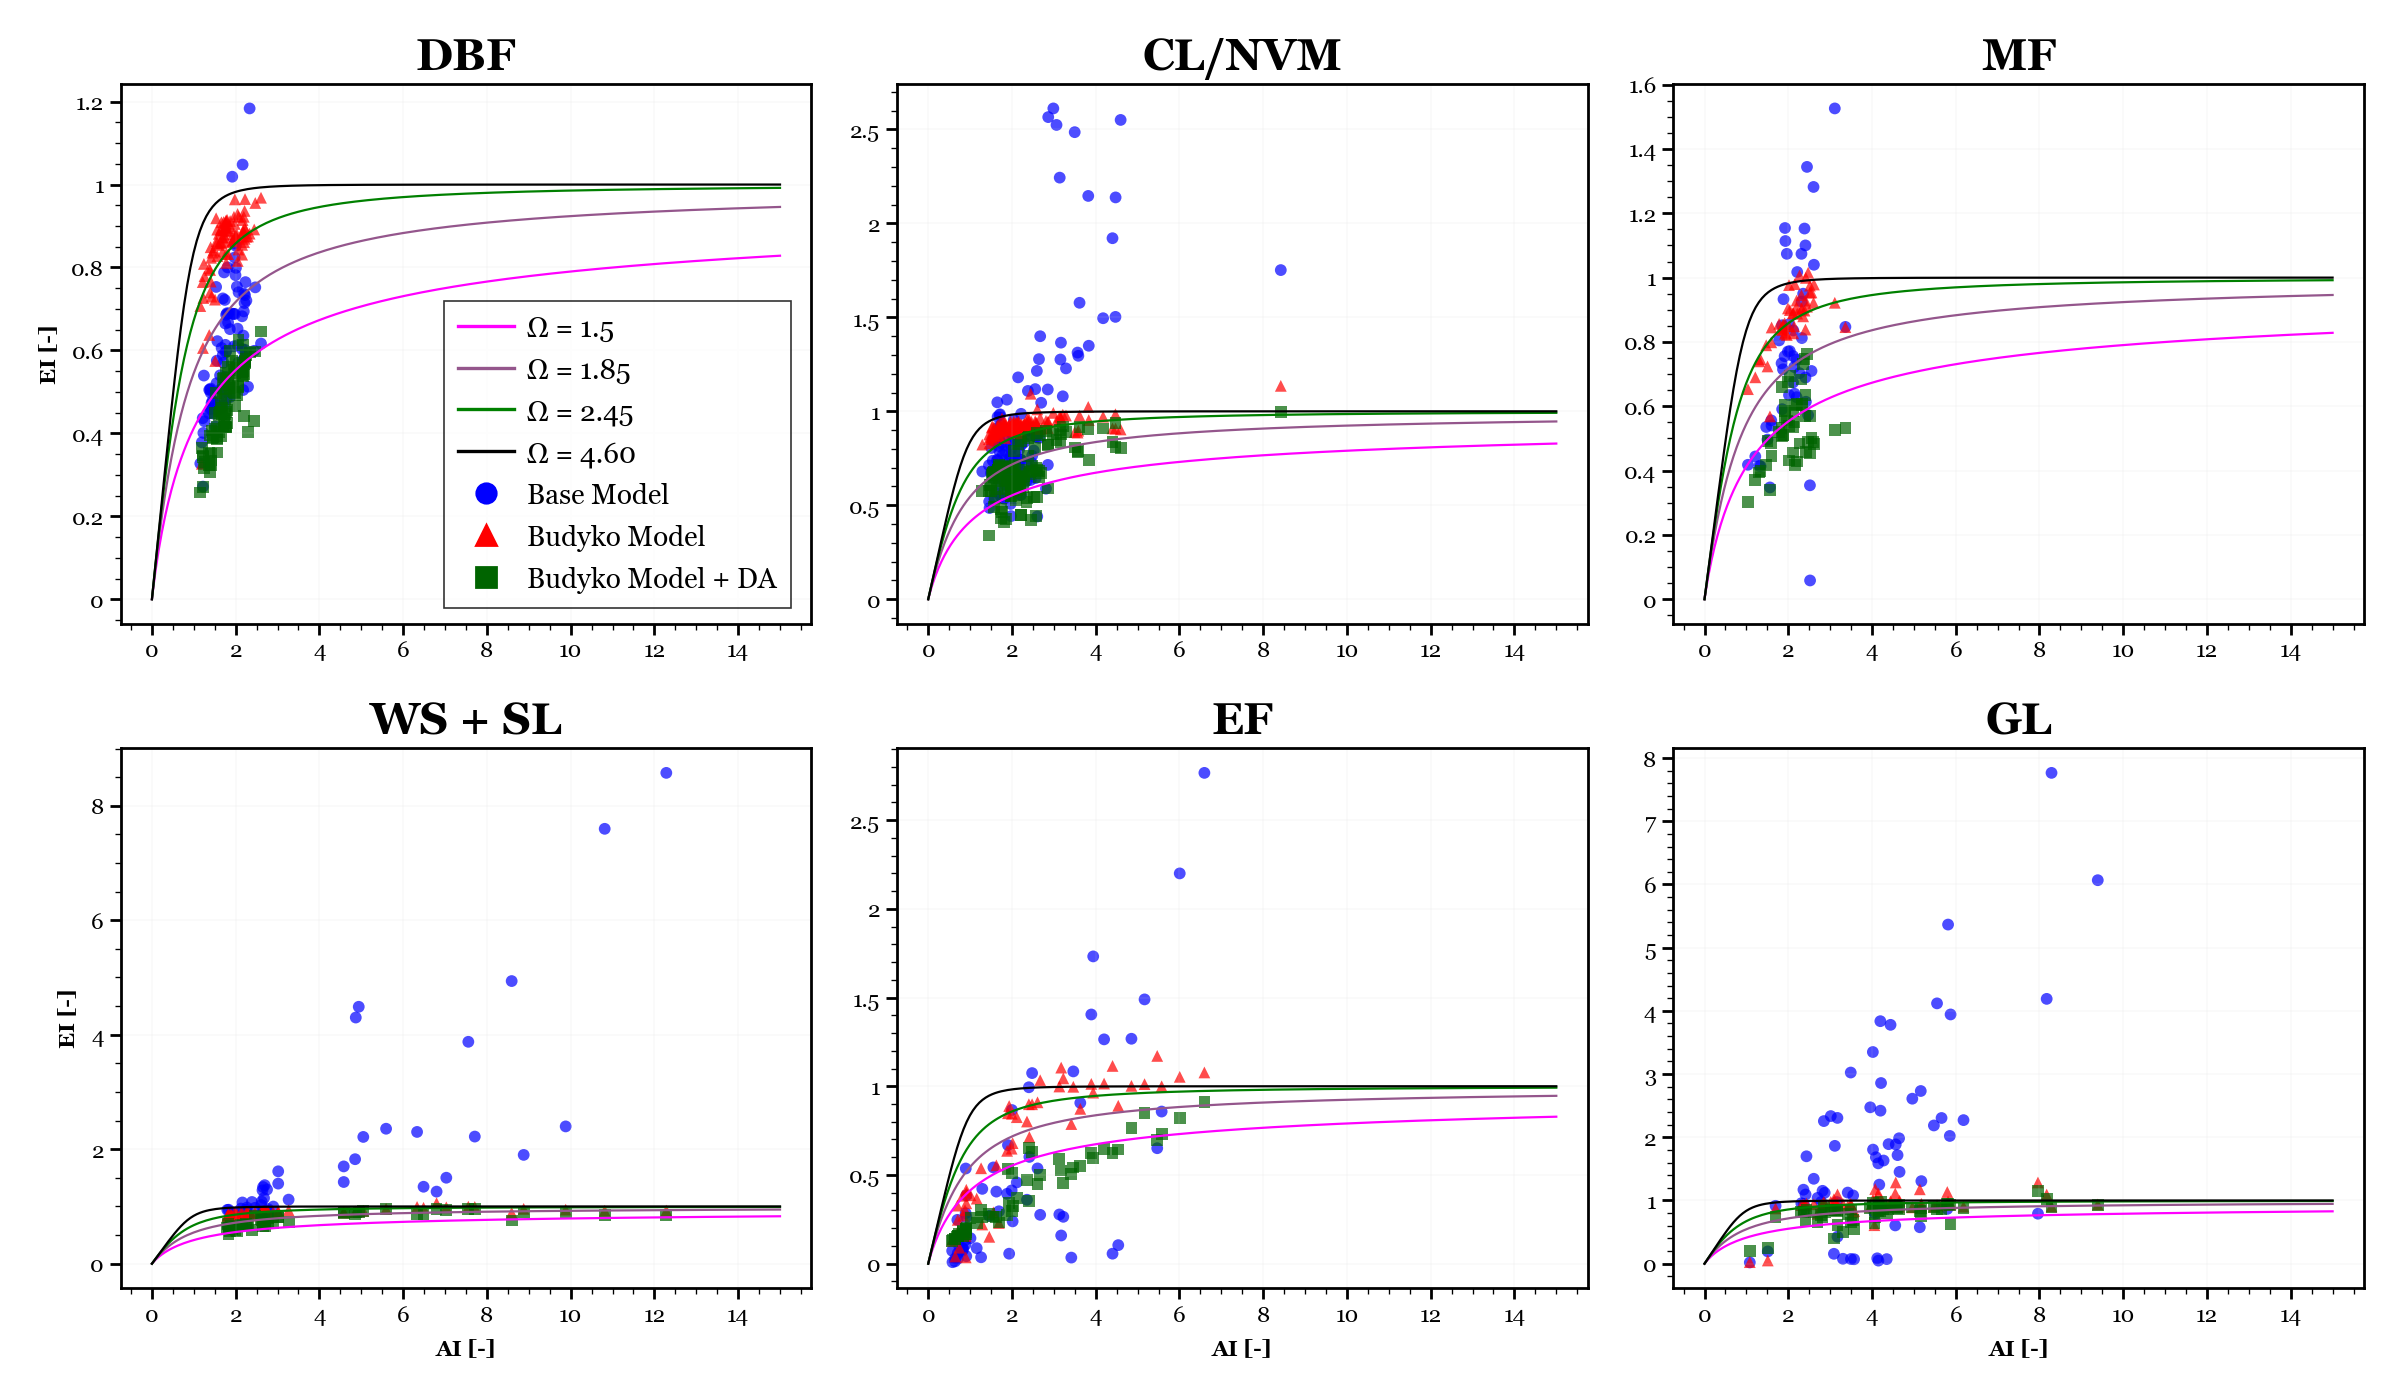

In [ ]:
# ============================================================
# PYTHON VERSION OF YOUR R SCRIPT (Notebook-ready)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Global style (similar to theme_bw(base_family="Georgia"))
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "Georgia",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "#d0d0d0",
    "grid.linewidth": 0.6,
    "xtick.color": "black",
    "ytick.color": "black",
})

# ============================================================
# LOAD DATA
# ============================================================
INPUT_CSV_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\attrs_SFET_geo_KGE.csv"

df = pd.read_csv(INPUT_CSV_PATH)
df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    # vector-safe implementation
    AI = np.asarray(AI, dtype=float)
    AIc = np.maximum(AI, 1e-6)
    return 1.0 + AIc - np.power(1.0 + np.power(AIc, omega), 1.0 / omega)

AI_range = np.concatenate([[0.0], np.linspace(0.01, 15, 199)])
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# LEGEND ITEMS
# ============================================================
# Omega curves
omega_values = [1.5, 1.85, 2.45, 4.60]
omega_items  = ["Ω = 1.5", "Ω = 1.85", "Ω = 2.45", "Ω = 4.60"]
omega_colors = ["magenta", "purple", "green", "black"]

# Models
model_items  = ["Base Model", "Budyko Model", "Budyko Model + DA"]
model_colors = ["blue", "red", "darkgreen"]
model_markers = ["o", "^", "s"]   # matplotlib markers roughly like pch 19,17,15

# Unified legend order
legend_items  = omega_items + model_items

legend_color_map = {k: v for k, v in zip(omega_items, omega_colors)}
legend_color_map.update({k: v for k, v in zip(model_items, model_colors)})

legend_marker_map = {k: None for k in omega_items}
legend_marker_map.update({k: v for k, v in zip(model_items, model_markers)})

# ============================================================
# BUILD OMEGA CURVES (long format equivalent)
# ============================================================
curves = []
for w, label, col in zip(omega_values, omega_items, omega_colors):
    ei = Fu(AI_range, w)
    curves.append(pd.DataFrame({"AI": AI_range, "EI": ei, "item": label, "color": col}))
budyko_curves = pd.concat(curves, ignore_index=True)

# ============================================================
# BUILD PANELS (2x3) + legend in first subplot
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))#, dpi=300)
axes = axes.ravel()

# model column mapping
model_map = {
    "Base Model": ("AI_ke", "EI_ke"),
    "Budyko Model": ("AI_B", "EI_B"),
    "Budyko Model + DA": ("AI_ass", "EI_ass"),
}

for i, lc in enumerate(dom_land_covers):
    ax = axes[i]

    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # -----------------------------
    # plot omega curves (lines)
    # -----------------------------
    for label, col in zip(omega_items, omega_colors):
        tmp = budyko_curves[budyko_curves["item"] == label]
        ax.plot(tmp["AI"].values, tmp["EI"].values, color=col, linewidth=0.8)

    # -----------------------------
    # build & plot model scatter
    # -----------------------------
    for mname, (ai_col, ei_col) in model_map.items():
        if ai_col in filtered.columns and ei_col in filtered.columns:
            x = pd.to_numeric(filtered[ai_col], errors="coerce")
            y = pd.to_numeric(filtered[ei_col], errors="coerce")
            ok = np.isfinite(x) & np.isfinite(y)
            x = x[ok].values
            y = y[ok].values

            ax.scatter(
                x, y,
                s=18, alpha=0.7,
                c=legend_color_map[mname],
                marker=legend_marker_map[mname],
                edgecolors="none"
            )

    # # -----------------------------
    # # axes, limits, titles, labels
    # # -----------------------------
    # ax.set_xlim(0, 8)
    # ax.set_ylim(0, 1)

    ax.set_title(lc, fontsize=16, fontweight="bold")

    # x label only for bottom row (panels 4-6 => indices 3-5)
    if i in [3, 4, 5]:
        ax.set_xlabel("AI [-]")
    else:
        ax.set_xlabel("")

    # y label only for first column (panels 1 and 4 => indices 0,3)
    if i in [0, 3]:
        ax.set_ylabel("EI [-]")
    else:
        ax.set_ylabel("")

    # theme_bw-like: light grid
    ax.grid(True)

# ============================================================
# PLACE LEGEND IN FIRST SUBPLOT (bottom-right inside axes)
# ============================================================
legend_handles = []

# omega lines (no marker)
for label, col in zip(omega_items, omega_colors):
    legend_handles.append(Line2D([0], [0], color=col, lw=1.2, label=label))

# model points (marker)
for label, col, mk in zip(model_items, model_colors, model_markers):
    legend_handles.append(Line2D([0], [0], color=col, marker=mk, lw=0, markersize=7, label=label))

axes[0].legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.97, 0.03),
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=10,
    ncol=1
)

# ============================================================
# FINAL LAYOUT
# ============================================================
plt.tight_layout()
plt.show()


# Distribution:

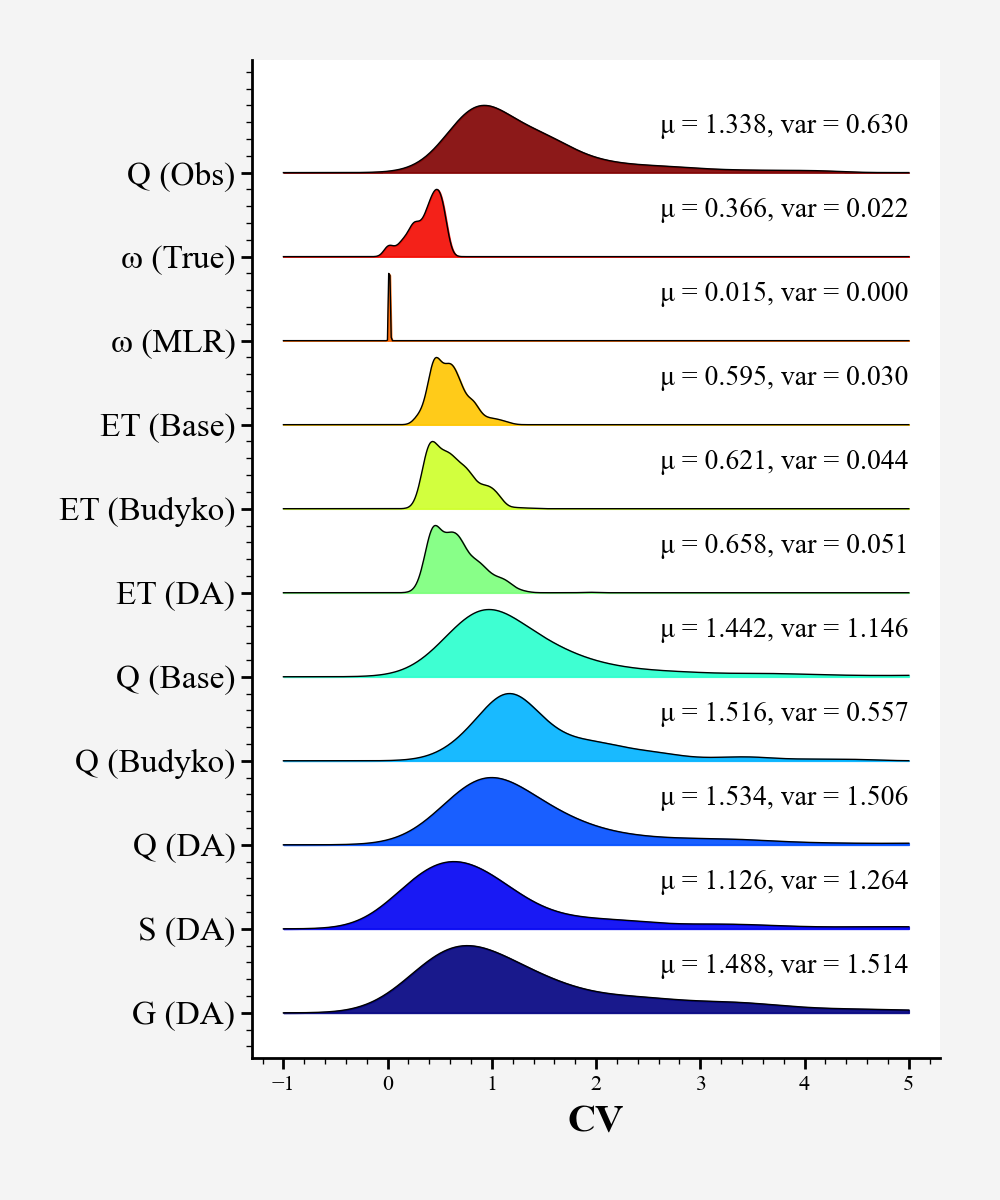

In [ ]:




import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties
from scipy.stats import gaussian_kde
import matplotlib.cm as cm


# ============================================================
# Font / style
# ============================================================
font_path_regular = r"C:/Windows/Fonts/times.ttf"
font_prop = FontProperties(fname=font_path_regular)

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20


# ============================================================
# Paths
# ============================================================
RESULT_DIR_BASE   = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BASE_MODEL"
RESULT_DIR_BUDYKO = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_MODEL"
RESULT_DIR_DA     = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\Simulation_with_CALIB_PARAMS\BUDYKO_DA"


# ============================================================
# Variables (keys stay unchanged)
# ============================================================
target_cols = [
    "Q_obs", "ET_ke", "Q_base",
    "ET_B", "omega_true", "omega_MLR", "Q_budyko",
    "S_ens", "G_ens", "ET_ens", "Q_ens"
]

variable_order = [
    "Q_obs", "omega_true", "omega_MLR",
    "ET_ke", "ET_B", "ET_ens",
    "Q_base", "Q_budyko", "Q_ens",
    "S_ens", "G_ens"
]


# ============================================================
# Scenario mapping (Base / Budyko / DA)
# ============================================================
def scenario_of(var):
    if var in ("Q_obs", "ET_ke", "Q_base"):
        return "Base"
    if var in ("omega_true", "omega_MLR", "ET_B", "Q_budyko"):
        return "Budyko"
    if var in ("S_ens", "G_ens", "ET_ens", "Q_ens"):
        return "DA"
    return np.nan



# ============================================================
# Display labels (ONLY for plotting)
# ============================================================
var_label = {
    "Q_obs":       "Q (Obs)",

    "ET_ke":       "ET (Base)",
    "Q_base":      "Q (Base)",

    "ET_B":        "ET (Budyko)",
    "Q_budyko":    "Q (Budyko)",

    "ET_ens":      "ET (DA)",
    "Q_ens":       "Q (DA)",

    "S_ens":       "S (DA)",
    "G_ens":       "G (DA)",

    "omega_true":  "ω (True)",
    "omega_MLR":   "ω (MLR)",
}


# ============================================================
# Scenario colors
# ============================================================
# cmap = cm.get_cmap("coolwarm")
cmap = cm.get_cmap("coolwarm")
scenario_colors = {
    "Base":   cmap(0.15),
    "Budyko": cmap(0.50),
    "DA":     cmap(0.85),
}


# ============================================================
# File listing
# ============================================================
def list_files(ddir, pattern):
    return sorted(glob.glob(os.path.join(ddir, pattern)))


base_files   = list_files(RESULT_DIR_BASE,   "results_BASE_*.feather")
budyko_files = list_files(RESULT_DIR_BUDYKO, "results_BUDYKO_*.feather")
da_files     = list_files(RESULT_DIR_DA,     "enkf_ensemble_BUDYKO_DA_*.feather")

if not (base_files or budyko_files or da_files):
    raise FileNotFoundError("No BASE / BUDYKO / DA feather files found.")


# ============================================================
# CV helper
# ============================================================
def cv_of_array(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    m = np.nanmean(x)
    s = np.nanstd(x, ddof=1)
    if not np.isfinite(m) or m == 0 or not np.isfinite(s):
        return np.nan
    return s / abs(m)


cv_list = {}


# ------------------------
# BASE
# ------------------------
for f in base_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for col in ("Q_obs", "ET_ke", "Q_base"):
        cvs[col] = cv_of_array(pd.to_numeric(df.get(col), errors="coerce"))
    cv_list[basin_id] = cvs


# ------------------------
# BUDYKO
# ------------------------
for f in budyko_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for col in ("omega_true", "omega_MLR", "ET_B", "Q_budyko"):
        cvs[col] = cv_of_array(pd.to_numeric(df.get(col), errors="coerce"))
    cv_list[basin_id] = cvs


# ------------------------
# DA
# ------------------------
for f in da_files:
    basin_id = os.path.basename(f).replace(".feather", "")
    try:
        df = pd.read_feather(f)
    except Exception:
        continue

    cvs = cv_list.get(basin_id, {})
    for out, src in [
        ("ET_ens", "ET_ens_mean"),
        ("Q_ens",  "Q_ens_mean"),
        ("S_ens",  "S_ens_mean"),
        ("G_ens",  "G_ens_mean"),
    ]:
        cvs[out] = cv_of_array(pd.to_numeric(df.get(src), errors="coerce"))
    cv_list[basin_id] = cvs


# ============================================================
# Build CV dataframe
# ============================================================
cv_df = pd.DataFrame.from_dict(cv_list, orient="index")
cv_df.index.name = "basin"

for c in target_cols:
    if c not in cv_df.columns:
        cv_df[c] = np.nan

cv_df = cv_df[target_cols]


# ============================================================
# Long format
# ============================================================
cv_long = (
    cv_df.reset_index()
    .melt(id_vars="basin", var_name="variable", value_name="cv")
)

cv_long["cv"] = pd.to_numeric(cv_long["cv"], errors="coerce")
cv_long["scenario"] = cv_long["variable"].map(scenario_of)

levels = list(reversed(variable_order))
cv_long["variable"] = pd.Categorical(cv_long["variable"], categories=levels, ordered=True)
cv_long = cv_long.sort_values("variable")


# ============================================================
# Stats
# ============================================================
cv_stats = (
    cv_long.groupby("variable", observed=True)["cv"]
    .agg(mean_cv="mean", var_cv=lambda x: np.nanvar(x, ddof=1))
    .reset_index()
)

cv_stats["label"] = cv_stats.apply(
    lambda r: "μ = NA, var = NA"
    if pd.isna(r["mean_cv"])
    else f"μ = {r['mean_cv']:.3f}, var = {r['var_cv']:.3f}",
    axis=1
)


# ============================================================
# Ridge plot
# ============================================================
x_min, x_max = -1, 5
x_grid = np.linspace(x_min, x_max, 500)

fig, ax = plt.subplots(figsize=(5, 6))
cmap = cm.get_cmap("jet", len(levels))
var_colors = {var: cmap(i) for i, var in enumerate(levels)}


for i, var in enumerate(levels):
    vals = cv_long.loc[cv_long["variable"] == var, "cv"].values
    vals = vals[np.isfinite(vals)]

    if vals.size < 5:
        dens = np.zeros_like(x_grid)
    else:
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        dens = dens / dens.max() * 0.8 if dens.max() > 0 else dens

    # ax.fill_between(x_grid, i, i + dens, color=scenario_colors[scenario_of(var)], alpha=0.9)

    ax.fill_between(x_grid, i, i + dens,color=var_colors[var],alpha=0.9)

    ax.plot(x_grid, i + dens, color="black", lw=0.5)

ax.set_yticks(range(len(levels)))
ax.set_yticklabels([var_label[v] for v in levels], fontproperties=font_prop, fontsize=12)


ax.set_xlabel("CV", fontsize=14)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for i, var in enumerate(levels):
    lab = cv_stats.loc[cv_stats["variable"] == var, "label"].values
    ax.text(5, i + 0.4, lab[0] if lab.size else "μ = NA, var = NA",
            ha="right", va="bottom", fontsize=10, fontproperties=font_prop)

plt.tight_layout()
# plt.savefig(
#     r"F:\Github_repos\Bayesian_DA_Budyko_modeling\Simulation_results\plots\ridgeplot_CV.png",
#     dpi=300, bbox_inches="tight"
# )
plt.show()


# Dynamic Budyko + Omega distribution:

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_34020\3574925183.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


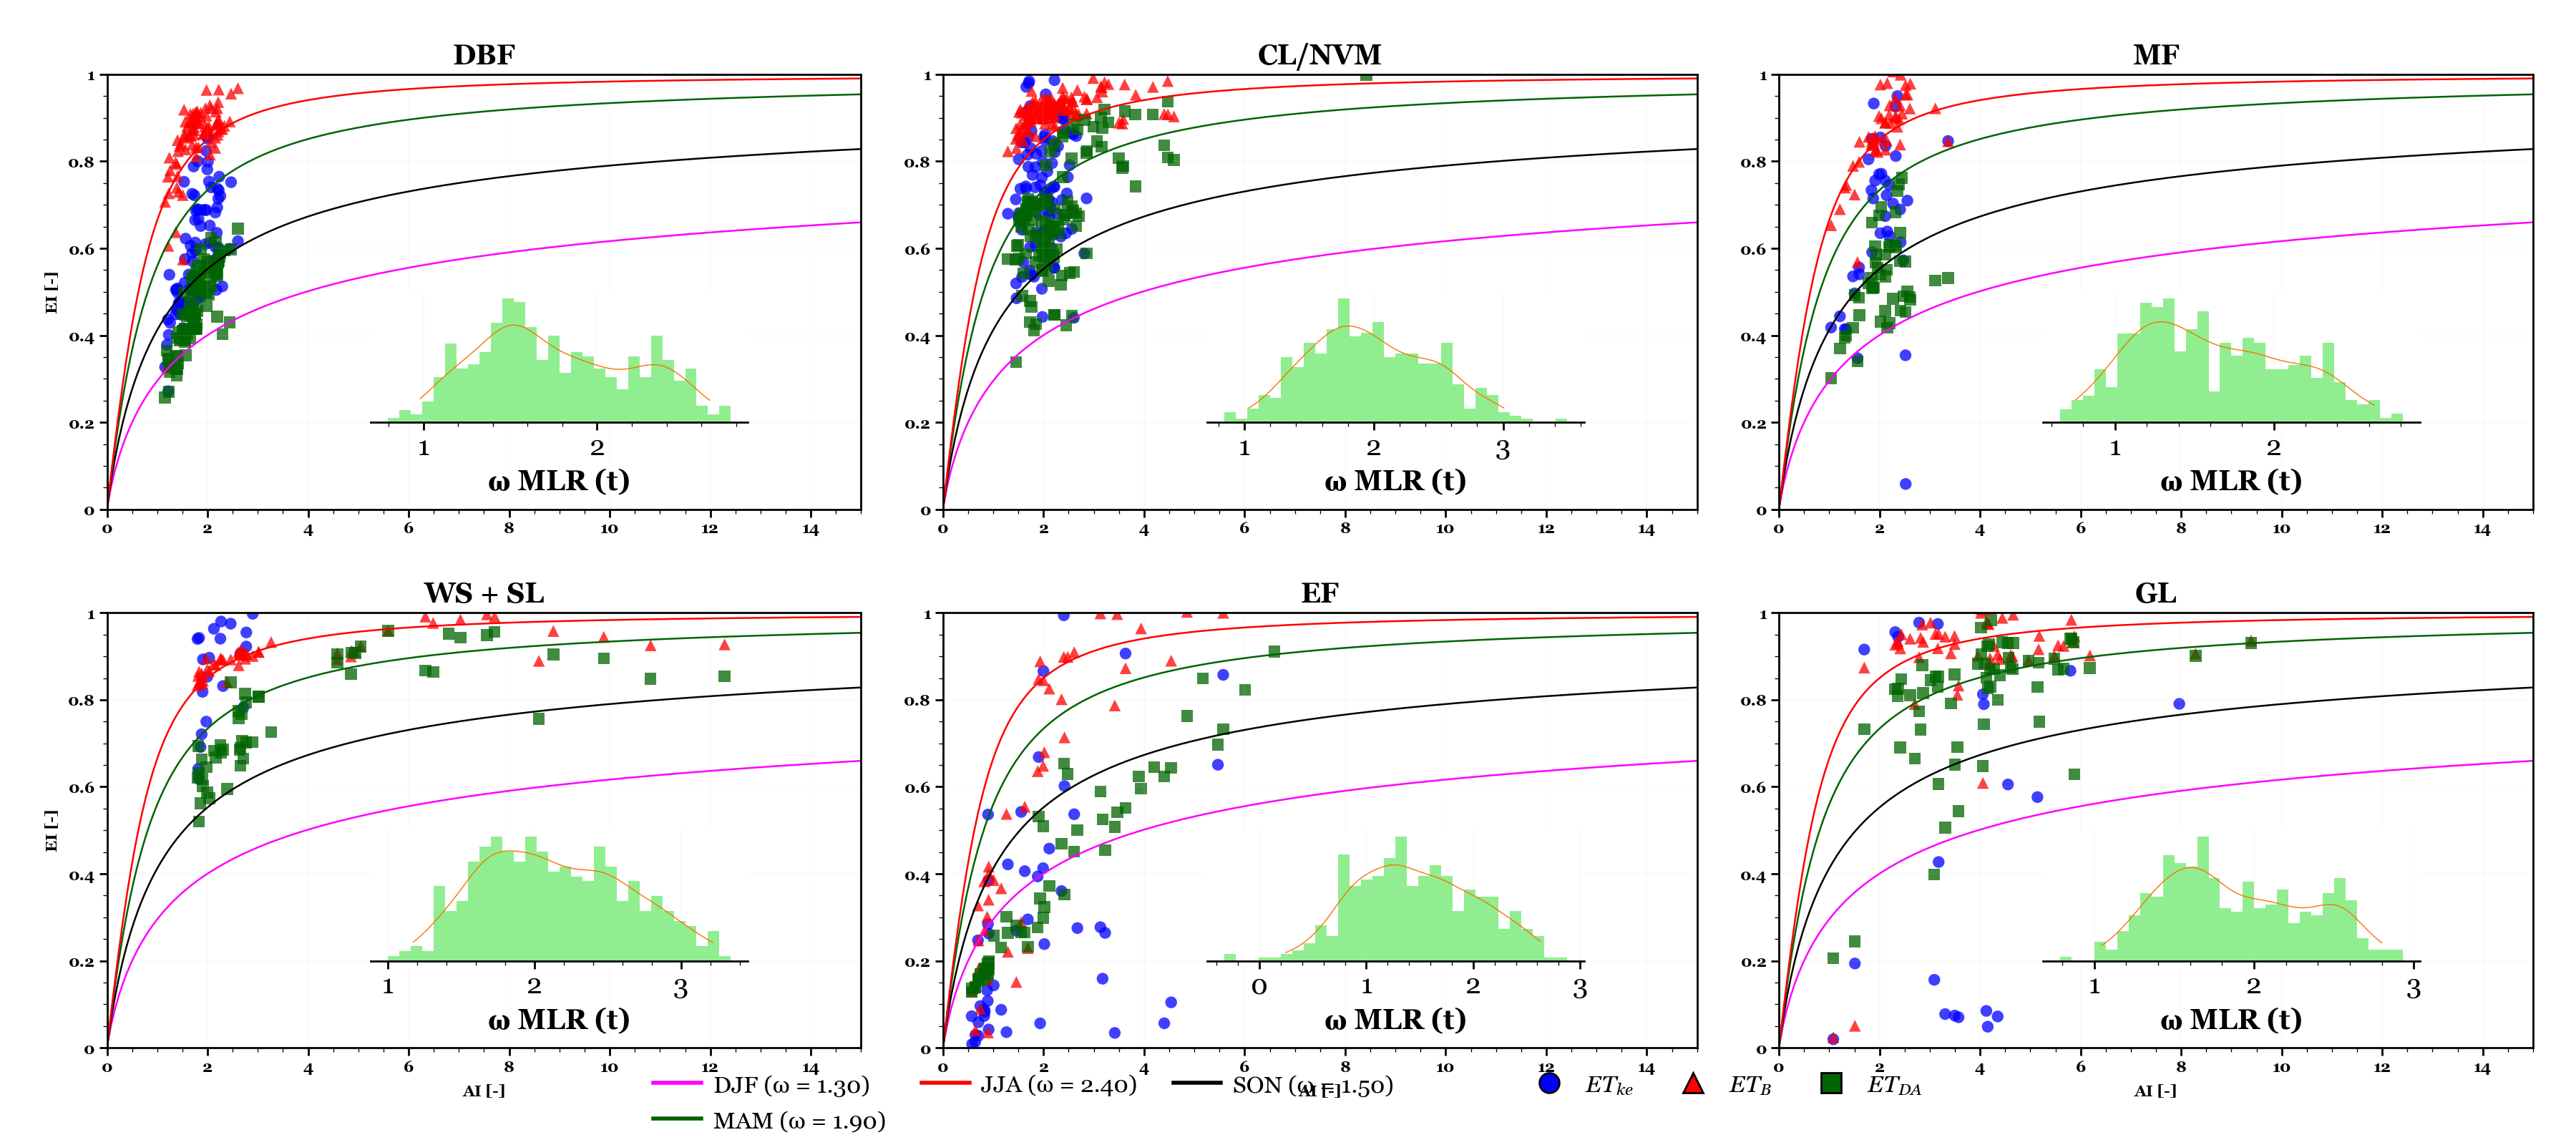

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# GLOBAL STYLE (theme_bw(base_family="Georgia"))
# ============================================================
plt.rcParams["font.family"] = "Georgia"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 8
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

# ============================================================
# LOAD DATA
# ============================================================
INPUT_CSV_PATH = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\attrs_SFET_geo_KGE.csv"
df = pd.read_csv(INPUT_CSV_PATH)

df["dom_land_cover_short"] = df["dom_land_cover_short"].astype(str)

# ============================================================
# BUDYKO FUNCTION (Fu)
# ============================================================
def Fu(AI, omega):
    AIc = np.maximum(AI, 1e-6)
    return 1 + AIc - (1 + AIc**omega) ** (1.0 / omega)

AI_range = np.concatenate(([0], np.linspace(0.01, 15, 199)))
dom_land_covers = ["DBF", "CL/NVM", "MF", "WS + SL", "EF", "GL"]

# ============================================================
# SEASONS & OMEGA VALUES
# ============================================================
seasons = ["DJF", "MAM", "JJA", "SON"]

omega_seasonal_mean = pd.DataFrame({
    "season": seasons,
    "omega": [1.3, 1.9, 2.4, 1.5]   # same as your R code
}).sort_values("omega")

season_order = omega_seasonal_mean["season"].tolist()

season_colors = {
    "DJF": "magenta",
    "MAM": "darkgreen",
    "JJA": "red",
    "SON": "black"
}

season_labels = {
    row["season"]: f"{row['season']} (ω = {row['omega']:.2f})"
    for _, row in omega_seasonal_mean.iterrows()
}

# ============================================================
# SCENARIOS (models)
# ============================================================
model_items = ["ET_ke", "ET_B", "ET_DA"]
model_colors = {
    "ET_ke": "blue",
    "ET_B": "red",
    "ET_DA": "darkgreen"
}
model_markers = {
    "ET_ke": "o",   # 19 filled circle
    "ET_B": "^",    # 17 triangle
    "ET_DA": "s"    # 15 square
}

# mapping AI/EI columns
model_map = {
    "ET_ke": ("AI_ke",  "EI_ke"),
    "ET_B":  ("AI_B",   "EI_B"),
    "ET_DA": ("AI_ass", "EI_ass")
}

# ============================================================
# BUILD PANELS
# ============================================================



fig, axes = plt.subplots(2, 3, figsize=(18, 8))#, dpi=300)
axes = axes.flatten()

np.random.seed(123)

for i, lc in enumerate(dom_land_covers):

    ax = axes[i]
    filtered = df[df["dom_land_cover_short"] == lc].copy()

    # ----------------------------------------------------------
    # SEASONAL BUDYKO CURVES
    # ----------------------------------------------------------
    for ss in season_order:
        om = float(omega_seasonal_mean.loc[omega_seasonal_mean["season"] == ss, "omega"].values[0])
        EI_curve = Fu(AI_range, om)
        ax.plot(AI_range, EI_curve, color=season_colors[ss], linewidth=0.9)

    # ----------------------------------------------------------
    # SCATTER DATA
    # ----------------------------------------------------------
    for nm in model_items:
        ai_col, ei_col = model_map[nm]
        if ai_col in filtered.columns and ei_col in filtered.columns:
            plot_data = filtered[[ai_col, ei_col]].rename(columns={ai_col: "AI", ei_col: "EI"})
            plot_data = plot_data[np.isfinite(plot_data["AI"]) & np.isfinite(plot_data["EI"])]

            ax.scatter(
                plot_data["AI"], plot_data["EI"],
                s=35,
                alpha=0.75,
                color=model_colors[nm],
                marker=model_markers[nm],
                edgecolor="none"
            )

    # ----------------------------------------------------------
    # VEGETATION-SPECIFIC OMEGA DISTRIBUTION INSET
    # ----------------------------------------------------------
    veg_mean_shift = [0.00, 0.20, -0.15, 0.35, -0.30, 0.10][i]
    veg_sd         = [0.18, 0.25, 0.22, 0.30, 0.35, 0.20][i]

    omega_samples = []
    for mu in omega_seasonal_mean["omega"].values:
        omega_samples.append(np.random.normal(loc=mu + veg_mean_shift, scale=veg_sd, size=100))
    omega_dist = np.concatenate(omega_samples)

    q01, q99 = np.quantile(omega_dist, [0.01, 0.99])

    # inset axes
    iax = inset_axes(
        ax,
        width="50%", height="30%",
        loc="lower left",
        bbox_to_anchor=(0.35, 0.2, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    # histogram density
    bins = 30
    iax.hist(
        omega_dist,
        bins=bins,
        density=True,
        color="lightgreen",
        edgecolor="black",
        linewidth=0
    )

    # density line
    kde = gaussian_kde(omega_dist)
    x_kde = np.linspace(q01, q99, 100)
    y_kde = kde(x_kde)
    iax.plot(x_kde, y_kde, color="orange", linewidth=0.5)

    # iax.set_xlim(q01, q99)
    iax.set_yticks([])

    iax.set_xlabel("ω MLR (t)", fontsize=14)
    iax.tick_params(axis="x", labelsize=14)
    for spine in ["top", "right", "left"]:
        iax.spines[spine].set_visible(False)

    # ----------------------------------------------------------
    # PANEL FORMATTING
    # ----------------------------------------------------------
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 1)

    # Title bold (like element_markdown **lc**)
    ax.set_title(lc, fontsize=14, fontweight="bold")

    # axis labels only for selected panels (same logic as R)
    ax.set_xlabel("AI [-]" if (i+1) in [4, 5, 6] else "")
    ax.set_ylabel("EI [-]" if (i+1) in [1, 4] else "")

    # ticks bold
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

# ============================================================
# BUILD ONE SHARED LEGEND (bottom)
# ============================================================
legend_handles = []

# seasons (lines)
for ss in seasons:
    legend_handles.append(
        Line2D([0], [0], color=season_colors[ss], lw=2,
               label=season_labels[ss])
    )

# models (points)
legend_handles.append(Line2D([], [], color="none", label=""))  # spacer

legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_ke"], color="none",
           markerfacecolor=model_colors["ET_ke"], markersize=10, label=r"$ET_{ke}$")
)
legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_B"], color="none",
           markerfacecolor=model_colors["ET_B"], markersize=10, label=r"$ET_{B}$")
)
legend_handles.append(
    Line2D([0], [0], marker=model_markers["ET_DA"], color="none",
           markerfacecolor=model_colors["ET_DA"], markersize=10, label=r"$ET_{DA}$")
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=7,
    frameon=False,
    fontsize=12,
    handlelength=2
)
plt.tight_layout()
# plt.subplots_adjust(bottom=0.18, wspace=0.25, hspace=0.35)
plt.show()


In [ ]:
# NWM
Result_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"
NWM = pd.read_feather(os.path.join(Result_DIR, "NWM.feather"))

# NLDAS raw
Result_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"
Q_nldas_mm_monthly = pd.read_feather(os.path.join(Result_DIR, "Q_nldas_mm_monthly.feather"))
Q_nldas_mm_monthly = Q_nldas_mm_monthly.set_index('time')


r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attributes_v2.0.feather")
attrs = gpd.read_feather(io.BytesIO(r.content))
r = requests.get("https://www.hydroshare.org/resource/658c359b8c83494aac0f58145b1b04e6/data/contents/camels_attrs_v2_streamflow_v1p2.nc")
attrs = attrs.reset_index(drop=False)


area_km2 = attrs['area_gages2']
area_km2
# Load data and clean column names
SFET = pd.read_csv(r'F:\Data\SFET\SFET_ET.csv')
SFET.columns = SFET.columns.str.replace(r"^USA_", "", regex=True)
SFET.columns = SFET.columns.str.replace(r"\.\d+$", "", regex=True)
SFET.columns = SFET.columns.str.strip()

# Convert 'date' column to datetime and set as index
SFET['time'] = pd.to_datetime(SFET['time'])
SFET['time'] = SFET['time'].dt.strftime('%Y-%m-%d')
SFET = SFET[
    (SFET['time'] >= '2000-03-31') & 
    (SFET['time'] <= '2014-12-31')
]

SFET.set_index('time', inplace=True)

SFET_monthly_2000_2014 = SFET.copy()
SFET_monthly_2000_2014.index = pd.to_datetime(SFET_monthly_2000_2014.index)
SFET_monthly_2000_2014 = SFET_monthly_2000_2014.resample('MS').mean()
SFET_monthly_2000_2014.index = pd.Index(SFET_monthly_2000_2014.index.strftime('%Y-%m-%d'))



col_nldas_sfet = SFET_monthly_2000_2014.columns.intersection(Q_nldas_mm_monthly.columns)
SFET_monthly_2000_2014 = SFET_monthly_2000_2014[col_nldas_sfet]
SFET_monthly_2000_2014


SFET_longterm = SFET_monthly_2000_2014.mean(axis=0).to_frame(name="SFET")
SFET_longterm.reset_index(inplace=True)
SFET_longterm.rename(columns={"index": "gauge_id"}, inplace=True)
SFET_longterm = SFET_longterm.set_index('gauge_id')

# merge
all_simu_mean_505_basins_SFET = all_simu_mean_505_basins.join(SFET_longterm, how='inner')

# all_simu_mean_505_basins_SFET_attrs = all_simu_mean_505_basins_SFET.join(attrs, how='inner')
# all_simu_mean_505_basins_SFET_attrs['Res'] = all_simu_mean_505_basins_SFET_attrs['omega_true'] - all_simu_mean_505_basins_SFET_attrs['omega_MLR']
# all_simu_mean_505_basins_SFET_attrs['EAI_ke'] = all_simu_mean_505_basins_SFET_attrs['PET'] / (all_simu_mean_505_basins_SFET_attrs['ET_ke'] + all_simu_mean_505_basins_SFET_attrs['ET_ke'])



In [ ]:
SFET_monthly_2000_2014

,01013500,01022500,01030500,01031500,01047000,01052500,01054200,01055000,01057000,01073000,...,14301000,14303200,14305500,14306340,14306500,14309500,14316700,14325000,14362250,14400000
time,,,,,,,,,,,,,,,,,,,,,
2000-03-01,0.563525,0.897485,0.692936,0.668471,0.628754,0.473688,0.656156,0.730647,0.781809,1.320996,...,1.858164,2.015754,2.005878,2.173655,2.170275,1.984994,2.070839,2.012765,2.237309,1.952930
2000-04-01,0.605063,0.836660,0.729489,0.712227,0.758282,0.717630,0.800980,0.792205,0.867138,1.072175,...,1.523295,1.604649,1.642958,1.757398,1.742841,1.863227,1.870202,1.742301,1.732517,1.811293
2000-05-01,1.460499,1.720961,1.584668,1.505537,1.477000,1.440918,1.510751,1.521801,1.628574,1.878832,...,1.856514,1.955264,1.966798,2.180920,2.164021,2.398794,2.416485,2.151727,2.452823,2.337572
2000-06-01,2.049409,2.279426,2.143032,2.112477,2.003632,1.900976,1.950736,1.950854,2.115244,2.311801,...,2.477507,2.669880,2.693059,2.865601,2.852074,3.118782,3.093508,3.094113,3.322197,3.030735
2000-07-01,2.409327,2.717808,2.459161,2.436880,2.385258,2.406782,2.456671,2.370122,2.493461,2.751334,...,2.693954,2.784238,2.779253,2.995194,2.963382,3.416054,3.365458,3.321615,3.297981,3.323039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-01,2.808078,3.084496,2.865929,2.790405,2.595511,2.493096,2.564721,2.634484,2.746117,3.043696,...,2.912016,2.754277,2.548554,2.792375,2.655160,2.264804,2.024477,2.929158,3.085342,2.019801
2014-09-01,1.527950,1.947512,1.748781,1.712609,1.688059,1.607650,1.671286,1.727489,1.786506,2.063909,...,1.713824,1.647029,1.531959,1.770859,1.731030,1.467970,1.375574,1.853866,1.959924,1.353662
2014-10-01,0.635665,0.744822,0.734900,0.630151,0.638630,0.590160,0.610231,0.649788,0.672633,0.762179,...,0.759161,0.762485,0.761131,0.918614,0.836177,1.031890,0.977896,0.900377,1.003940,0.950139


In [ ]:
# -----------------------------------------
# Create NSE and KGE wide-format DataFrames
# -----------------------------------------
NSE_df = (
    perform_extended
    .pivot(index="gauge_id", columns="scenario", values="NSE")
).dropna()

KGE_df = (
    perform_extended
    .pivot(index="gauge_id", columns="scenario", values="KGE")
).dropna()

# -----------------------------------------
# Fix gauge_id formatting
# -----------------------------------------
KGE_df.index = KGE_df.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
NSE_df.index = NSE_df.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)
attrs_SFET_geo.index = attrs_SFET_geo.index.astype(str).map(lambda x: '0' + x if not x.startswith('0') else x)


# -----------------------------------------
scenario_cols = NSE_df.columns.tolist()
attrs_SFET_geo = attrs_SFET_geo.drop(
    columns=[c for c in scenario_cols if c in attrs_SFET_geo.columns],
    errors="ignore"
)

# -----------------------------------------
# Merge without creating _x suffixes
# -----------------------------------------
attrs_SFET_geo_NSE = NSE_df.merge(
    attrs_SFET_geo,
    left_index=True,
    right_index=True,
    how="inner"
)

attrs_SFET_geo_NSE


# -----------------------------------------
# Merge without creating _x suffixes
# -----------------------------------------
attrs_SFET_geo_KGE = KGE_df.merge(
    attrs_SFET_geo,
    left_index=True,
    right_index=True,
    how="inner"
)

attrs_SFET_geo_KGE


# --------------------- Plotting ----------------------------------
import matplotlib as mpl



# --------------------- Plotting ----------------------------------
try:
    if not isinstance(attrs_SFET_geo_KGE, gpd.GeoDataFrame):
        attrs_SFET_geo_KGE = gpd.GeoDataFrame(
            attrs_SFET_geo_KGE, 
            geometry='geometry'
        )
except Exception as e:
    print(f"Warning: {e}")

possible_kge_cols = ["Q_ke", "Q_b", "Q_B_ass", "Q_nldas", "Q_NWM"]
kge_cols = [c for c in attrs_SFET_geo_KGE.columns if c in possible_kge_cols]
kge_cols = kge_cols[:4]

fig, axs = pplt.subplots(
    ncols=2,
    nrows=2,
    refwidth='4in',
    refheight='2in',
    dpi=200
)

# ---- Common colormap ----
vmin, vmax = -3.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.get_cmap('gist_ncar')

# ---- Create ONE mappable for the colorbar ----
mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# ---- Reproject once ----
projected = attrs_SFET_geo_KGE.to_crs(5070)
states_proj = states.to_crs(5070)

for ax, col in zip(axs, kge_cols):

    states_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=0.3)

    values = projected[col].values
    colors = cmap(norm(values))

    projected.plot(
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0.12
    )

    ax.set_title(col, fontsize=14)
    ax.set_axis_off()

# ---- ONE colorbar ----
ticks = np.linspace(vmin, vmax, 9)

cbar = fig.colorbar(
    mappable,
    ax=axs,
    loc='r',
    ticks=ticks,
    label="KGE [-]",
    width=0.15,
    pad=0.1,
    extend='max'
)

# cbar.set_label("KGE [-]")

pplt.show()


# Spatial Mean KGE (overall all models:)

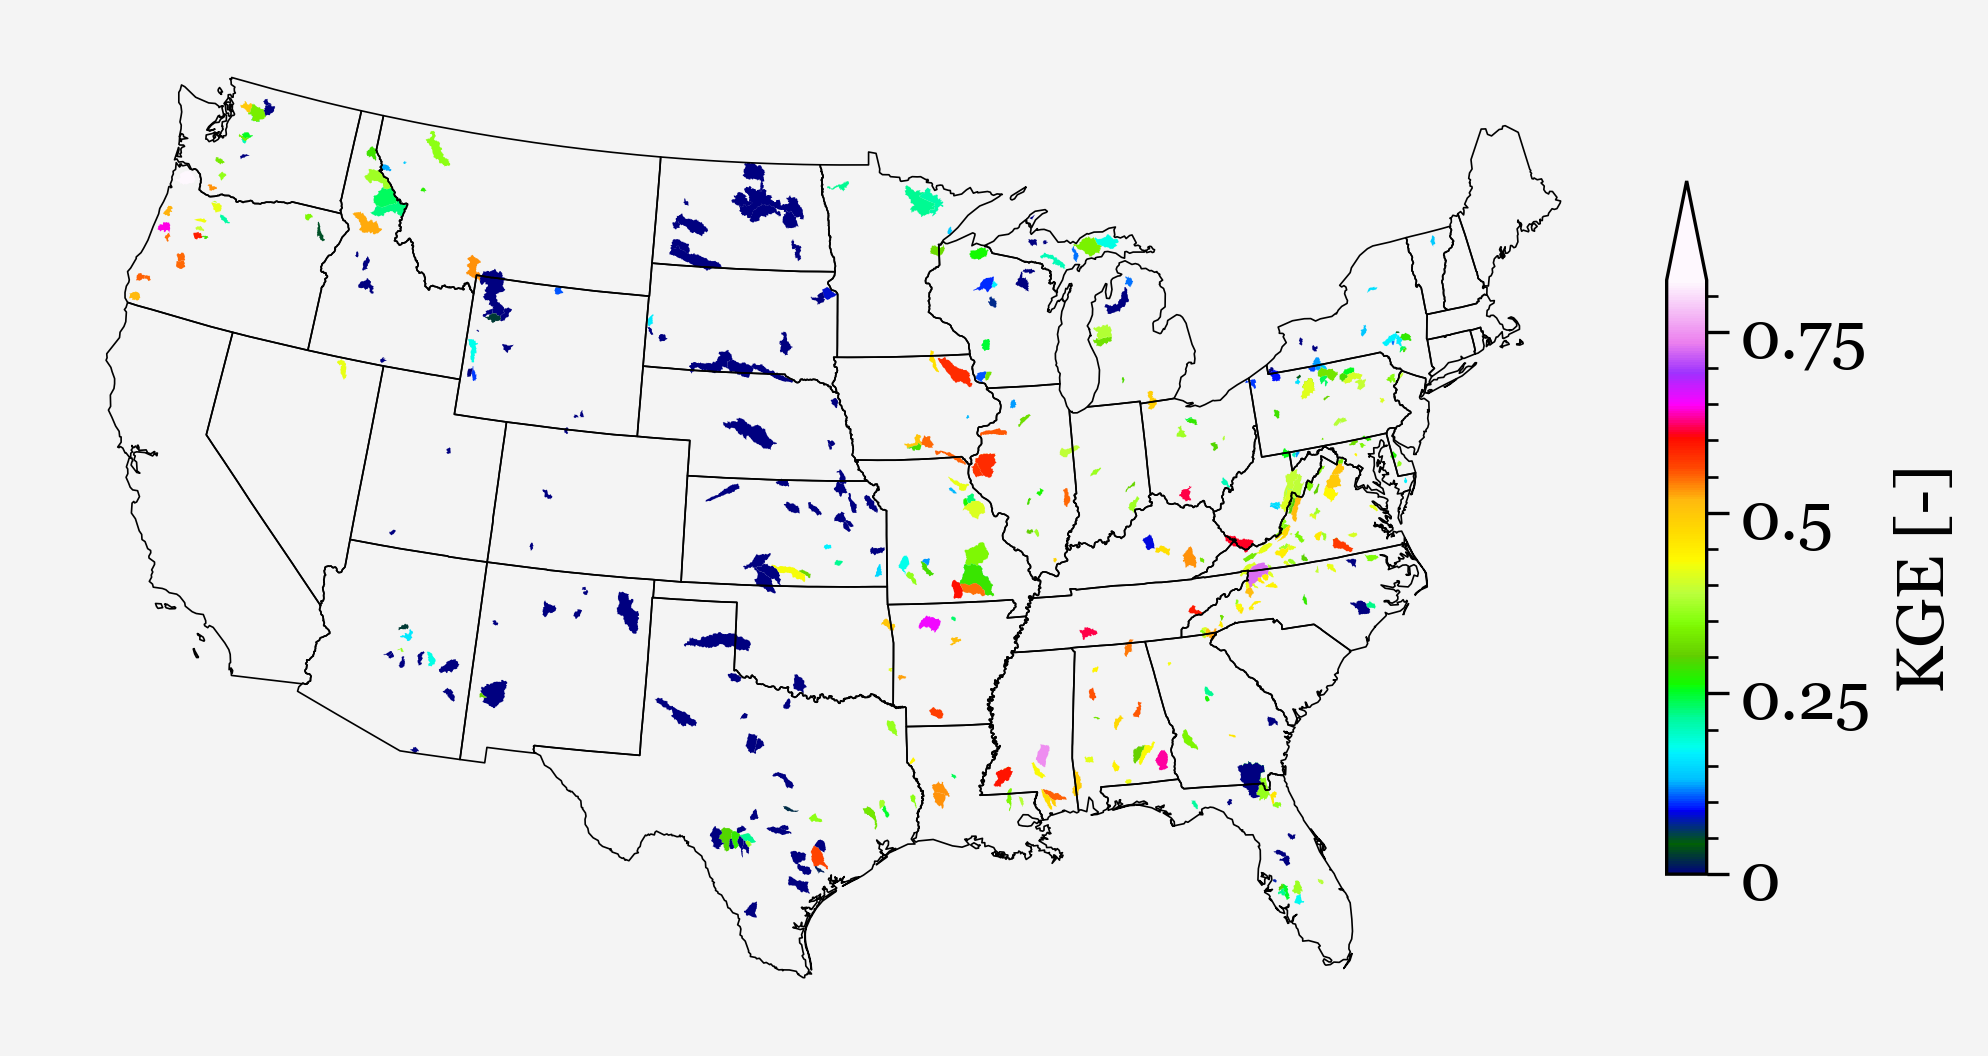

In [ ]:
# Compute summary KGE statistics
attrs_SFET_geo_KGE["KGE_mean"] = attrs_SFET_geo_KGE[kge_cols].mean(axis=1)

# SINGLE SPATIAL MAP OF MEAN KGE
fig, ax = pplt.subplots(refwidth='4in', dpi=200)

projected = attrs_SFET_geo_KGE.to_crs(5070)
states_proj = states.to_crs(5070)

states_proj.boundary.plot(ax=ax, edgecolor='black', lw=0.3)

values = projected["KGE_mean"]
norm = mpl.colors.Normalize(vmin=0, vmax=values.max())
cmap = mpl.cm.get_cmap('gist_ncar')
colors = cmap(norm(values))

projected.plot(ax=ax, color=colors, edgecolor='none', linewidth=0.1)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, 
                                   cmap=cmap),
                                   ax=ax, 
                                   loc='r', 
                                   label="KGE [-]",
                                   width=0.1,
                                   length=0.7,
                                   extend='max')

# ax.set_title("Mean KGE Across All Models")
ax.set_axis_off()
pplt.show()
